In [30]:
import requests
import io
import tarfile
import os
import sys
import time
import requests
import re

import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from bs4 import BeautifulSoup
import matspy

from scipy.sparse.linalg import svds
from scipy.io import mmread
import scipy.sparse as sparse
# import scipy.sparse.linalg.norm
from scipy.linalg import orthogonal_procrustes, subspace_angles, matrix_balance
from scipy.sparse._csr import csr_matrix
from scipy.optimize import linear_sum_assignment

from scipy import stats

def abbreviate_phrase(phrase):
    # Remove parentheses and split the phrase into words
    words = phrase.replace('(', '').replace(')', '').split()
    
    # Take the first letter of each word, capitalize it, and join
    abbreviation = ''.join(word[0].upper() for word in words)
    
    return abbreviation

def analyze_correlation(approx_residuals, some_measure, 
                        dir_path, iteration,
                        n=40, name="Current Measure"):
    # Ensure we're only looking at the first n elements
    approx_residuals = approx_residuals[:n]
    some_measure = some_measure[:n]
    
    # Calculate Pearson correlation coefficient
    correlation, p_value = stats.pearsonr(some_measure, np.log10(approx_residuals))
    
    # Create scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(some_measure, approx_residuals)
    plt.xlabel(name)
    plt.ylabel('Approximate Residual')
    plt.yscale('log')  # Use log scale for residuals due to their wide range
    
    # Add correlation line
    # z = np.polyfit(some_measure, np.log10(approx_residuals), 1)
    # p = np.poly1d(z)
    # plt.plot(some_measure, 10**p(some_measure), "r--", alpha=0.8)

    title = f'{name} vs Approximate Residual (First {n} Eigenvectors)\n'

    # title += f"Pearson correlation coefficient: {correlation:.4f}\n"
    
    if p_value < 0.05:
        title += f"p value = {p_value:.3f} < 0.05"
    else:
        title += f"p value = {p_value:.3f} >= 0.05"
    plt.title(title)
    plt.tight_layout()
    plt.savefig(dir_path + f'/{abbreviate_phrase(name)}_vs_residual_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')

def download_and_read_matrix(url):
    # Download the file
    response = requests.get(url)
    response.raise_for_status()  # Raise an exception for bad responses

    # Create a file-like object from the response content
    file_like_object = io.BytesIO(response.content)

    # Open the tar.gz file
    with tarfile.open(fileobj=file_like_object, mode="r:gz") as tar:
        # Find the .mtx file in the archive
        mtx_file = [f for f in tar.getnames() if f.endswith('.mtx')][0]
        
        # Extract and read the .mtx file
        f = tar.extractfile(mtx_file)
        matrix = mmread(f)

    return sparse.csr_matrix(matrix)

# Optional: Soft thresholding function
def soft_thresholding(S, threshold=0):
    return np.maximum(S - threshold, 0)

def soft_thresholding_Ghashami(S):
    # Assuming S is descending order
    return np.sqrt(S**2 - S[-1]**2) 

def match_eigenpairs_by_norm(estimated_eigenvalues, estimated_eigenvectors, 
                                    exact_eigenvalues, exact_eigenvectors):
    n = estimated_eigenvectors.shape[1]
    
    # Normalize eigenvectors
    estimated_eigenvectors = estimated_eigenvectors / np.linalg.norm(estimated_eigenvectors, axis=0)
    exact_eigenvectors = exact_eigenvectors / np.linalg.norm(exact_eigenvectors, axis=0)
    
    # Compute the pairwise differences between estimated and exact eigenvectors
    differences = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            # Compute norm of the difference in eigenvectors
            differences[i, j] = np.linalg.norm(estimated_eigenvectors[:, i] - exact_eigenvectors[:, j])
    
    # Use the Hungarian algorithm to find the best matches
    row_ind, col_ind = linear_sum_assignment(differences)
    
    # Create the matches
    matches = {}
    for i, j in zip(row_ind, col_ind):
        angle = np.arccos(np.abs(np.dot(estimated_eigenvectors[:, i], exact_eigenvectors[:, j])))
        relative_diff = np.abs(estimated_eigenvalues[i] - exact_eigenvalues[j]) / np.abs(exact_eigenvalues[j])
        matches[i] = (j, estimated_eigenvalues[i], exact_eigenvalues[j], differences[i, j], angle, relative_diff)
    
    return matches

def match_eigenpairs_by_angle(estimated_eigenvalues, estimated_eigenvectors, 
                     exact_eigenvalues, exact_eigenvectors, 
                     angle_threshold=np.pi/4):
    n = len(estimated_eigenvalues)
    
    # Normalize eigenvectors
    estimated_eigenvectors = estimated_eigenvectors / np.linalg.norm(estimated_eigenvectors, axis=0)
    exact_eigenvectors = exact_eigenvectors / np.linalg.norm(exact_eigenvectors, axis=0)
    
    # Compute cosine similarities
    similarities = np.abs(np.dot(estimated_eigenvectors.T, exact_eigenvectors))
    
    # Use the Hungarian algorithm to find the best matches
    row_ind, col_ind = linear_sum_assignment(-similarities)
    # print(similarities.shape, estimated_eigenvectors.shape, )
    
    # Create the matches and check against the threshold
    matches = {}
    for i, j in zip(row_ind, col_ind):
        eps = 1e-6
        assert np.all(similarities[i, j] > -1.0 - eps) and np.all(similarities[i, j] < 1.0 + eps), "Invalid canonical correlation found" 
        angle = np.arccos(np.clip(similarities[i, j], -1.0, 1.0))
        norm_diff = np.linalg.norm(estimated_eigenvectors[:, i] - exact_eigenvectors[:, j])
        # if angle <= angle_threshold:
        relative_diff = np.abs(estimated_eigenvalues[i] - exact_eigenvalues[j]) / np.abs(exact_eigenvalues[j])
        matches[i] = (j, estimated_eigenvalues[i], exact_eigenvalues[j], norm_diff, angle, relative_diff)
    
    return matches

def match_eigenpairs_by_eigenvalues(estimated_eigenvalues, estimated_eigenvectors, 
                                    exact_eigenvalues, exact_eigenvectors, 
                                    relative_threshold=0.1):
    n = len(estimated_eigenvalues)
    
    # Compute the pairwise differences between estimated and exact eigenvalues
    differences = np.abs(estimated_eigenvalues[:, np.newaxis] - exact_eigenvalues)
    
    # Use the Hungarian algorithm to find the best matches
    row_ind, col_ind = linear_sum_assignment(differences)
    
    # Create the matches and check against the threshold
    matches = {}
    for i, j in zip(row_ind, col_ind):
        relative_diff = differences[i, j] / np.abs(exact_eigenvalues[j])
        # if relative_diff <= relative_threshold:
        # Compute the angle between eigenvectors for information
        cos_angle = np.abs(np.dot(estimated_eigenvectors[:, i], exact_eigenvectors[:, j]))
        eps = 1e-6
        assert np.all(cos_angle > -1.0 - eps) and np.all(cos_angle < 1.0 + eps), "Invalid canonical correlation found" 
        angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))
        norm_diff = np.linalg.norm(estimated_eigenvectors[:, i] - exact_eigenvectors[:, j])
        matches[i] = (j, estimated_eigenvalues[i], exact_eigenvalues[j], norm_diff, angle, relative_diff)
    
    return matches

def plot_spectrum_comparison(S, S_exact, 
                             A_norm, name, iteration, dir_path):
    plt.figure(figsize=(10, 6))
    plt.plot(S, label='Approximated Spectrum')
    plt.plot(S_exact, label='Exact Spectrum')
    plt.xlabel('Index')
    plt.ylabel('Singular Value')
    plt.title(f'Comparison of Approximated and Exact Spectra iteration {iteration}')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.savefig(dir_path + f'/spectrum_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')


    plt.figure(figsize=(10, 6))
    plt.plot(np.abs(S - S_exact[:len(S)]) / A_norm, label='$\\left\\|\\frac{S-S_\\text{exact}}{\|A\|_F}\\right\\|$')
    plt.xlabel('Index')
    plt.ylabel('Singular Value')
    plt.title(f'Difference between Approximated and Exact Spectra iteration {iteration}')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.savefig(dir_path + f'/diffspec_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')

def plot_residuals(A_csr, S, Vt, S_exact, Vt_exact, U_exact, 
                   A_norm, name, iteration, dir_path, is_sym_psd):
    approx_residuals = []
    # exact_residuals = []

    if is_sym_psd:
        for i in range(len(S)):
            # Approximated residual
            # approx_res = A.T @ (A @ Vt[i].T) - S[i]**2 * Vt[i].T
            approx_res = (A_csr @ Vt[i].T) - (S[i]) * Vt[i].T
            approx_residuals.append(np.linalg.norm(approx_res) / A_norm)
            
            # Exact residual
            # exact_res = A.T @ (A @ Vt_exact[i].T) - S_exact[i]**2 * Vt_exact[i].T
            # exact_residuals.append(np.linalg.norm(exact_res) / np.linalg.norm(S_exact[i]**2 * Vt_exact[i].T))
        
        approx_residuals = np.array(approx_residuals)
        # approx_residuals, exact_residuals = np.array(approx_residuals), np.array(exact_residuals)
        
        plt.figure(figsize=(10, 6))
        plt.semilogy(approx_residuals, label='$\\frac{\|Av - \sigma v\|_2}{\|A\|_F}$')
        # plt.semilogy(exact_residuals, label='Exact Relative Residuals')
        plt.xlabel('Index')
        plt.ylabel('Residual Norm (log scale)')
        plt.title('')
        plt.legend()
        plt.grid(True)
        plt.savefig(dir_path + f'/residual_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
        plt.show()
        plt.close('all')

    # matches = match_eigenpairs_by_eigenvalues(S, Vt.T, 
    #                                S_exact[:], Vt_exact[:].T)
    matches = match_eigenpairs_by_angle(S, Vt.T, 
                                   S_exact[:], Vt_exact[:].T)
    # matches = match_eigenpairs_by_norm(S, Vt.T, 
    #                                S_exact[:], Vt_exact[:].T)
    # for i in matches:
    #     print(f"Estimated eigenpair {i} matched with exact eigenpair {matches[i][0]}")
    #     print(f"Estimated eigenvalue: {matches[i][1]:.4f}, Exact eigenvalue: {matches[i][2]:.4f}")
    #     print(f"Angle between eigenvectors: {matches[i][3]:.4f} radians")
    #     print()

    approx_residuals = []
    diff = []
    
    for i in matches:
        # Approximated residual
        # approx_res = A.T @ (A @ Vt[i].T) - S[i]**2 * Vt[i].T
        u = A_csr @ Vt[i].T
        u = u / np.linalg.norm(u)
        approx_res = (A_csr.T @ u) - (S[i]) * Vt[i].T
        approx_residuals.append(np.linalg.norm(approx_res) / A_norm)
        # diff.append(np.linalg.norm(Vt[i] - U_exact[:,k]))
        
    approx_residuals = np.array(approx_residuals)
    
    plt.figure(figsize=(10, 6))
    plt.semilogy(list(matches.keys()), approx_residuals, label='$\\frac{\|A^Tu - v\|_2}{\|A\|_F}$')
    plt.xlabel('Index')
    plt.ylabel('Residual Norm (log scale)')
    plt.title('')
    # plt.legend()
    plt.grid(True)
    plt.savefig(dir_path + f'/residual_uexact_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')

    # plt.figure(figsize=(10, 6))
    # plt.semilogy(list(matches.keys()), [matches[i][3] for i in matches])
    # plt.xlabel('Index')
    # plt.ylabel('Angles')
    # plt.title('')
    # plt.legend()
    # plt.grid(True)
    # plt.show()
    # plt.close('all')

    norm_diff = [matches[i][3] for i in matches]
    angles = [matches[i][4] for i in matches]
    rel_eig_diff = [matches[i][5] for i in matches]
    assert len(approx_residuals) == len(norm_diff), "Arrays must have the same length"

    
    analyze_correlation(approx_residuals, norm_diff, 
                        dir_path, iteration, 
                        name="Norm of Difference",)
    analyze_correlation(approx_residuals, angles, 
                        dir_path, iteration, 
                        name="Angle")
    analyze_correlation(approx_residuals, angles, dir_path, iteration,
                        name="(Relative) Eigenvalue Difference")
    

def plot_canonical_angles(Vt, Vt_exact, iteration, dir_path):
    # Compute the singular values of Q1.T @ Q2
    s = np.linalg.svd(Vt @ Vt_exact[:Vt.shape[0], :].T, compute_uv=False)
    
    # Compute the angles in radians
    eps = 1e-6
    assert np.all(s > -1.0 - eps) and np.all(s < 1.0 + eps), "Invalid canonical correlation found" 
    angles = np.arccos(np.clip(s, -1.0, 1.0))
    print("Subspace angle 2:", max(angles), np.mean(angles))
    
    epsilon = 1e-4
    s = -np.log(np.maximum(1 - s, epsilon))
    # print(s)
    # Create the boxplot
    fig, ax = plt.subplots(figsize=(10, 8))
    bp = ax.boxplot(s, whis=1.5)
    
    # Extract positions
    whiskers = [item.get_ydata()[1] for item in bp['whiskers']]
    caps = [item.get_ydata()[0] for item in bp['caps']]
    boxes = [item.get_ydata() for item in bp['boxes']][0]
    medians = [item.get_ydata()[0] for item in bp['medians']]
    fliers = bp['fliers'][0].get_ydata()
    
    # Calculate statistics
    min_val, max_val = np.min(s), np.max(s)
    q1, median_val, q3 = np.percentile(s, [25, 50, 75])
    lower_whisker, upper_whisker = whiskers[0], whiskers[1]
    
    # Function to add annotation with offset
    def add_annotation(x, y, text, offset=0, color='black', ha='left', va='center'):
        ax.annotate(text, (x, y), xytext=(offset, 0), textcoords='offset points',
                    ha=ha, va=va, color=color)
    
    def inverse_transform(s):
        return 1 - np.exp(-s)
    
    # Add annotations with adjusted positions
    add_annotation(0.6, min_val+0.1, f'Min: {inverse_transform(min_val):.2f}', offset=5, va='bottom')
    add_annotation(0.6, max_val-0.1, f'Max: {inverse_transform(max_val):.2f}', offset=5, va='top')
    add_annotation(1.1, q1, f'Q1: {inverse_transform(q1):.2f}', offset=5)
    add_annotation(1.1+0.1, median_val, f'Median: {inverse_transform(median_val):.2f}', offset=5)
    add_annotation(1.1, q3, f'Q3: {inverse_transform(q3):.2f}', offset=5)
    add_annotation(1.1+0.1, lower_whisker, f'Lower whisker: {inverse_transform(lower_whisker):.2f}', offset=5, va='bottom')
    add_annotation(1.1+0.1, upper_whisker, f'Upper whisker: {inverse_transform(upper_whisker):.2f}', offset=5, va='top')
    
    # Add outlier information
    if len(fliers) > 0:
        outlier_min, outlier_max = np.min(fliers), np.max(fliers)
        add_annotation(0.78, outlier_min, f'Min outlier: {inverse_transform(outlier_min):.2f}', offset=5, va='bottom', color='red')
        add_annotation(0.78, outlier_max, f'Max outlier: {inverse_transform(outlier_max):.2f}', offset=5, va='top', color='red')
        add_annotation(0.78, (outlier_min+outlier_max)/2, f'Number of outliers: {len(fliers)}', offset=5, va='center', color='red')
    
    # Customize the plot
    ax.set_title('Boxplot with Non-Overlapping Annotations')
    ax.set_ylabel('Values')
    ax.set_xlim(0.5, 1.5)  # Adjust x-axis limits to make room for annotations
    ax.set_ylim(0, -np.log(epsilon)+0.1)
    
    y_ticks = np.array([0, 0.5, 0.9, 0.99, 0.999, 0.9999, 1])
    ax.set_yticks(-np.log(1 - y_ticks + epsilon))
    ax.set_yticklabels([f"{y}" for y in y_ticks])
    
    plt.grid()
    plt.tight_layout()
    plt.savefig(dir_path + f'/angles_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')


def isvd(A_csr, S_exact, Vt_exact, U_exact, 
         num_windows=10, row_permutation=None, k=None, name="temp", figure_dir="figures", is_sym_psd=False):
    global Vt
    m, n = A_csr.shape
    W = num_windows  # number of windows (columns in this case)
    l = m // W  # window size
    k = k if k and k < l else l-1 # Number of singular values/vectors to compute
    r = min(k, m, l)

    # Create the directory if it doesn't exist
    dir_path = f"{figure_dir}/{name}/"
    directory = os.path.dirname(dir_path) 
    if directory and not os.path.exists(directory):
        print("Making directory:", directory)
        os.makedirs(directory)
    
    # Create a permutation of row indices
    row_permutation = row_permutation if row_permutation is not None else np.arange(m)

    sp_norm = sparse.linalg.norm if isinstance(A_csr, csr_matrix) else np.linalg.norm
    A_norm = sp_norm(A_csr)

    total_S_reduced = 0
    for j in range(W):
        print("Window:", j+1)
        
        # Calculate the start and end indices for this window
        start_idx = j * l
        end_idx = min((j + 1) * l, m)
        
        # Extract the next window
        window_indices = row_permutation[start_idx:end_idx]
        print("Index:", end_idx, len(row_permutation))
        next_window = A_csr[window_indices, :]
        if isinstance(A_csr, csr_matrix):
            next_window = next_window.toarray()
        
        # print(next_window.shape)

        if j == 0:
             # Initial SVD for the first window
            
            # Reverse the order to get largest singular values first
            # _, S, Vt = svds(next_window, k=r)
            # S = S[::-1]
            # Vt = Vt[::-1, :]
            
            _, S, Vt = sp.linalg.svd(next_window, lapack_driver="gesdd")
            print(len(S))
            S = S[:r]
            Vt = Vt[:r, :]           
            
            B = S.reshape(-1, 1) * Vt

        else:
        
            # Concatenate B[j-1] and the next window
            combined = np.concatenate((B, next_window), axis=0)
            
            # Perform SVD on the combined matrix
            # Reverse the order to get largest singular values first
            # _, S, Vt = svds(combined, k=r)
            # S = S[::-1]
            # Vt = Vt[::-1, :]
            
            _, S, Vt = sp.linalg.svd(combined, lapack_driver="gesdd")
            print(len(S))
            S = S[:r]
            Vt = Vt[:r, :]
            
            # Optional: Apply soft thresholding to singular values
            # S = soft_thresholding(S)
            # total_S_reduced += S[-1]
            # S = soft_thresholding_Ghashami(S)

            # Update B
            B = S.reshape(-1, 1) * Vt
    
        # Plot
        plot_spectrum_comparison(S, S_exact, 
                                 A_norm, name, j, dir_path)
        plot_residuals(A_csr, S, Vt, S_exact, Vt_exact, U_exact, 
                       A_norm, name, j, dir_path, is_sym_psd) 
        plot_canonical_angles(Vt, Vt_exact, 
                              j, dir_path)
        print("Reconstruction quality:", np.linalg.norm(Vt - Vt_exact[:Vt.shape[0], :], 'fro'))
        print("Relative error in S:", np.linalg.norm(S - S_exact[:Vt.shape[0]]) / A_norm)
        # X = np.linalg.pinv(Vt_exact[:Vt.shape[0],:].T) @ Vt.T 
        # Vt_reconstructed = Vt_exact[:Vt.shape[0],:].T @ X
        # print("Reconstruct Vt from Vt_exact:", np.linalg.norm(Vt.T - Vt_reconstructed, 'fro'))
        # print("Projection F-norm error:", np.linalg.norm(Vt.T @ Vt - Vt_exact[:Vt.shape[0], :].T @ Vt_exact[:Vt.shape[0], :], 'fro'))
        # print("Trace correlation", np.trace(Vt @ Vt_exact[:Vt.shape[0], :].T @ Vt_exact[:Vt.shape[0], :] @ Vt.T) / min(Vt.T.shape[1], Vt_exact[:Vt.shape[0], :].T.shape[1]))
    return S, Vt

def normalize_csr_matrix_rows(csr_matrix):
    # Calculate the square root of sum of squares for each row
    row_sums = np.array(csr_matrix.power(2).sum(axis=1)).flatten()
    row_norms = np.sqrt(row_sums)
    
    # Avoid division by zero
    row_norms[row_norms == 0] = 1
    
    # Create a diagonal matrix with the reciprocals of the norms
    row_normalizer = sparse.diags(1 / row_norms)
    
    # Multiply the original matrix by the normalizer
    normalized_matrix = row_normalizer @ csr_matrix
    
    return normalized_matrix, row_norms

def get_matrix_properties(matrix_name):
    # Construct the URL
    url = f"https://sparse.tamu.edu/{matrix_name}"
    
    # Send a GET request to the URL
    response = requests.get(url)
    
    # Check if the request was successful
    if response.status_code != 200:
        return f"Failed to retrieve data. Status code: {response.status_code}"
    
    # Parse the HTML content
    soup = BeautifulSoup(response.text, 'html.parser')
    
    def find_property(property_name):
        element = soup.find(string=lambda text: text and property_name.lower() == text.lower().strip())
        if element:
            grandparent = element.find_parent().find_parent()
            value = grandparent.find(string=lambda text: text and text.strip() and not property_name.lower() in text.lower())
            if value:
                value = value.strip().lower()
                # Try to convert to float if it's a number
                try:
                    return float(value)
                except ValueError:
                    if value == "yes" or value == "no":
                        return value == "yes"
                    else:
                        return value
            return "Unknown"
        return "Not found"

    properties = ["symmetric", "positive definite", "condition number","Minimum Singular Value", 
                  "matrix norm", "type", "kind"]
    d = {}
    for p in properties:
        d[p] = find_property(p)
    return d

In [2]:
# Replace 'matrix_name' with the name of the matrix you want to use
matrix_name = 'Janna/Queen_4147'
matrix_name = 'Boeing/bcsstk36'
matrix_name = 'FIDAP/ex10'
# matrix_name = 'Boeing/msc10848'
# matrix_name = "Oberwolfach/gyro"
url = f'https://suitesparse-collection-website.herokuapp.com/MM/{matrix_name}.tar.gz'
# url = "https://suitesparse-collection-website.herokuapp.com/MM/Janna/Queen_4147.tar.gz"

# Download and read the matrix
A = download_and_read_matrix(url)
# A = A[:100, :100]
print(f"A's shape: {A.shape}, nonzeros: {A.nnz}")
# A = mmread(url)

# Convert to CSR format for efficient operations
A_csr = sparse.csr_matrix(A)
# A_csr, T = sp.sparse.linalg.matrix_balance(A)

A's shape: (2410, 2410), nonzeros: 54840


In [227]:
# matrices = [
#     "FIDAP/ex10",
#     "Boeing/msc10848",
#     "Boeing/bcsstk36",
#     "HB/bcsstk17",
#     "Boeing/crystm02",
#     "Simon/olafu",
#     "Pothen/bodyy4",
# ]

# for matrix_name in matrices:
#     matrix_postfix = matrix_name.split('/')[-1]
#     properties = get_matrix_properties(matrix_name)

#     url = f'https://suitesparse-collection-website.herokuapp.com/MM/{matrix_name}.tar.gz'
#     A = download_and_read_matrix(url)
#     A_csr = sparse.csr_matrix(A)
    
#     fig, ax = matspy.spy_to_mpl(A)
#     plt.title(f"{matrix_name}: {properties['kind']}\nSymmetric: {properties['symmetric']}, PD: {properties['positive definite']}\nMinimum Singular Value: {properties['Minimum Singular Value']:.2e}\nCondition number: {properties['condition number']:.2e}")
#     plt.show()
#     fig.savefig(f'figures/{matrix_postfix}.png')
#     plt.close(fig) 

In [274]:


A_normalized = normalize_csr_matrix_rows(A_csr)
A_squared = A_normalized.copy()
A_squared.data **= 2
weights = np.asarray(np.sum(A_squared, axis=1)).reshape(-1)
weights

array([1., 1., 1., ..., 1., 1., 1.])

In [87]:
def find_property(property_name):
        element = soup.find(string=lambda text: text and property_name.lower() in text.lower())
        if element:
            grandparent = element.find_parent().find_parent()
            value = grandparent.find(string=lambda text: text and text.strip() and not property_name.lower() in text.lower())
            if value:
                value = value.strip()
                # Try to convert to float if it's a number
                try:
                    return float(value)
                except ValueError:
                    return value
            return "Unknown"
        return "Not found"

is_symmetric = find_property("Symmetric")
is_positive_definite = find_property("Positive definite")

result = f"Matrix: {matrix_name}\n"
result += f"Symmetric: {is_symmetric}\n"
result += f"Positive Definite: {is_positive_definite}\n"
print(result)

Matrix: HB/west0067
Symmetric: No
Positive Definite: no



In [3]:
# A_csr = A_linear
# A_csr = A_normalized

m, n = A_csr.shape
W = 10  # number of windows (columns in this case)
l = m // W  # window size
k = l-1 # Number of singular values/vectors to compute
r = min(k, m, l)

# Compute exact SVD (iterative)
# start_time = time.time()
# U_exact, S_exact_old, Vt_exact = svds(A_csr, k=k, which='LM')
# S_exact_old = S_exact_old[::-1]  # reverse order to get largest first
# U_exact = U_exact[:, ::-1]
# Vt_exact = Vt_exact[::-1, :]
# exact_time = time.time() - start_time
# exact_time

# Compute exact SVD (full
start_time = time.time()
U_exact, S_exact, Vt_exact = sp.linalg.svd(A_csr.todense(), lapack_driver="gesdd")
exact_time = time.time() - start_time
exact_time

# Compute edecomp
# start_time = time.time()
# S_exact, V_exact = sp.linalg.eigh(A_csr.todense(), driver='evd')
# # S_exact = S_exact[::-1]
# # Vt_exact = V_exact[:, ::-1].T
# idx = np.argsort(S_exact)[::-1]  # Sort in descending order
# S_exact = S_exact[idx]  # Keep k largest
# Vt_exact = V_exact[:, idx].T[:, :]
# exact_time = time.time() - start_time
# exact_time

5.927361726760864

In [8]:
U_exact.shape

(17361, 17361)

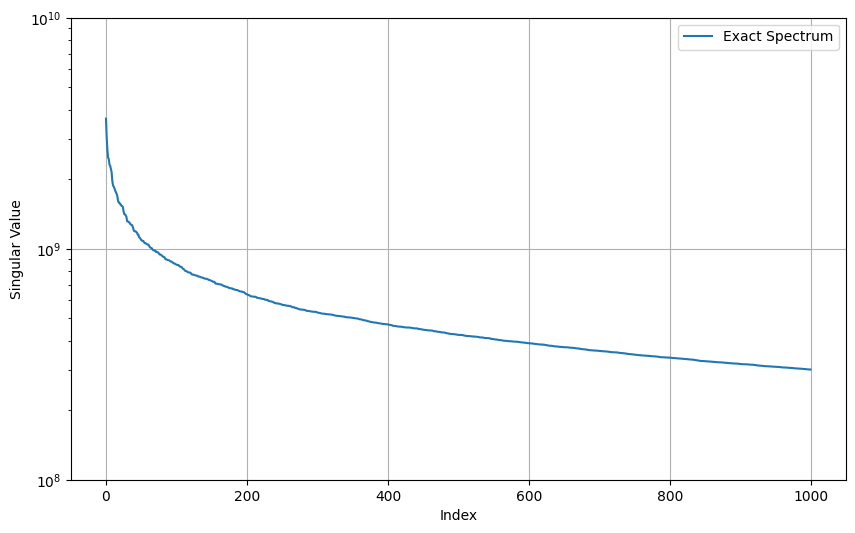

In [7]:
plt.figure(figsize=(10, 6))
# plt.plot(S, label='Approximated Spectrum')
plt.plot(S_exact[:1000], label='Exact Spectrum')
plt.xlabel('Index')
plt.ylabel('Singular Value')
# plt.title(f'Comparison of Approximated and Exact Spectra iteration {iteration}')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.ylim([1e8, 1e10])
# plt.savefig(dir_path + f'/spectrum_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
plt.show()
# plt.close('all')

In [148]:
# n, k = U_exact.shape
# tol=1e-8
# U_ortho = np.allclose(np.dot(U_exact[:].T, U_exact), np.eye(k), atol=tol)
# V_ortho = np.allclose(np.dot(Vt_exact, Vt_exact.T), np.eye(k), atol=tol)
# print(f"U orthogonal: {U_ortho}")
# print(f"V orthogonal: {V_ortho}")

# frobenius_diff = np.linalg.norm(U_exact - Vt_exact.T)
# print(f"Frobenius norm of (U - V^T): {frobenius_diff}")

U orthogonal: True
V orthogonal: True
Frobenius norm of (U - V^T): 6.95397139402849e-06


In [6]:
# A_dense = A_csr.todense()
# is_symmetric = np.allclose(A_dense, A_dense.T)
# eigvals = np.linalg.eigvals(A_dense)
# is_psd = np.all(eigvals >= -1e-10)  # Allow for small numerical errors
# print("Is symmetric:", is_symmetric)
# print("Is positive semidefinite:", is_psd)

In [6]:
# Compute exact SVD
# start_time = time.time()
# U_exact, S_exact, Vt_exact = sp.linalg.svd(A_csr.todense(), lapack_driver="gesdd")
# S_exact = S_exact  # reverse order to get largest first
# exact_time = time.time() - start_time
# exact_time

In [7]:
# Compute exact SVD
# start_time = time.time()
# U_exact, S_exact, Vt_exact = svds(A_csr, k=k, which='LM')
# S_exact = S_exact[::-1]  # reverse order to get largest first
# U_exact = U_exact[:, ::-1]
# Vt_exact = Vt_exact[::-1, :]
# exact_time = time.time() - start_time
# exact_time

Window: 1
Index: 241 2410
241


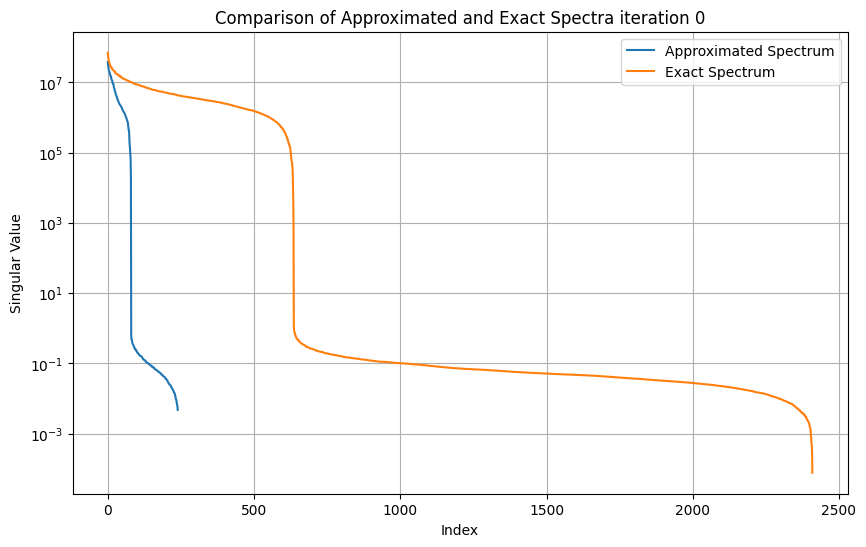

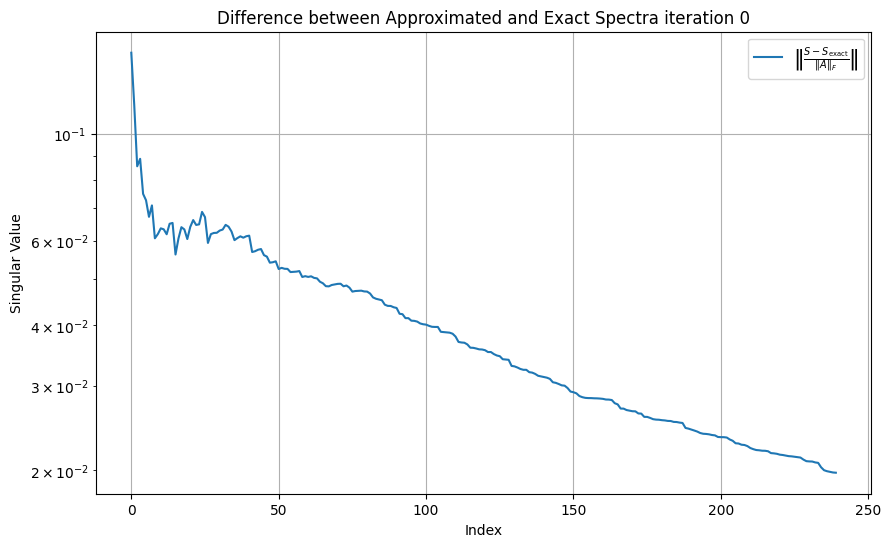

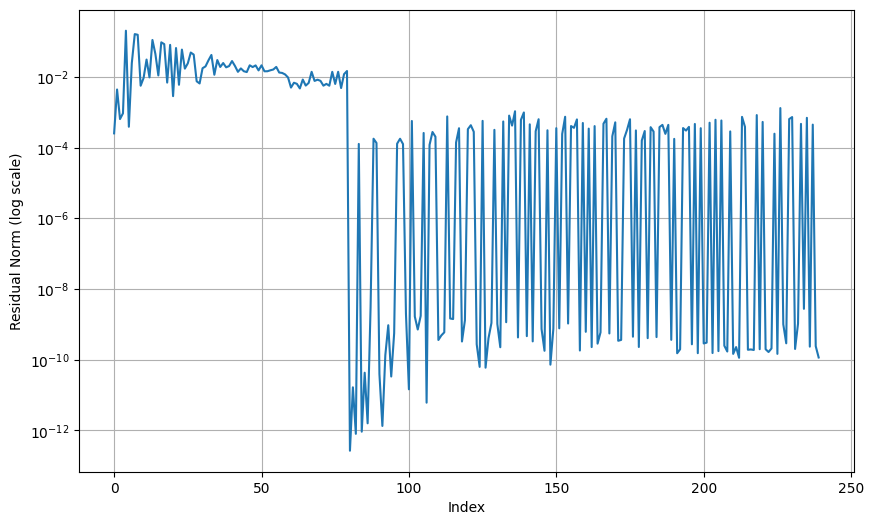

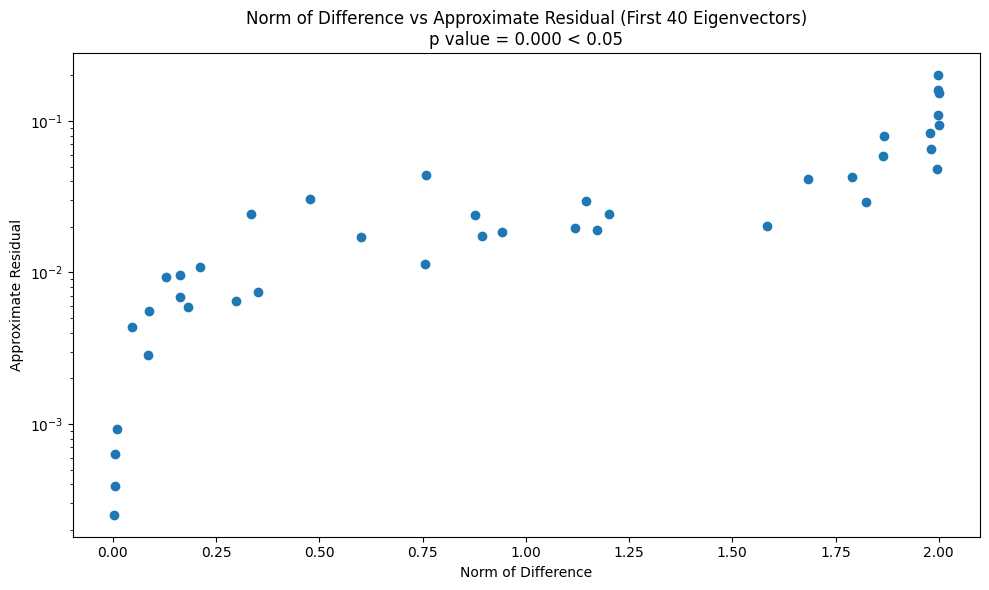

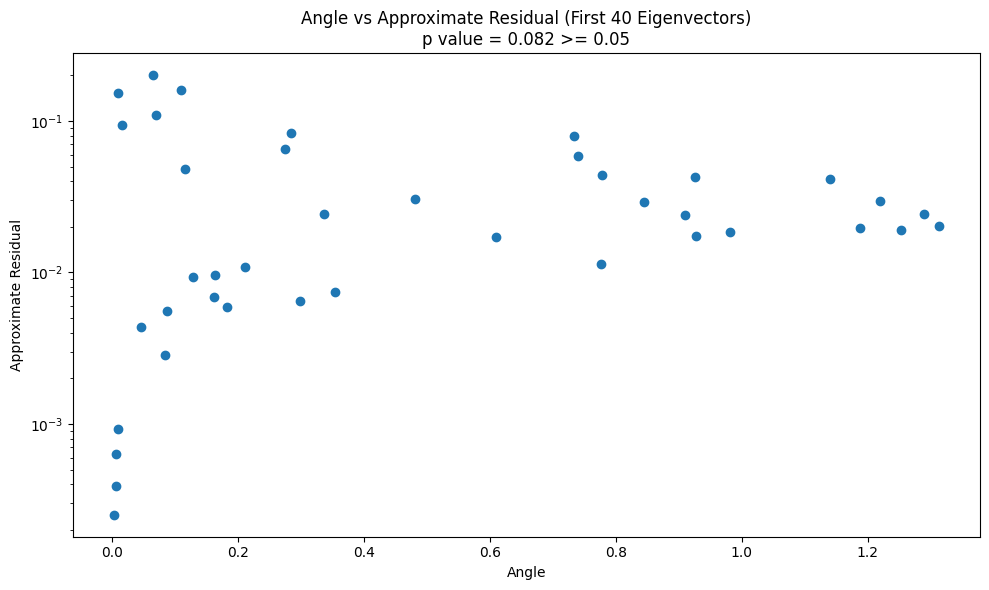

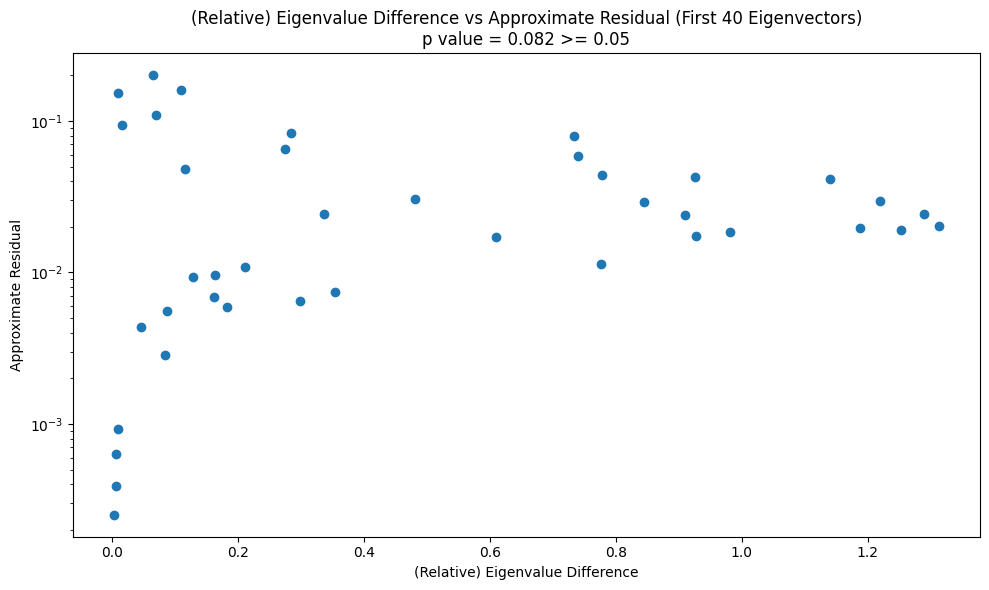

Subspace angle 2: 1.5707963267948966 1.3435731529364716


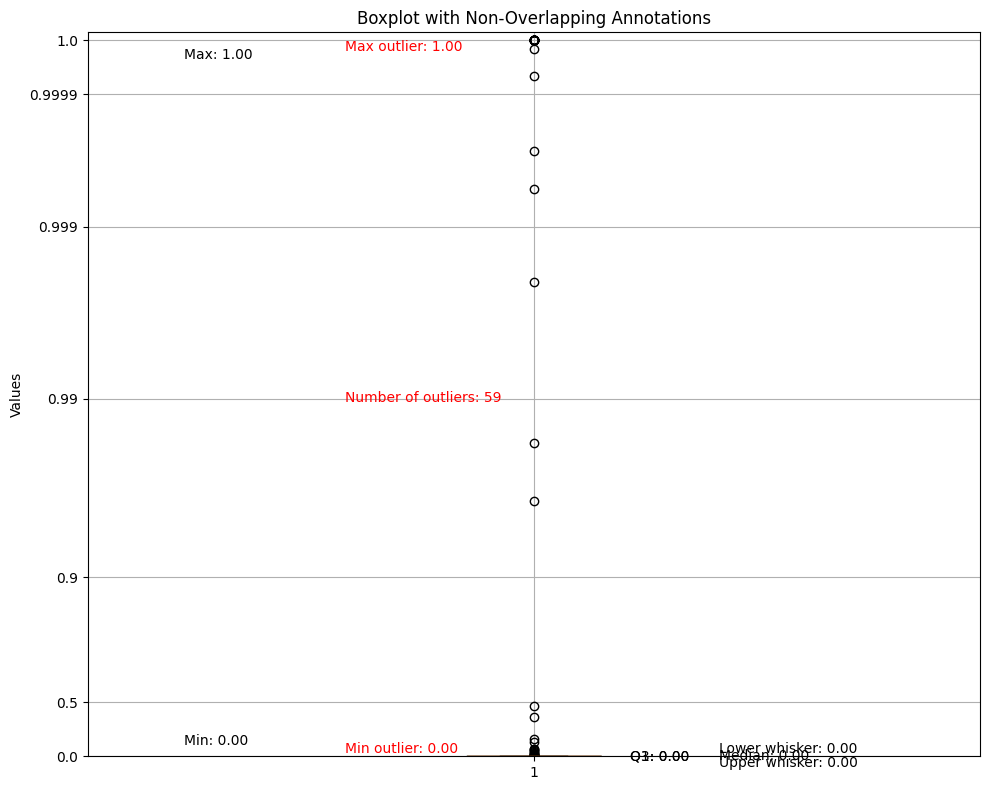

Reconstruction quality: 21.904107211790016
Relative error in S: 0.6732699427218554
Window: 2
Index: 482 2410
481


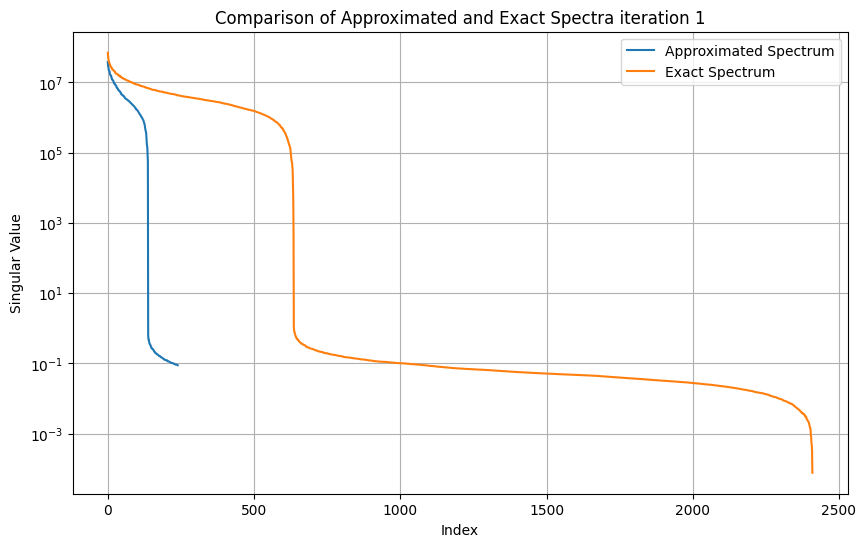

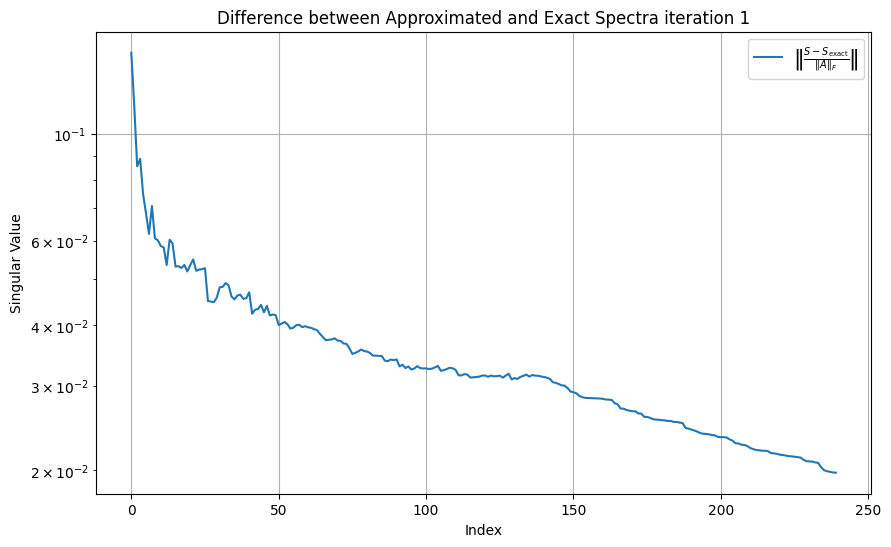

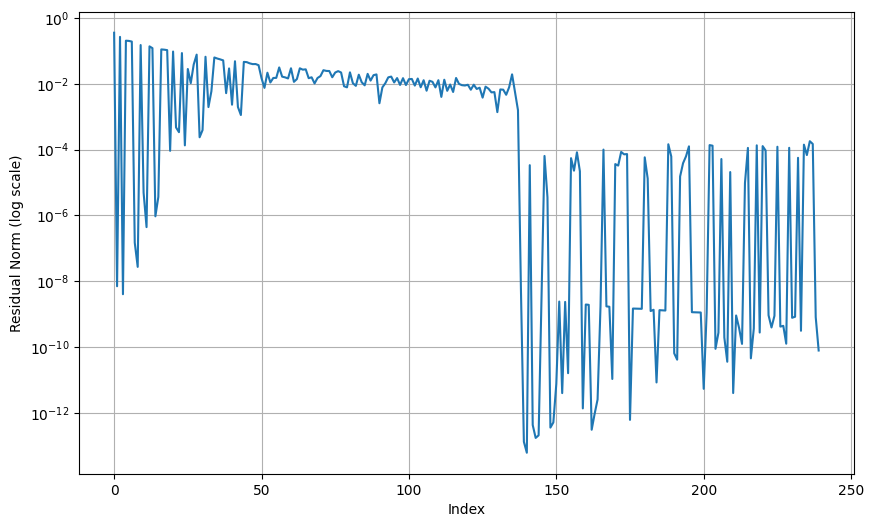

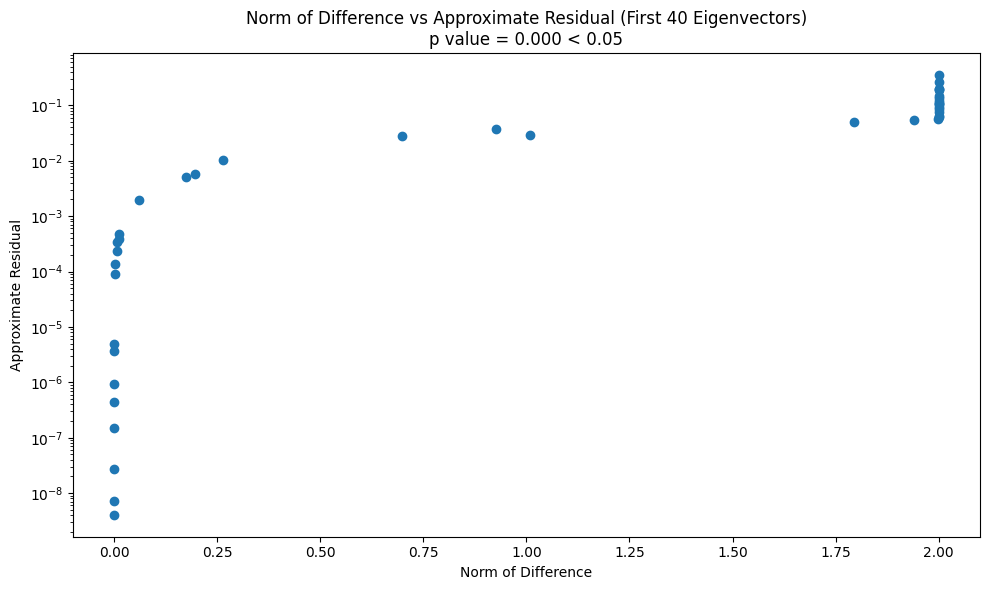

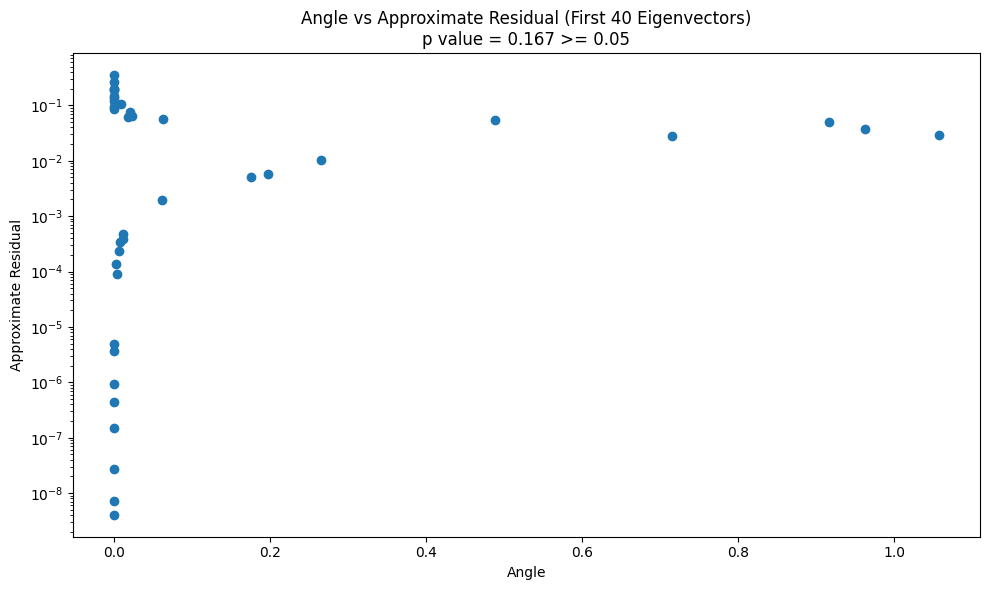

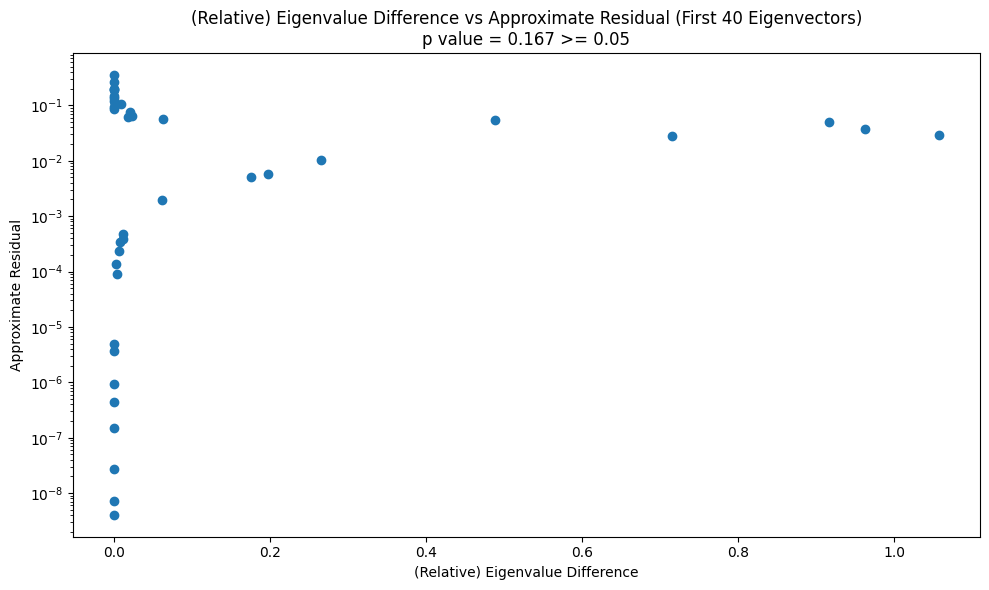

Subspace angle 2: 1.5707963267948966 1.2133168586993945


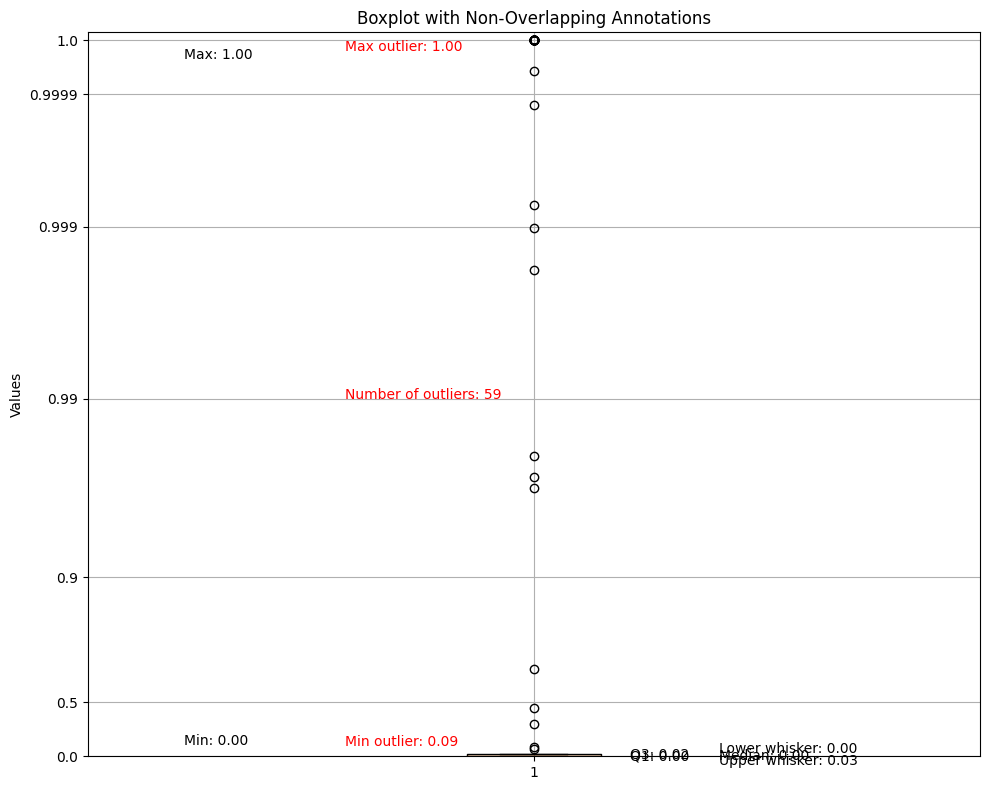

Reconstruction quality: 21.909073287628534
Relative error in S: 0.5842256192582632
Window: 3
Index: 723 2410
481


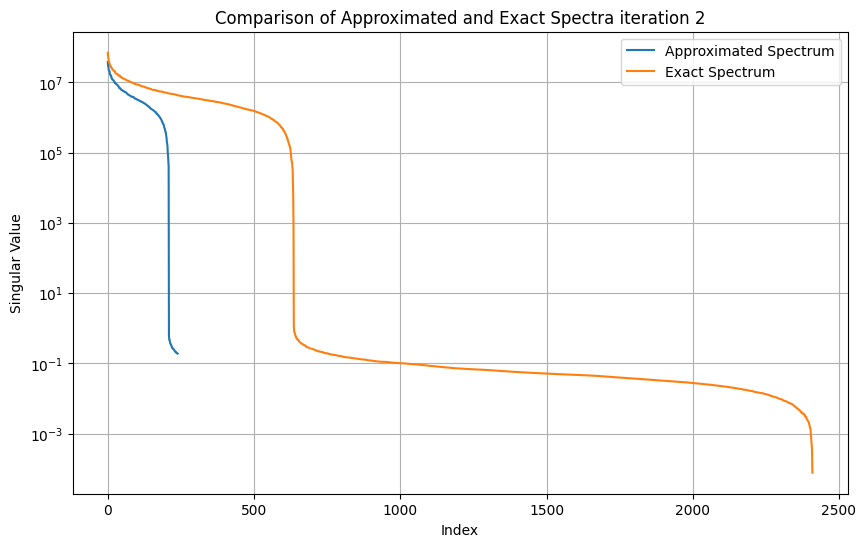

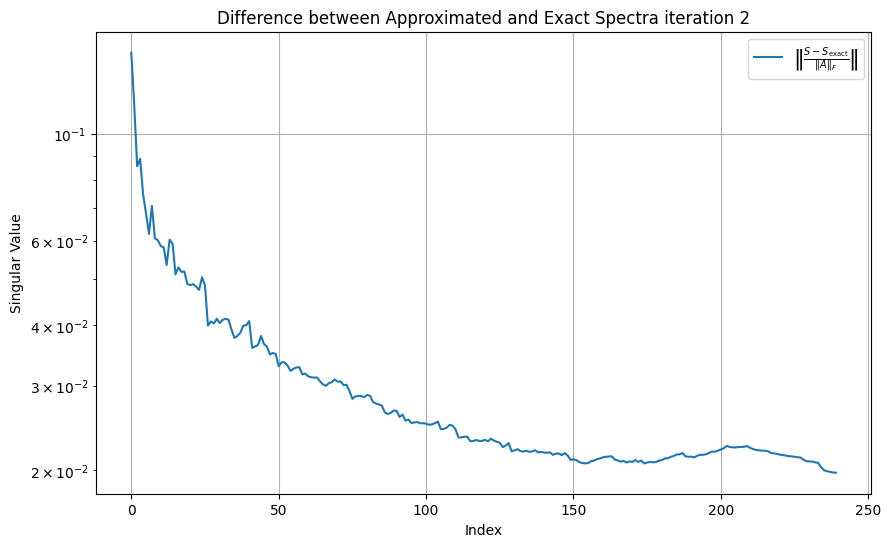

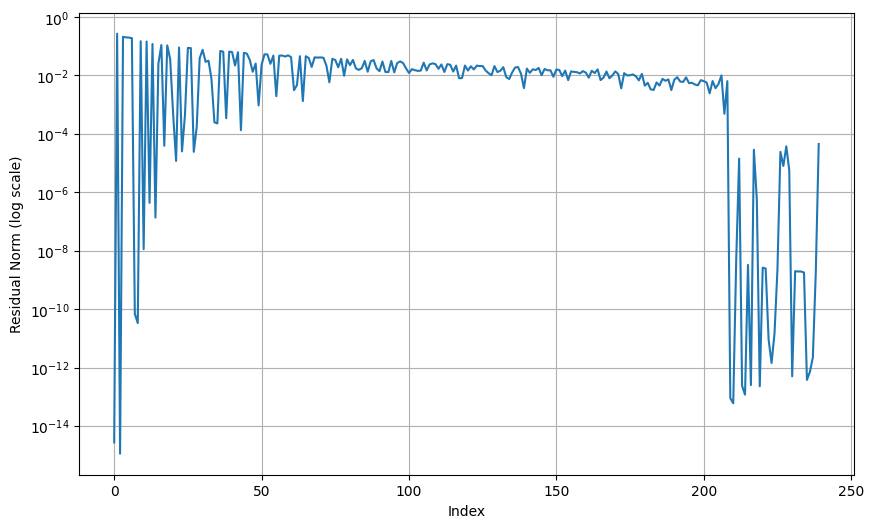

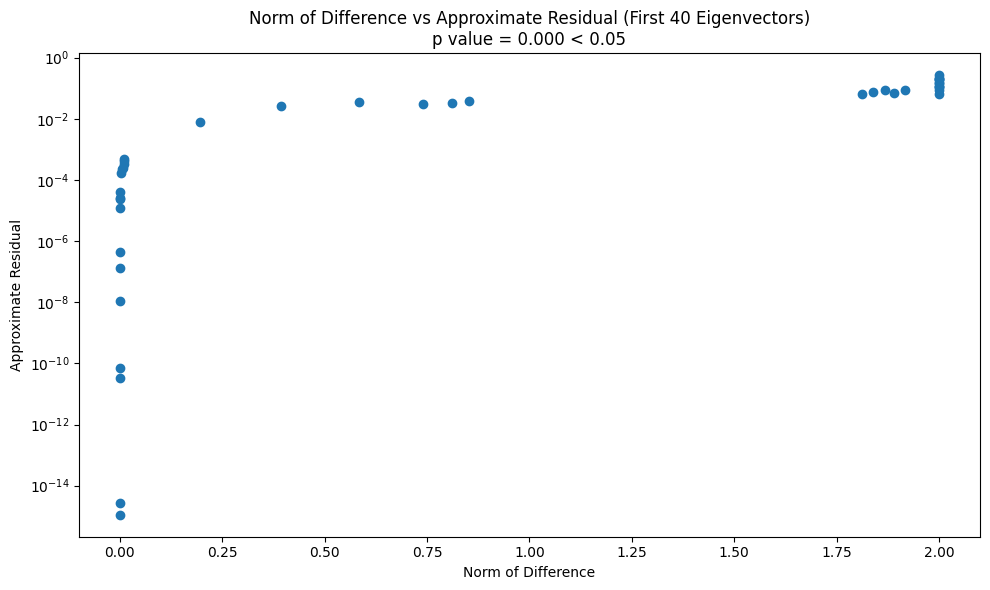

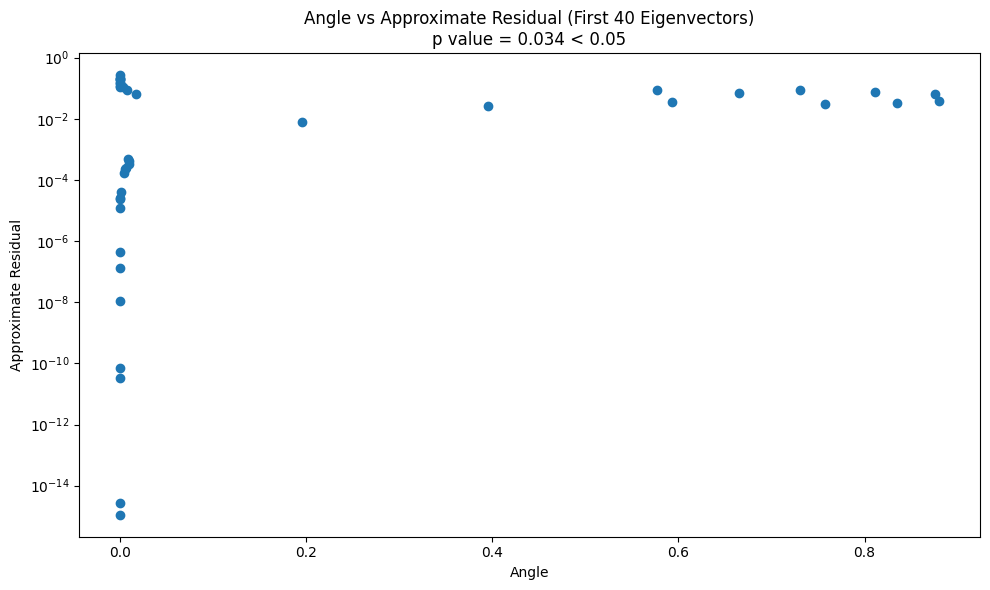

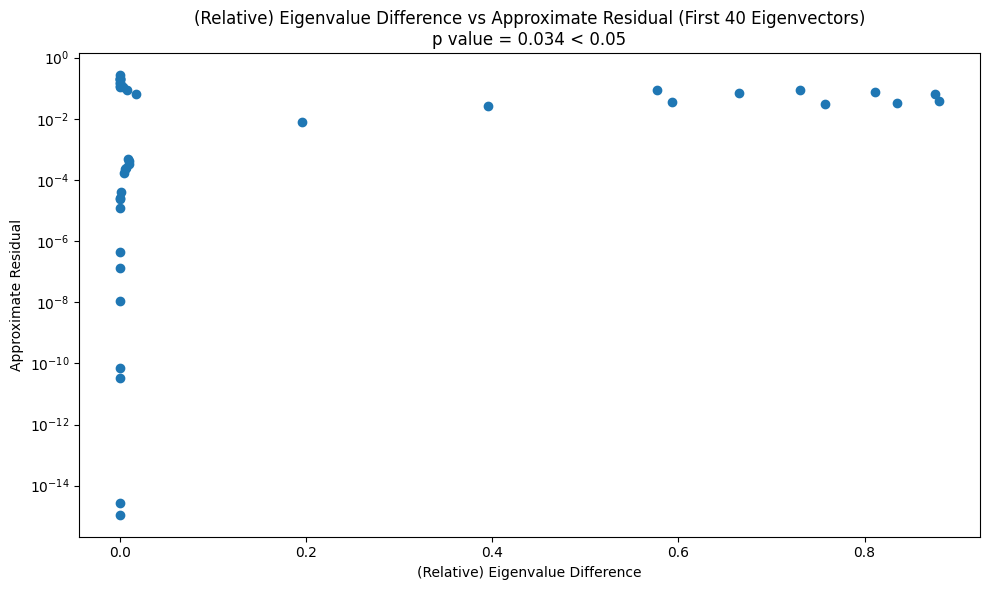

Subspace angle 2: 1.5707963267948966 1.0595070887883566


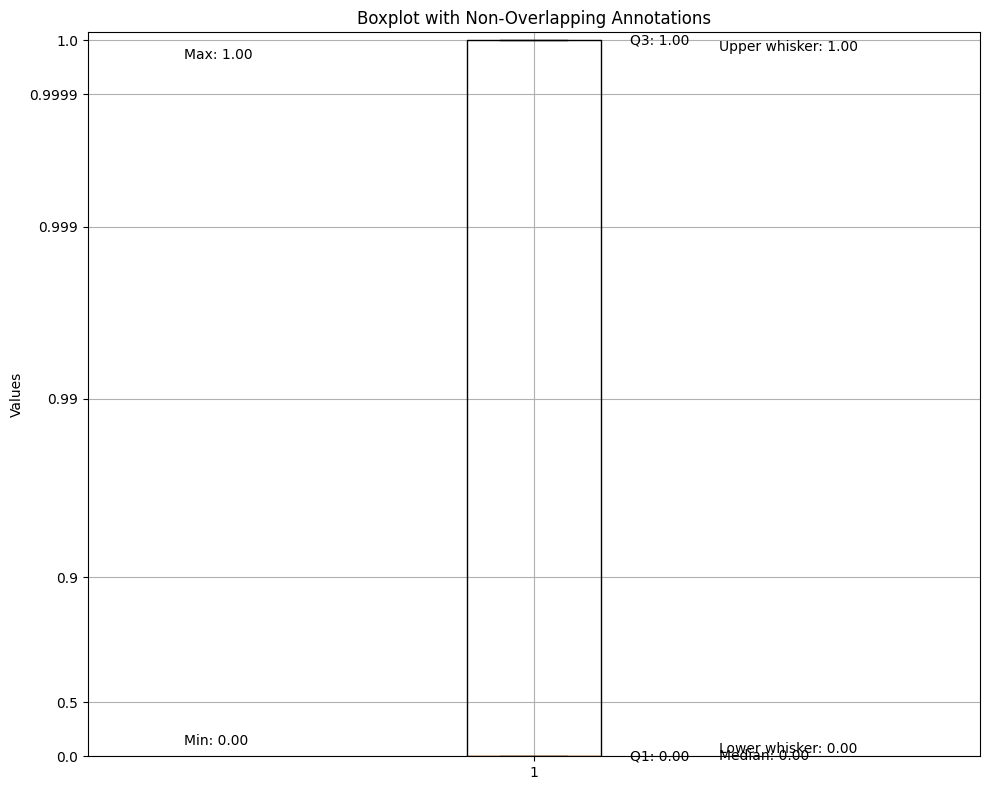

Reconstruction quality: 21.90953020560662
Relative error in S: 0.5156713407705322
Window: 4
Index: 964 2410
481


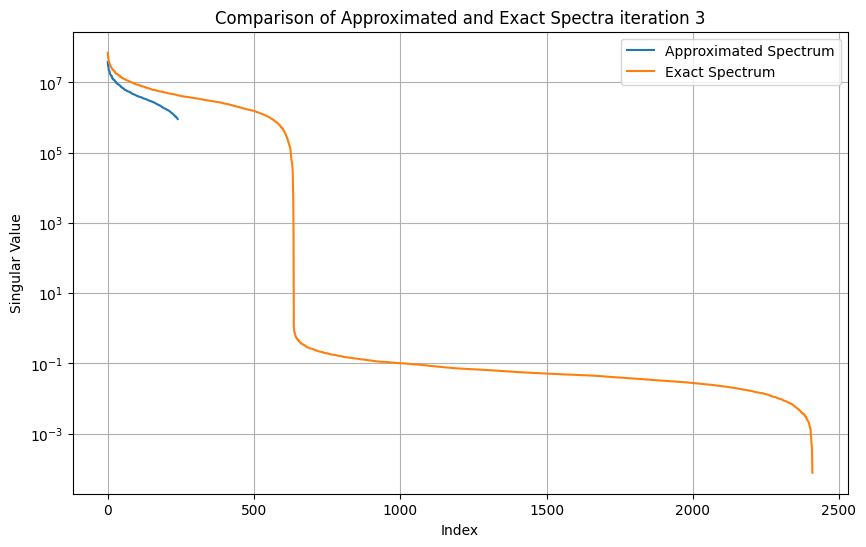

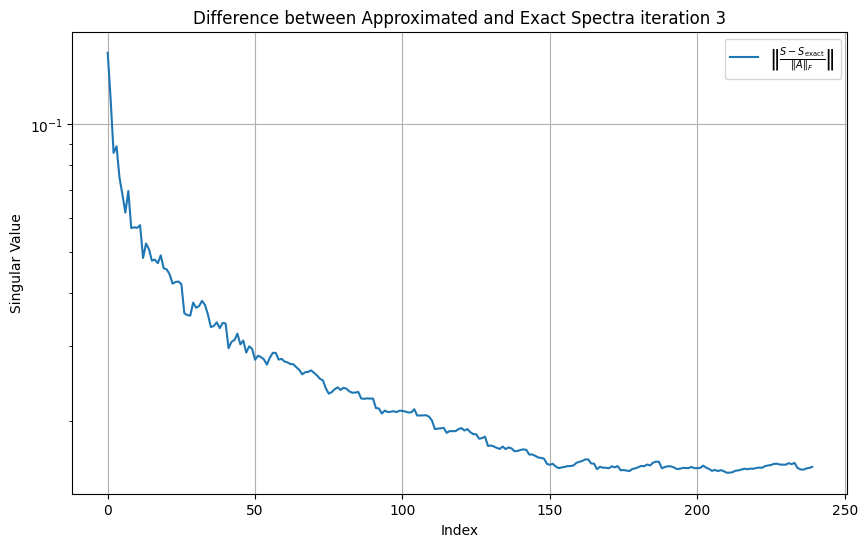

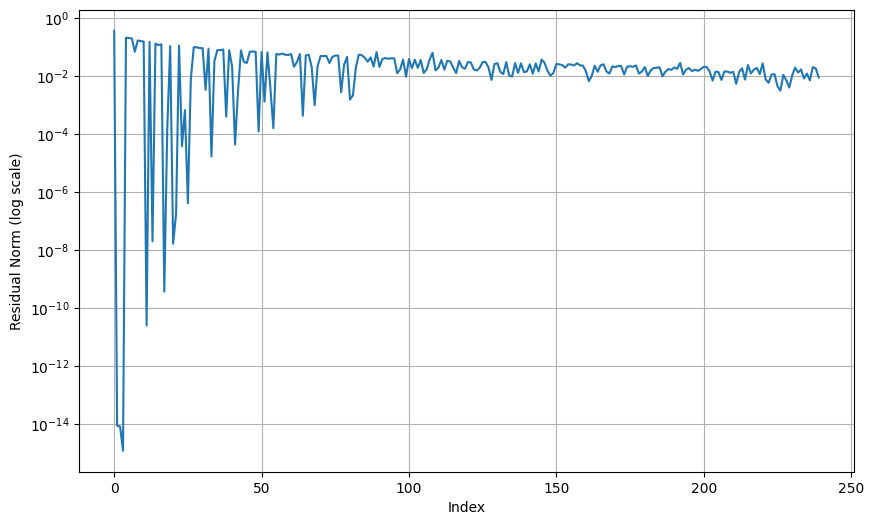

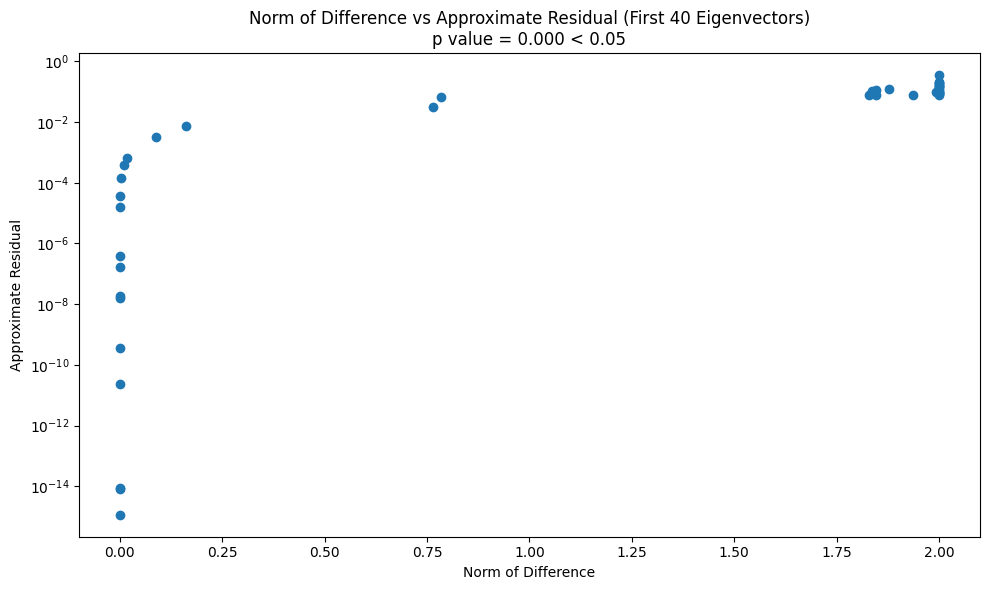

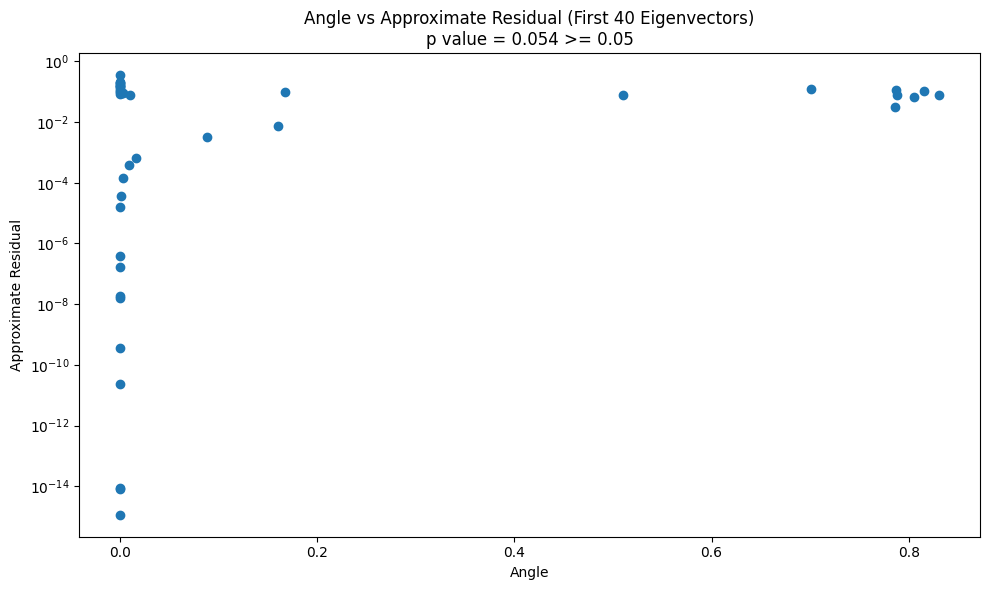

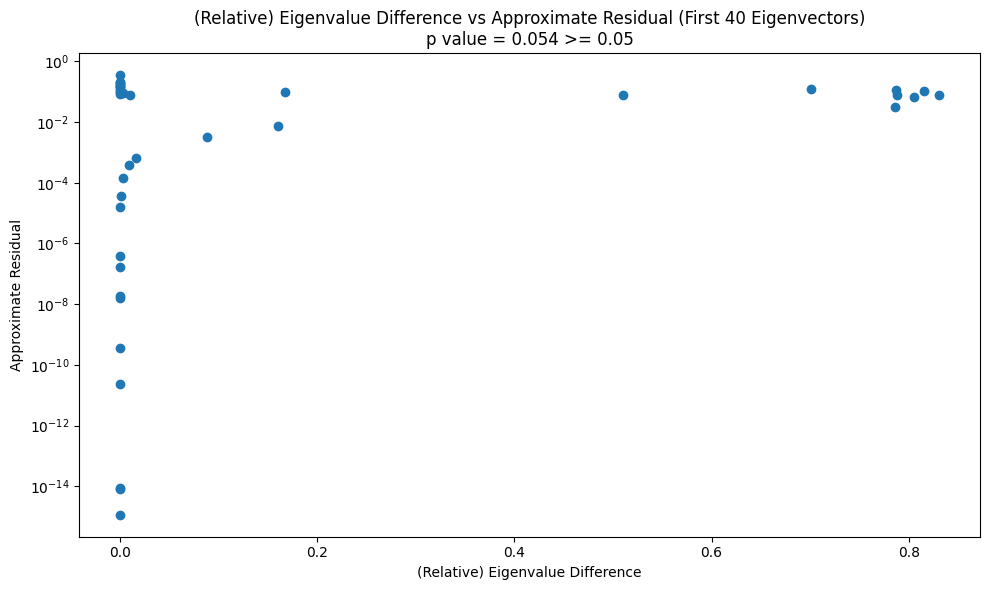

Subspace angle 2: 1.5707963267948966 0.9090716736597666


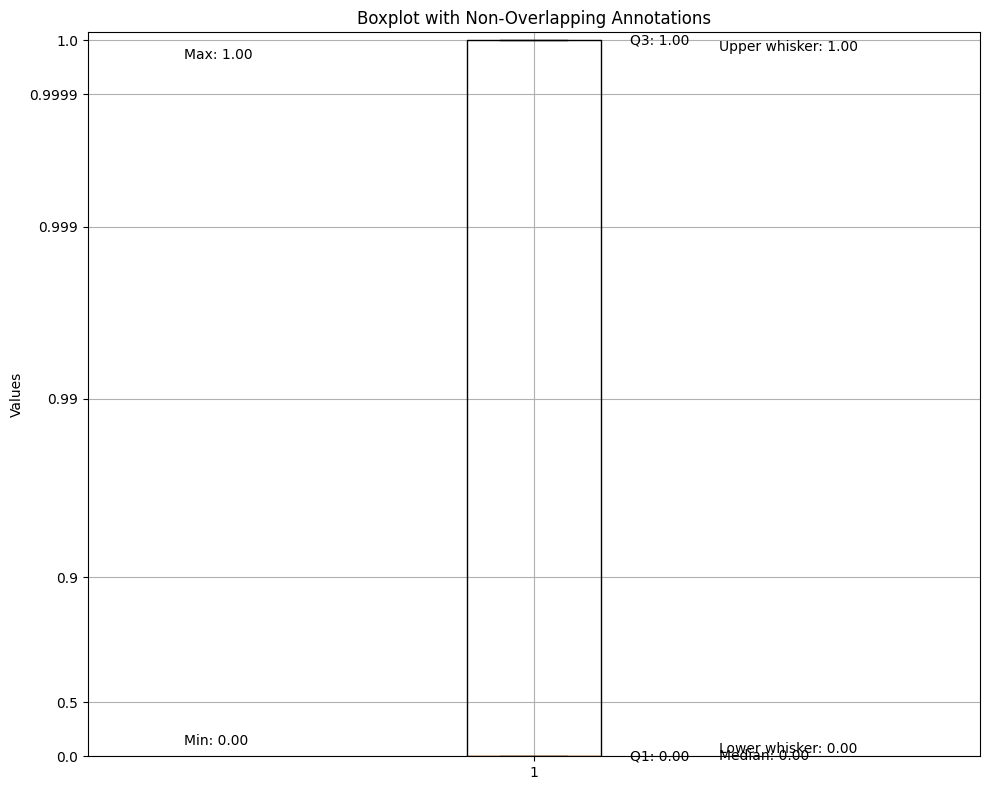

Reconstruction quality: 21.90936812567142
Relative error in S: 0.45789163647973874
Window: 5
Index: 1205 2410
481


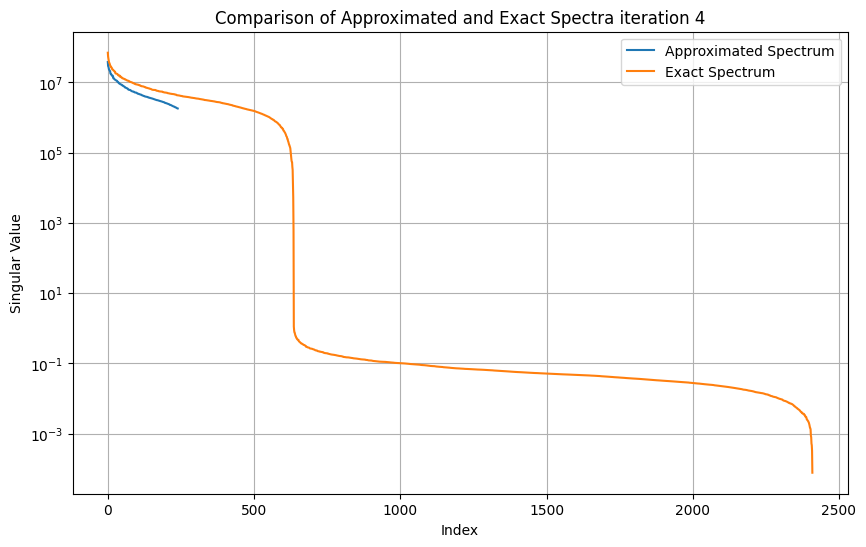

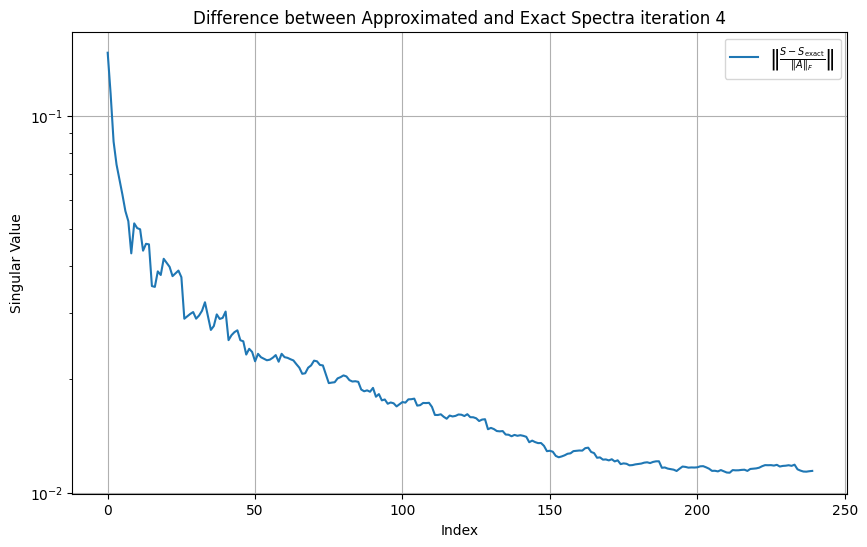

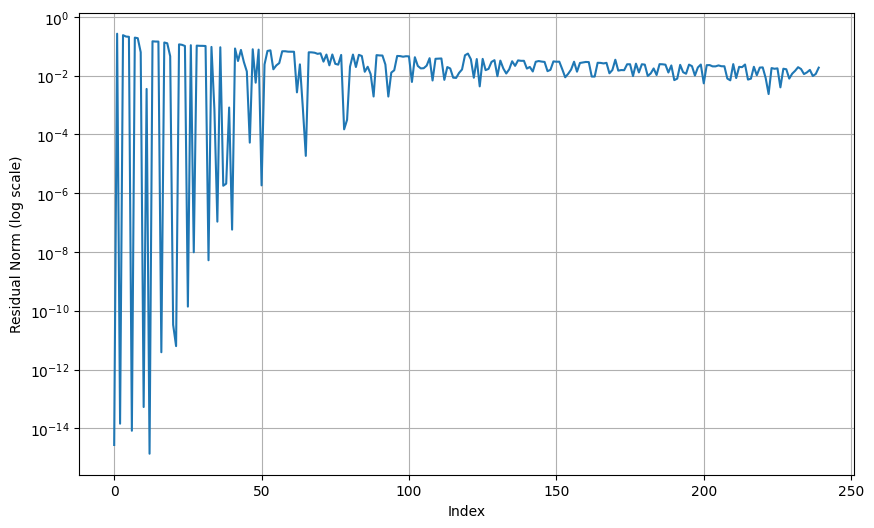

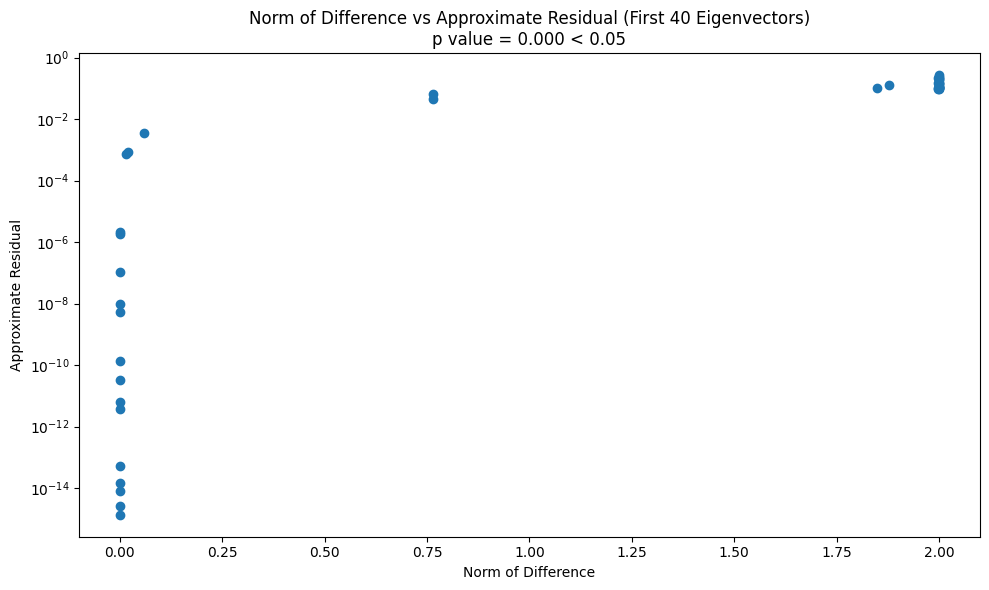

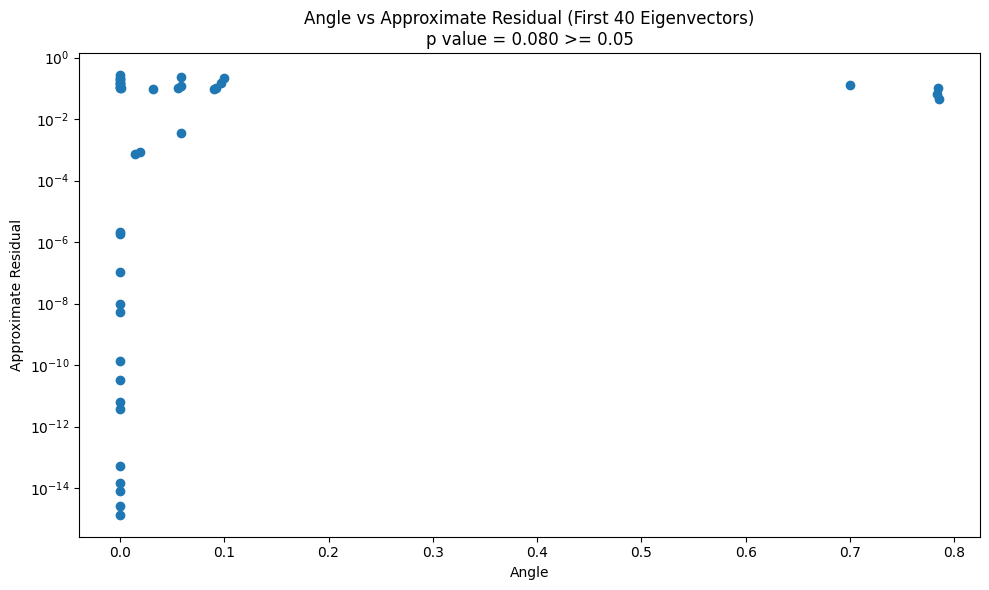

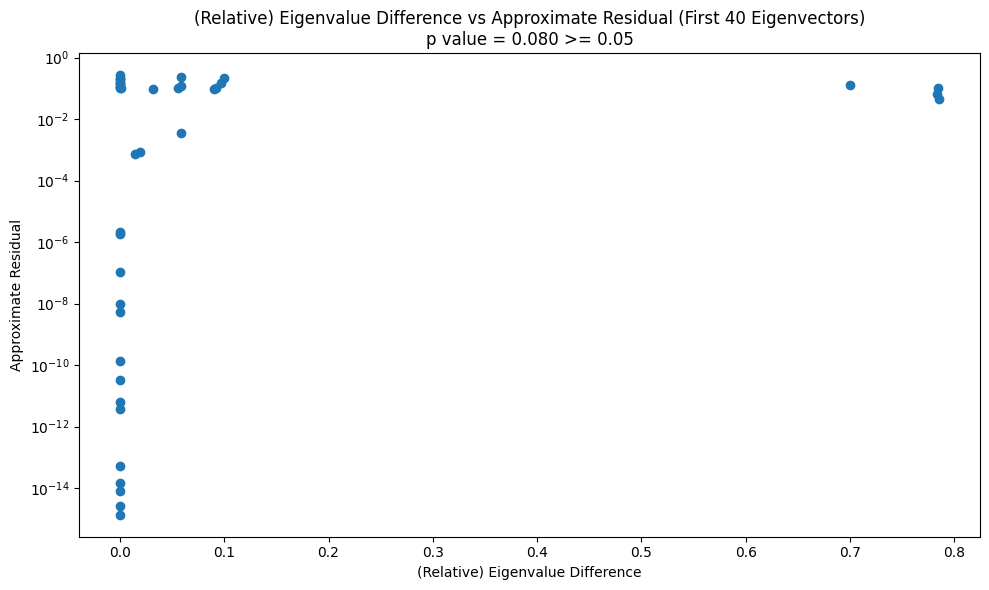

Subspace angle 2: 1.5707963267948966 0.7660976454901895


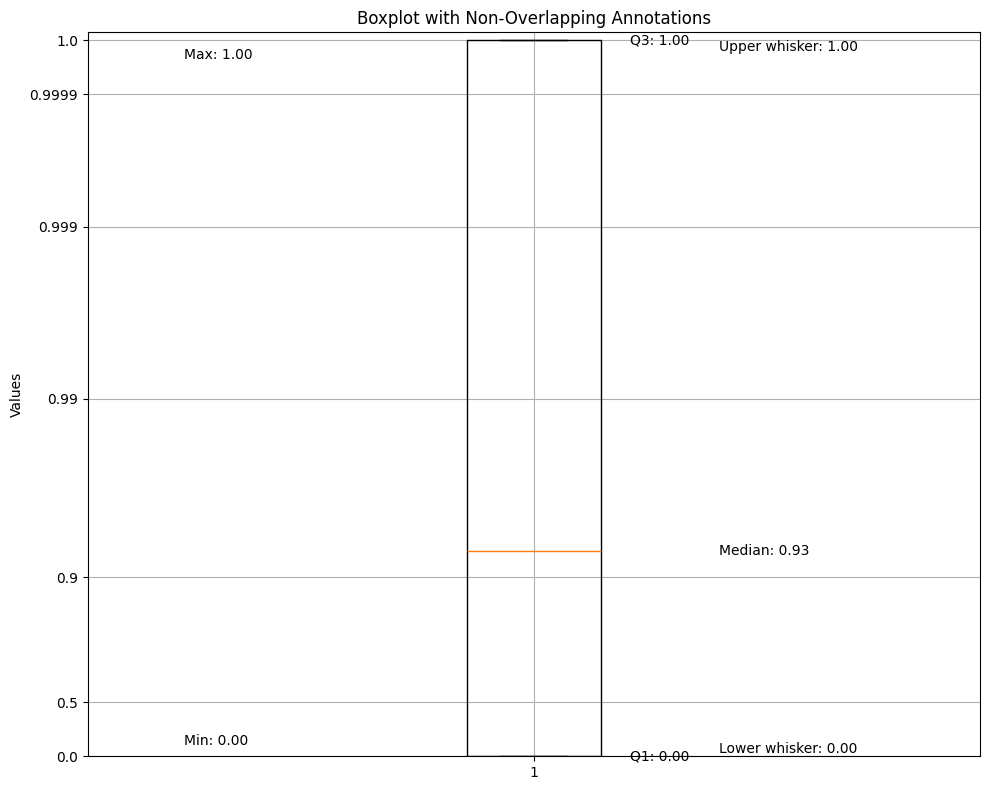

Reconstruction quality: 21.921980024964416
Relative error in S: 0.39842050170165894
Window: 6
Index: 1446 2410
481


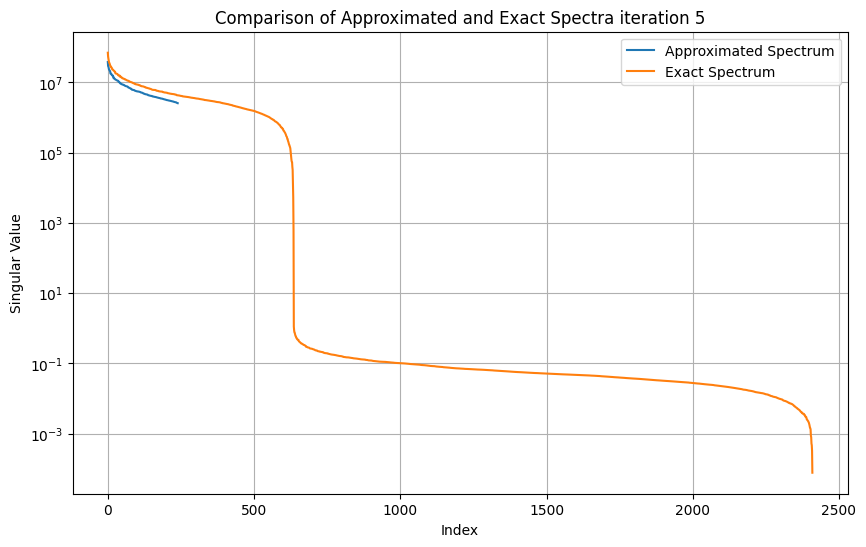

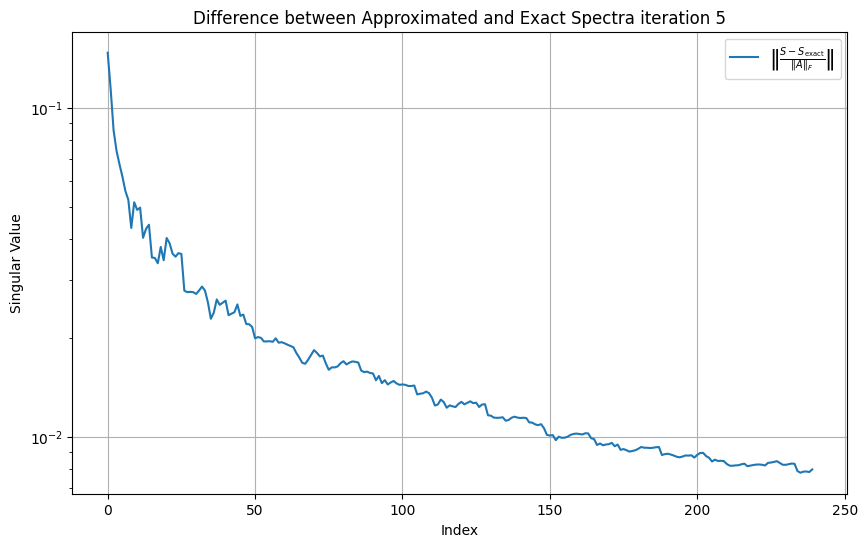

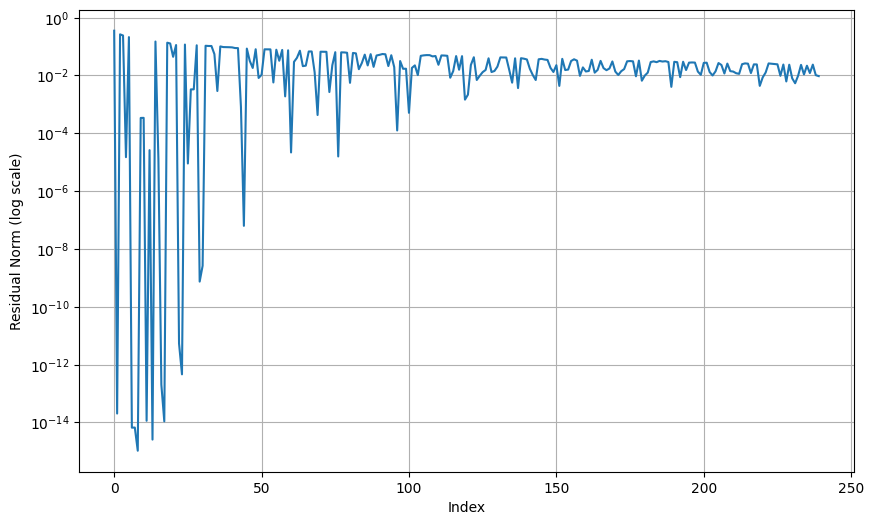

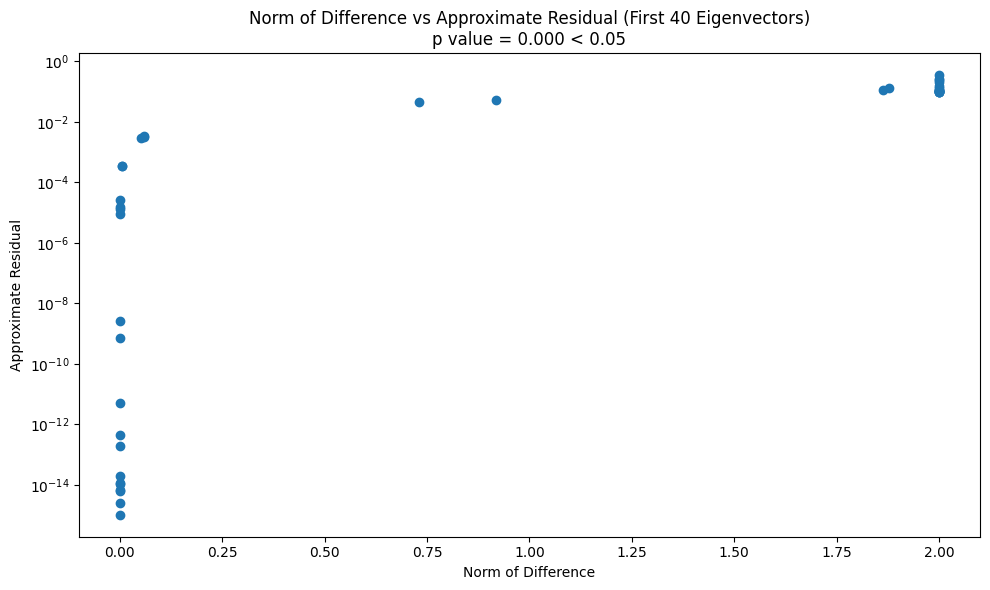

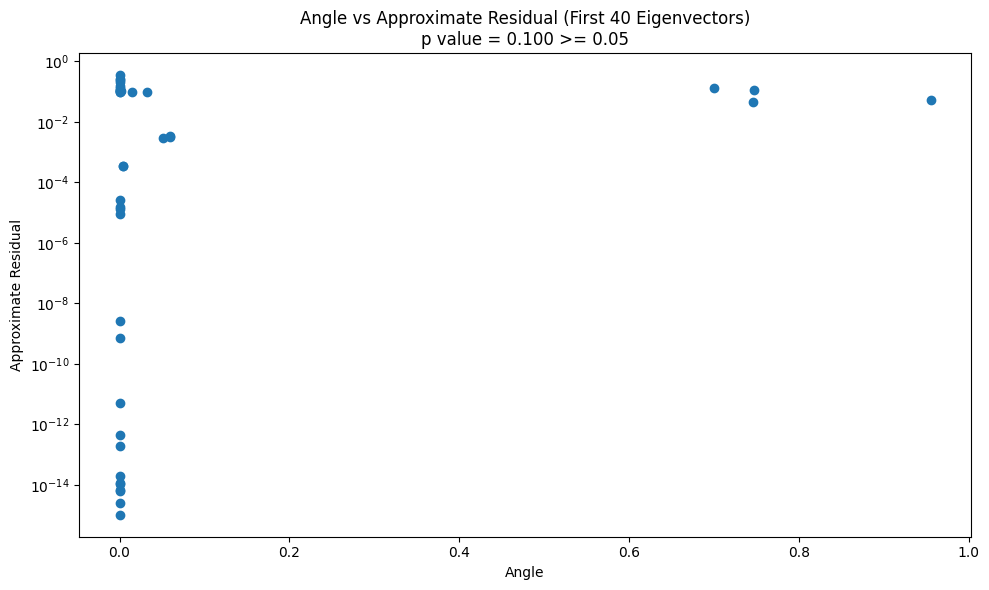

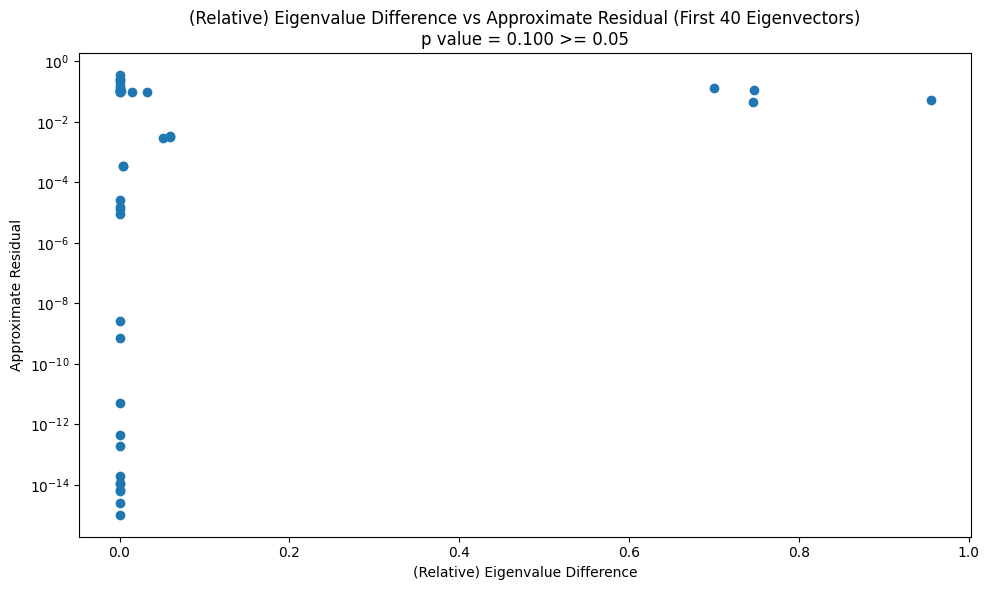

Subspace angle 2: 1.5707963267948966 0.6366841958321581


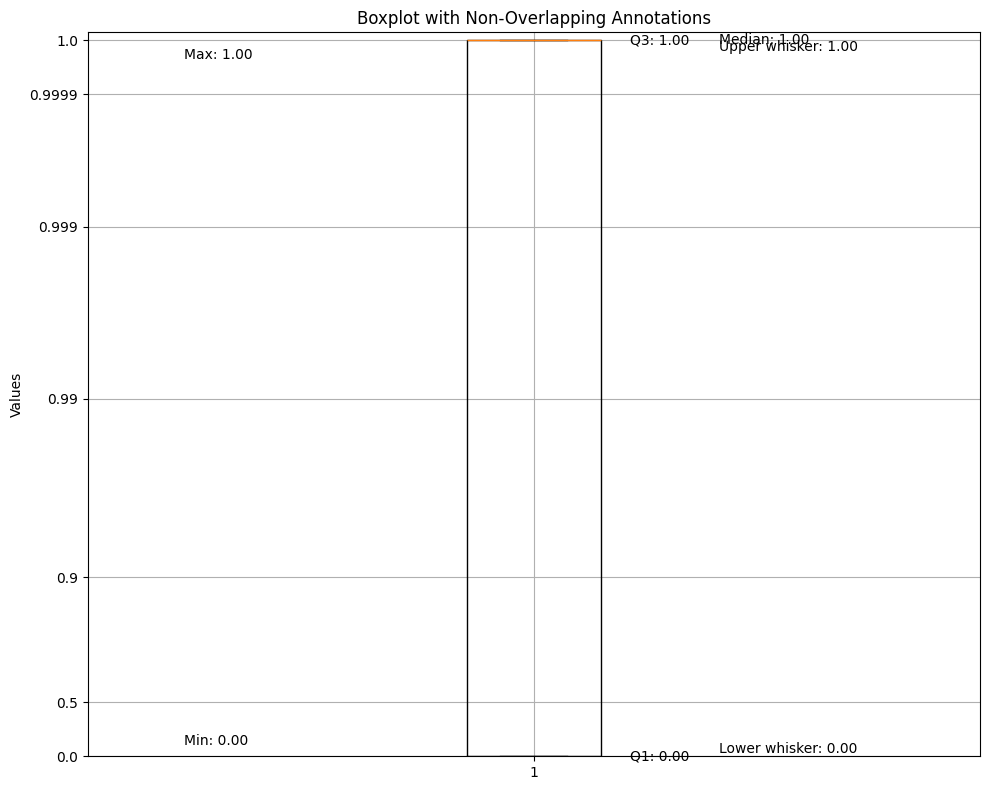

Reconstruction quality: 21.90553339978848
Relative error in S: 0.3693348375232348
Window: 7
Index: 1687 2410
481


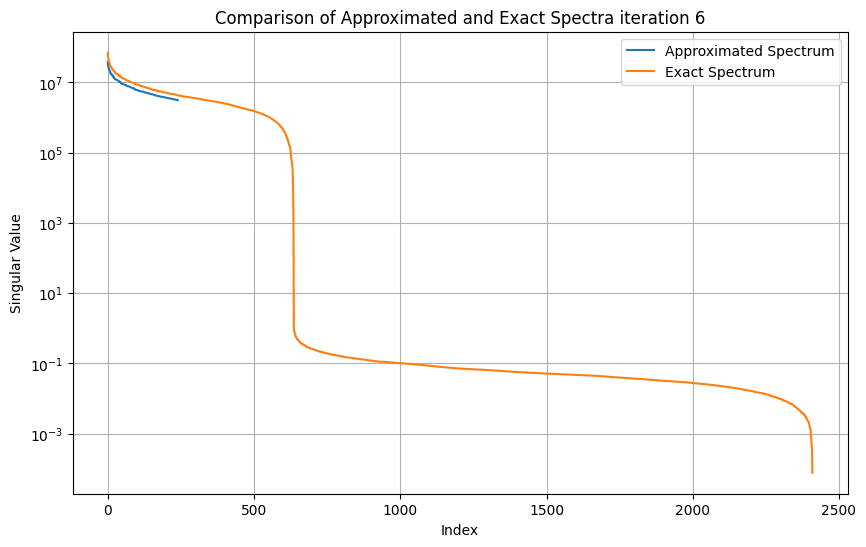

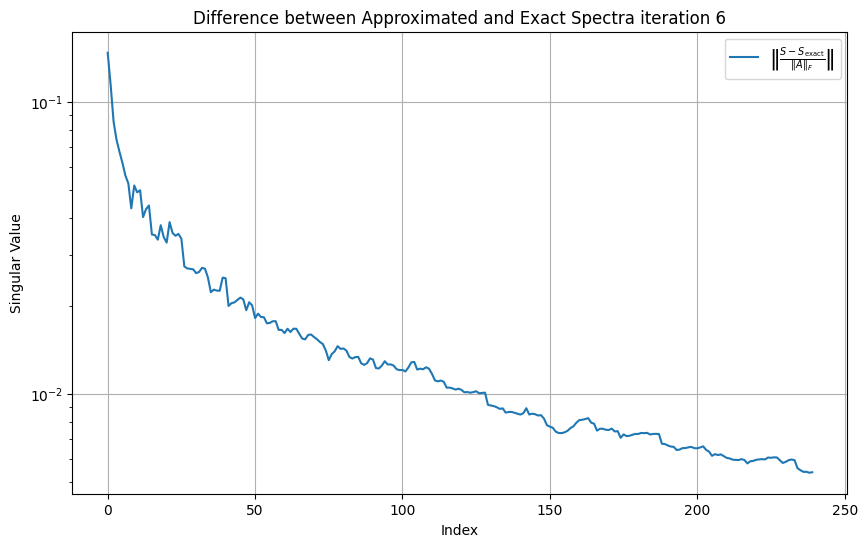

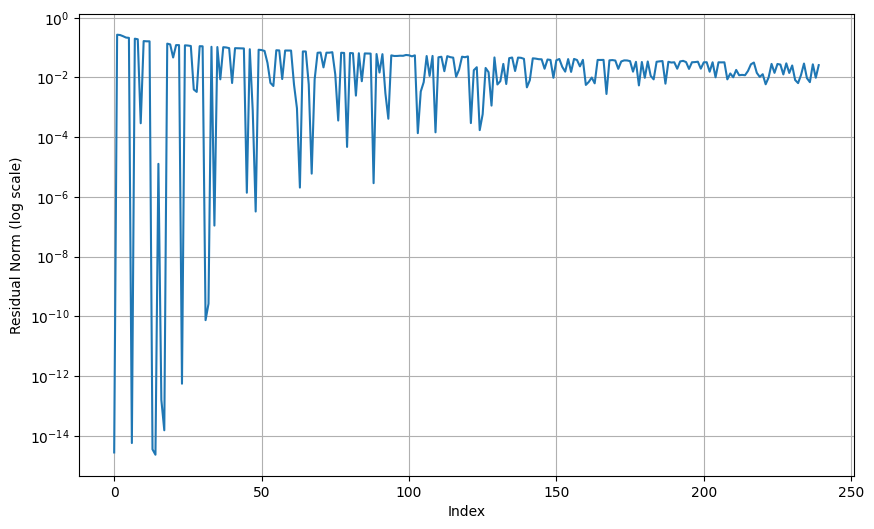

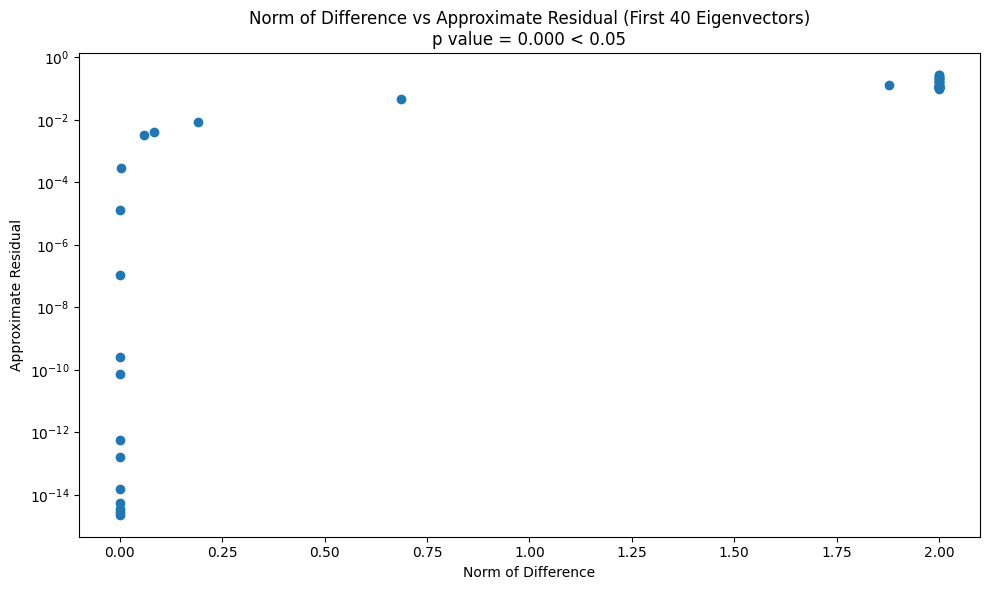

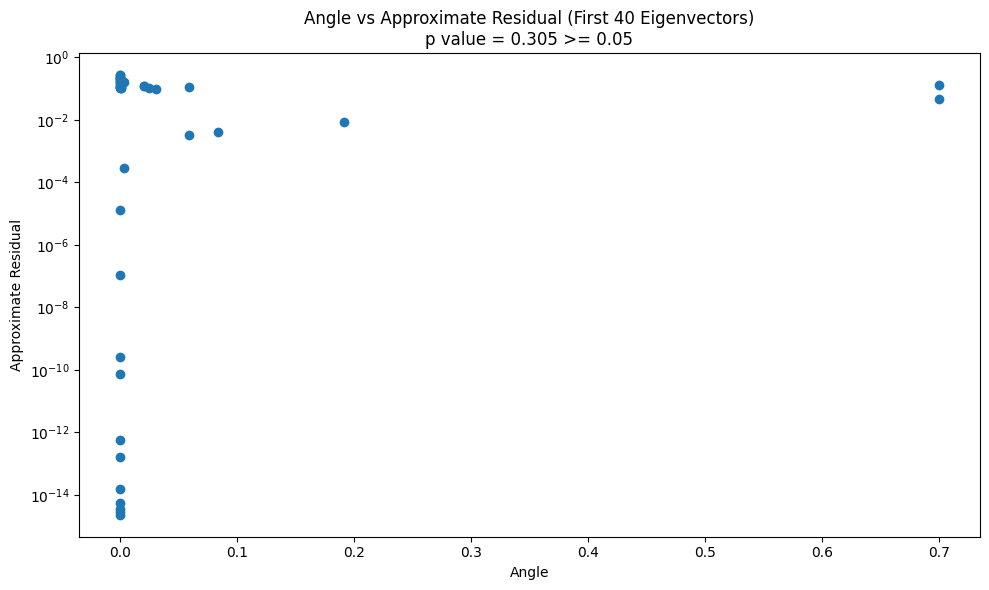

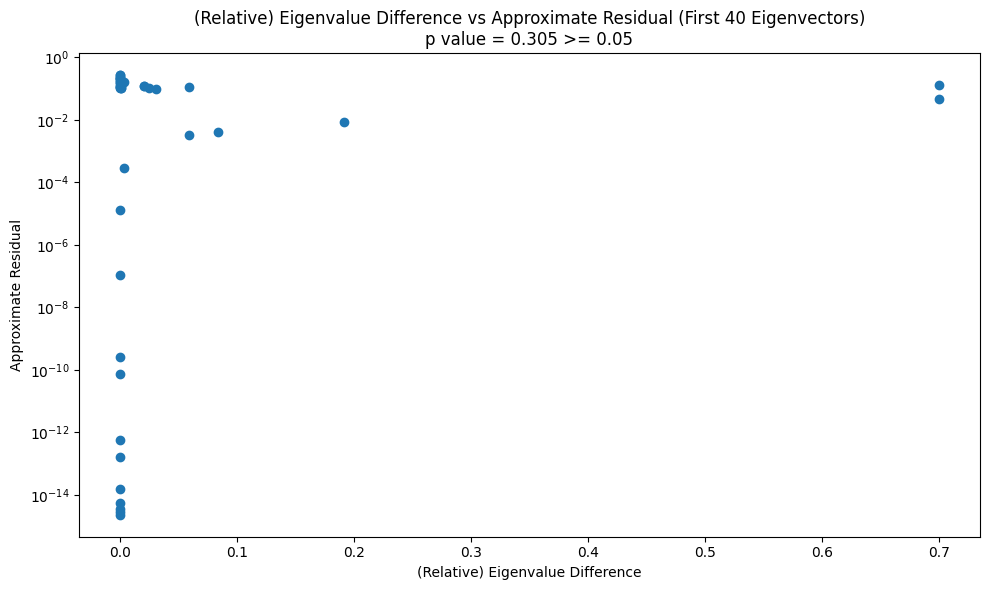

Subspace angle 2: 1.5707963267948966 0.4913087583107864


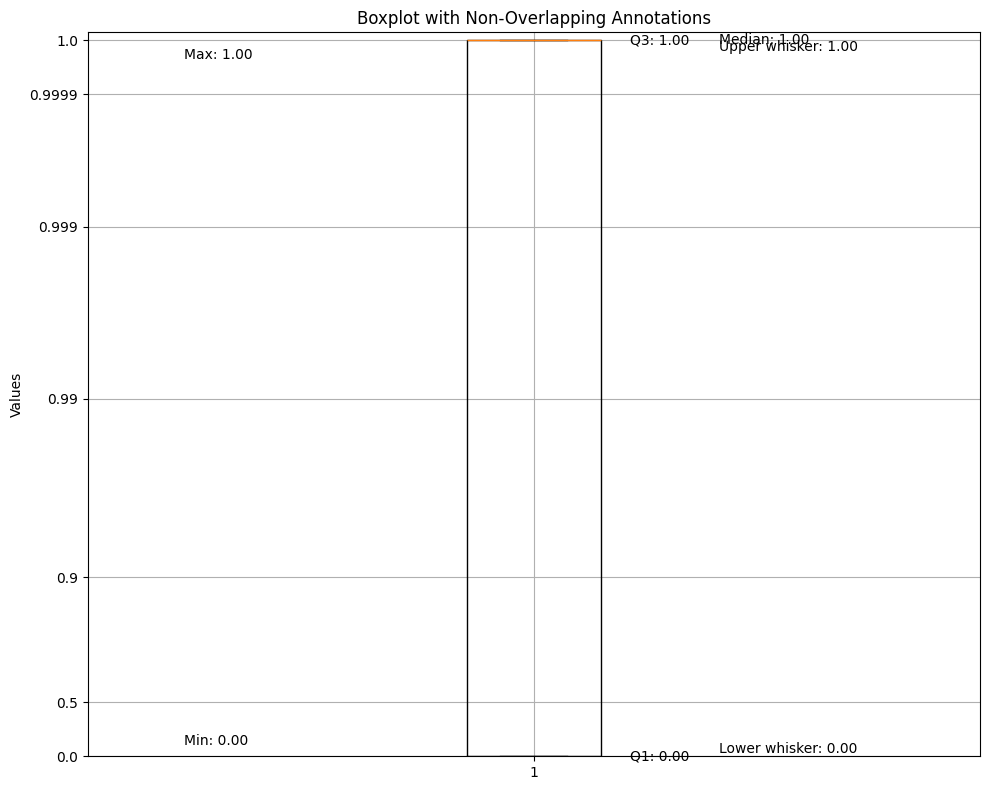

Reconstruction quality: 21.909421508157205
Relative error in S: 0.3525702602818146
Window: 8
Index: 1928 2410
481


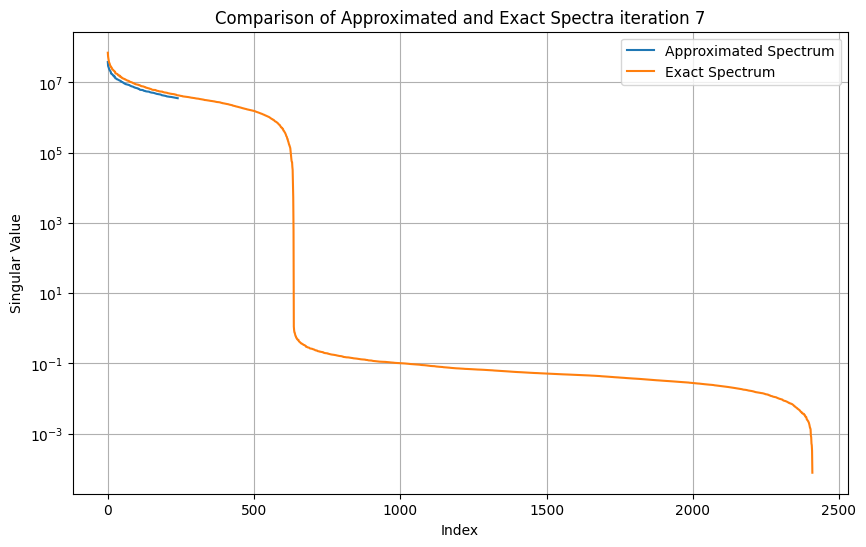

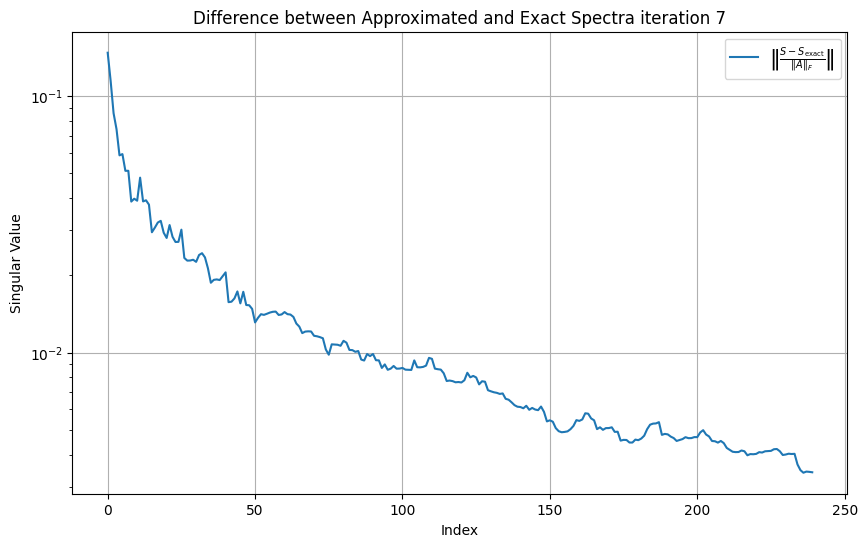

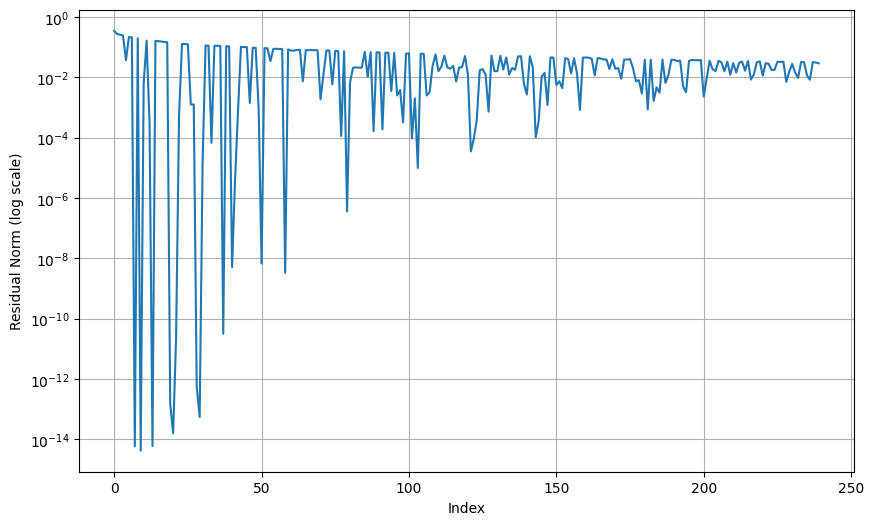

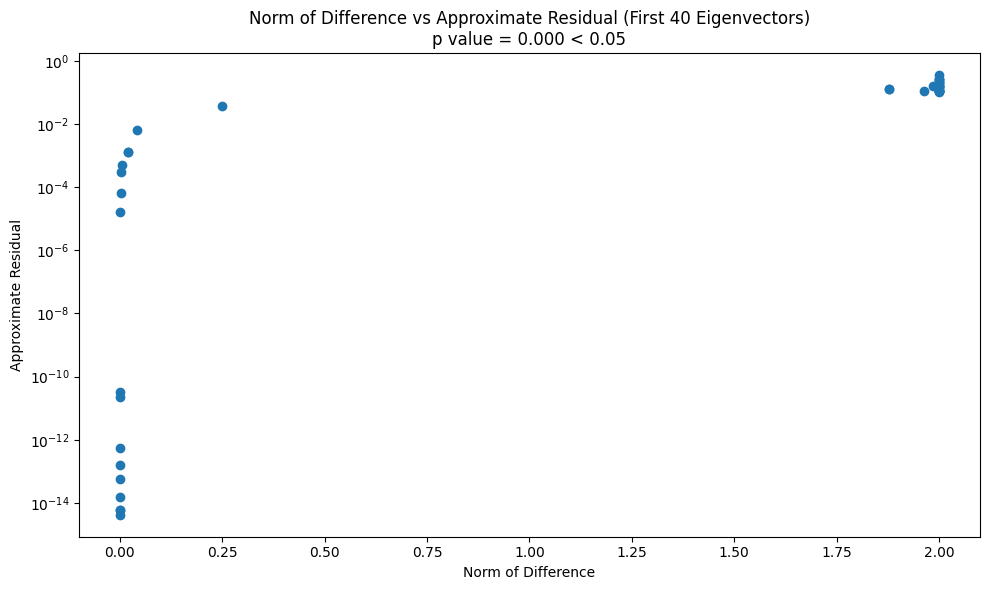

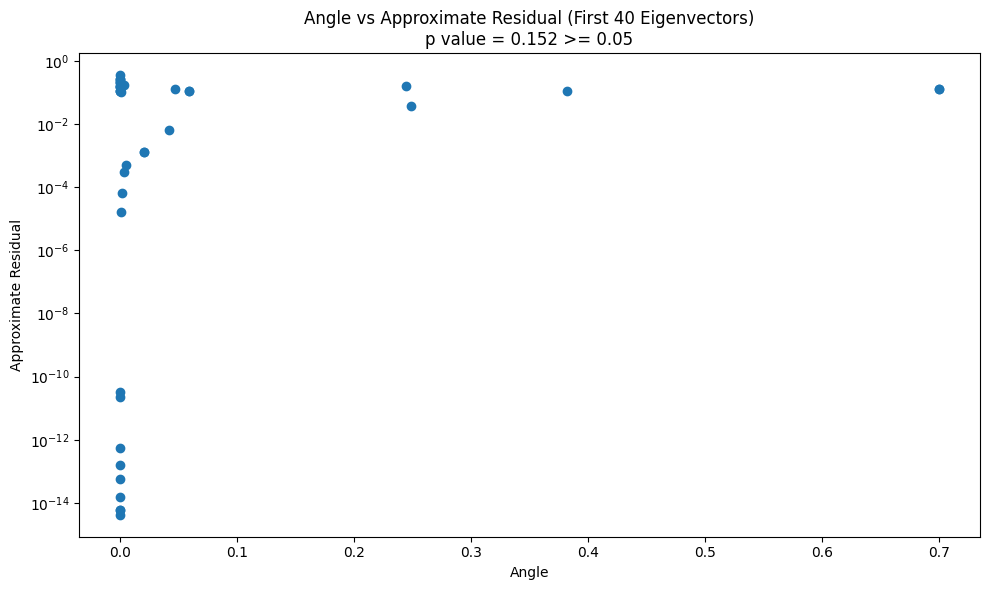

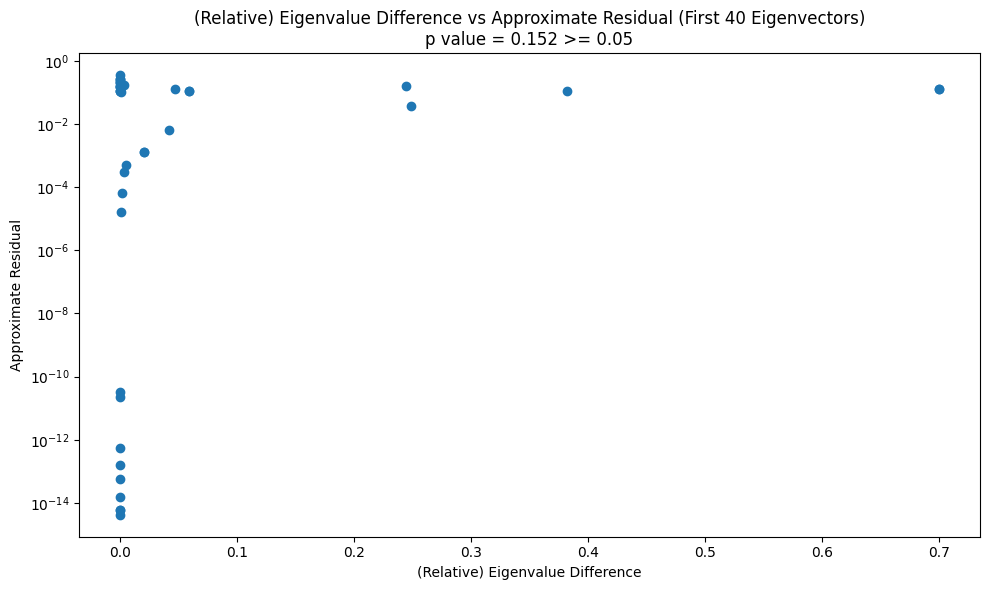

Subspace angle 2: 1.5707963267948966 0.3350108782355461


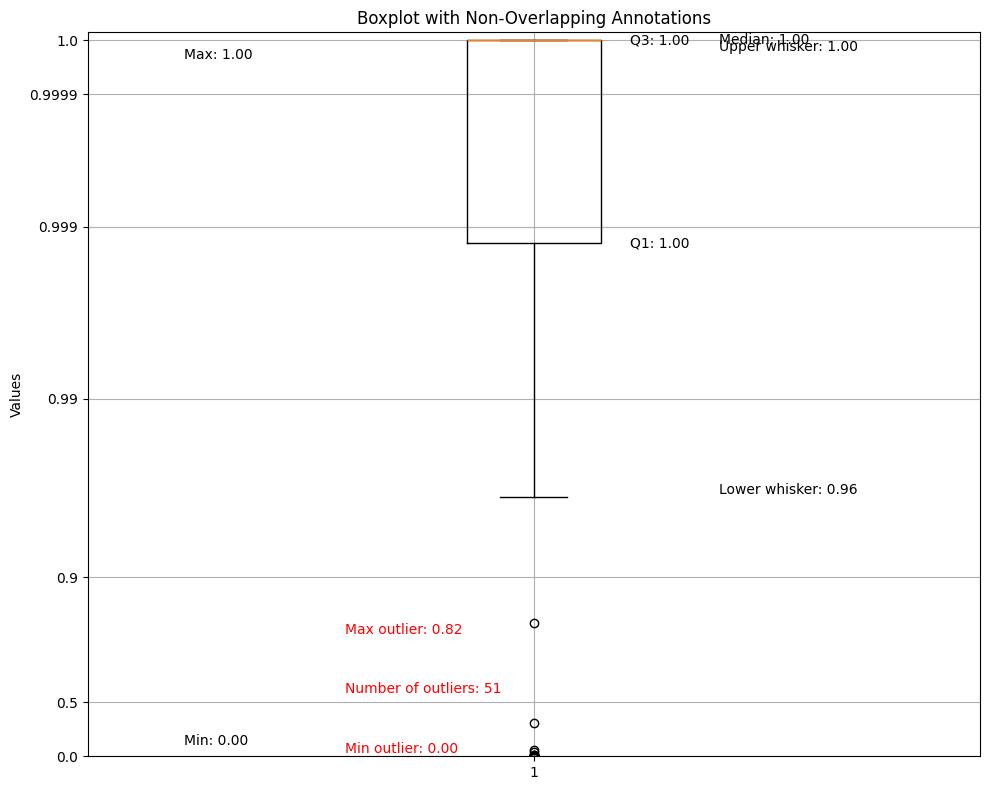

Reconstruction quality: 21.8910968385469
Relative error in S: 0.3189042013736928
Window: 9
Index: 2169 2410
481


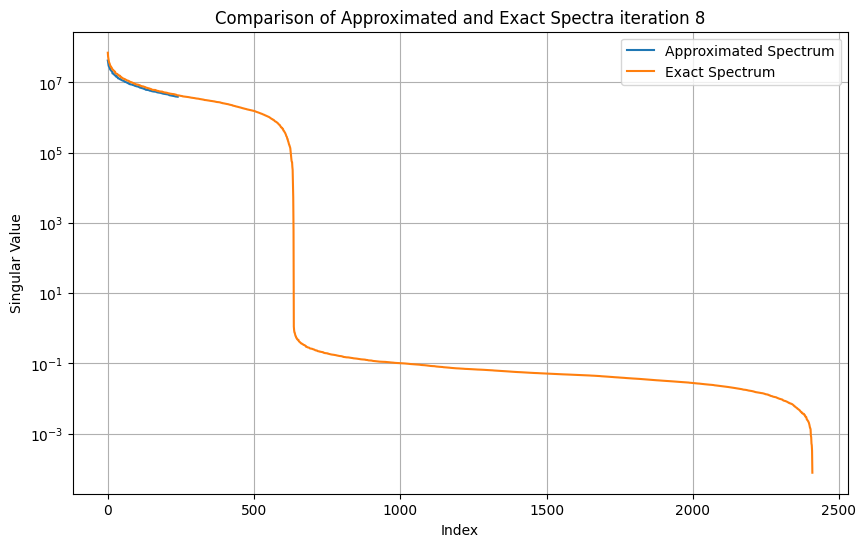

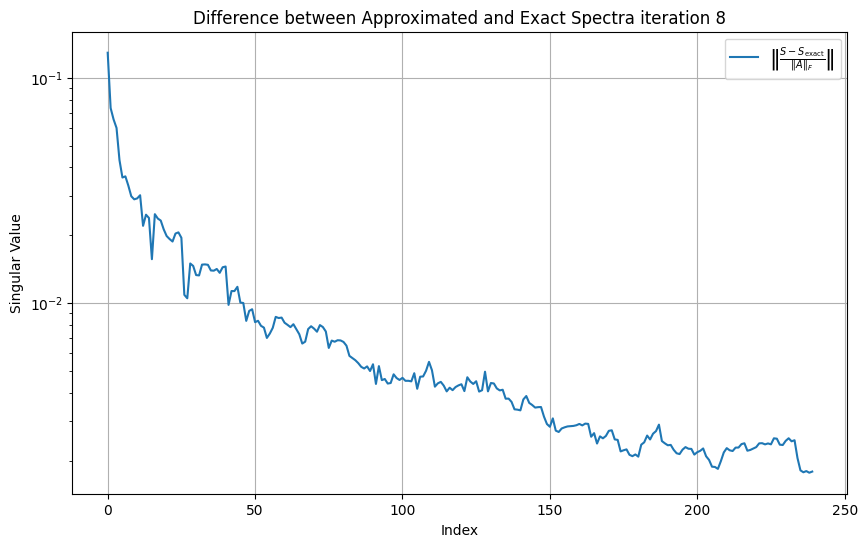

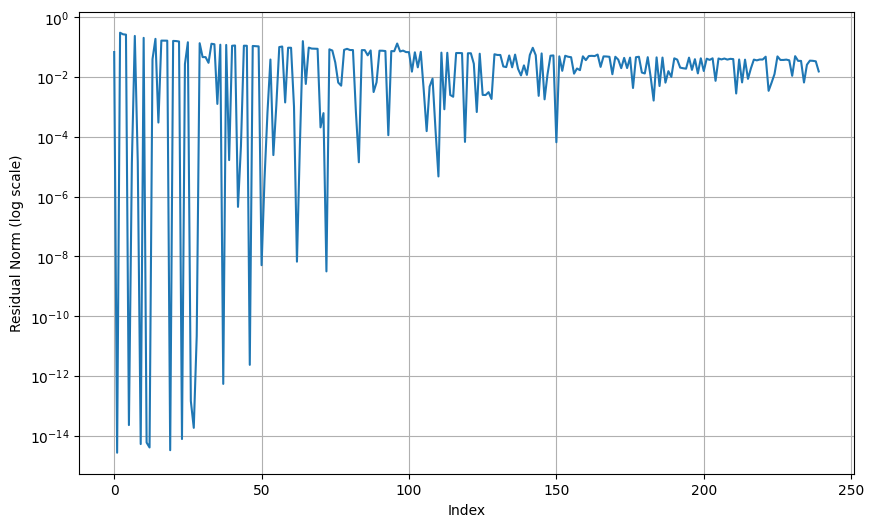

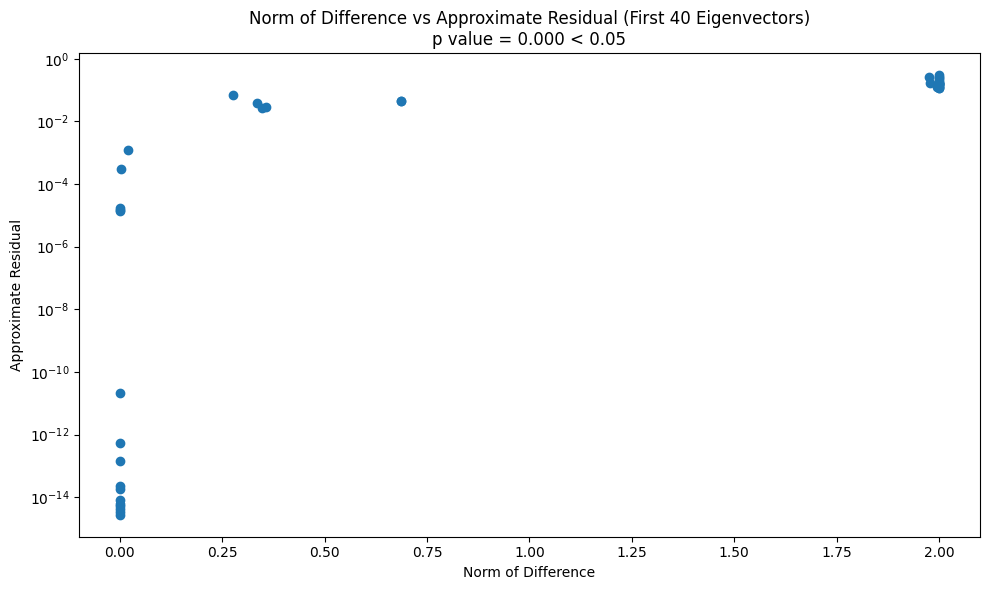

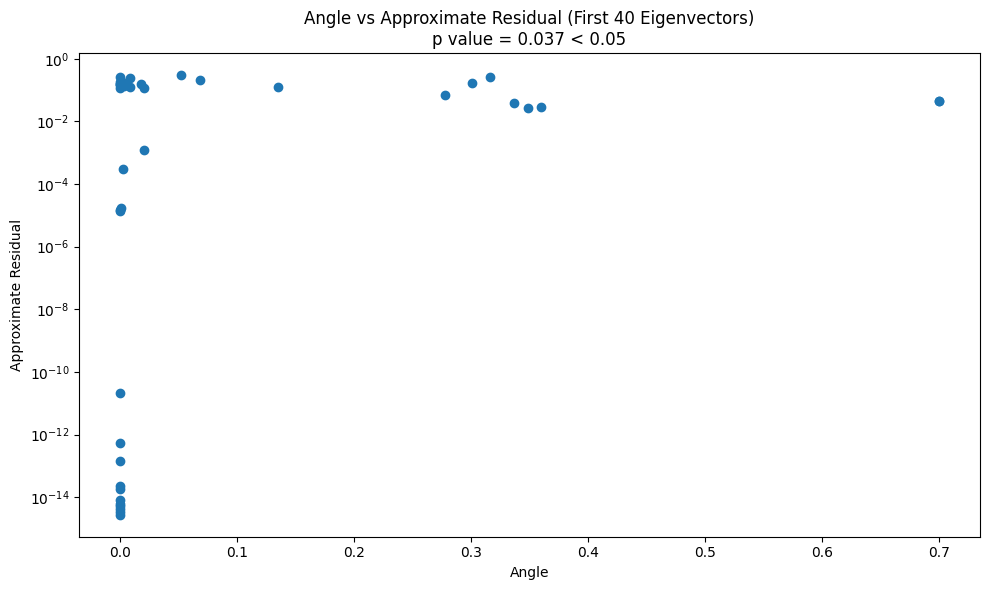

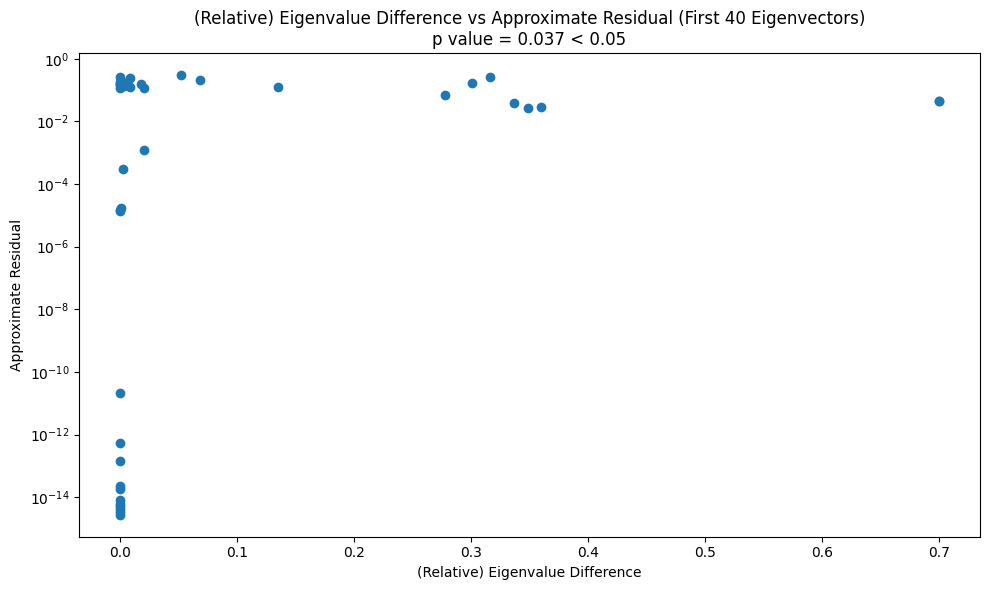

Subspace angle 2: 1.5707963267944516 0.16311383160310006


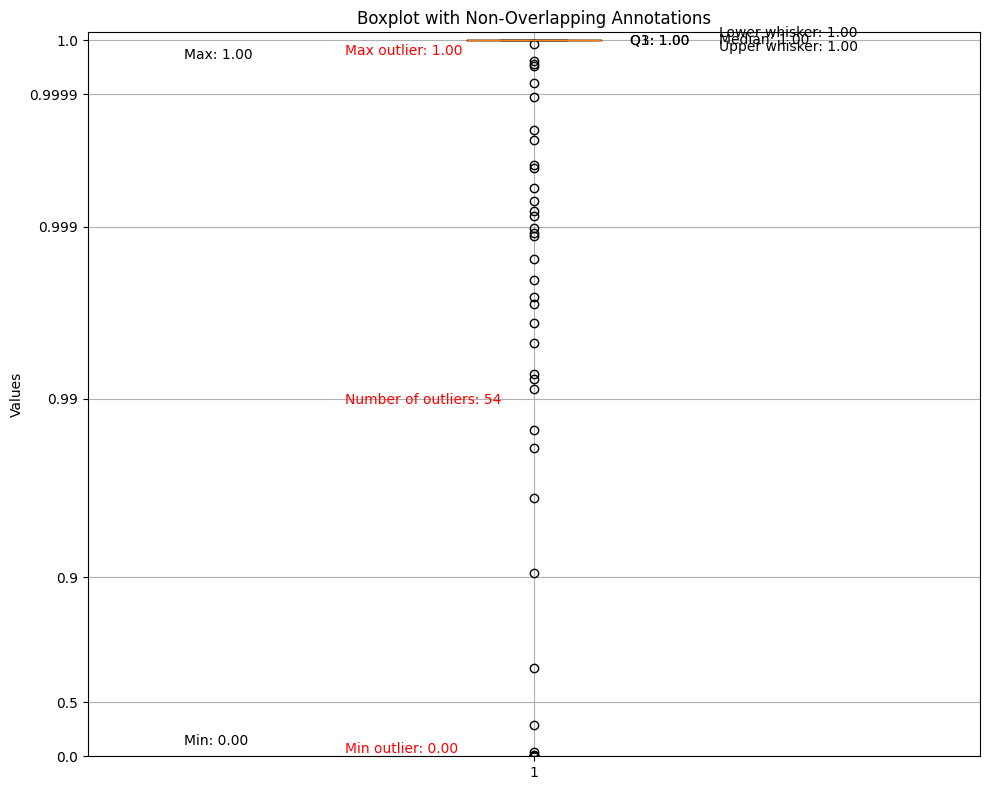

Reconstruction quality: 21.913632213710375
Relative error in S: 0.22985674367069855
Window: 10
Index: 2410 2410
481


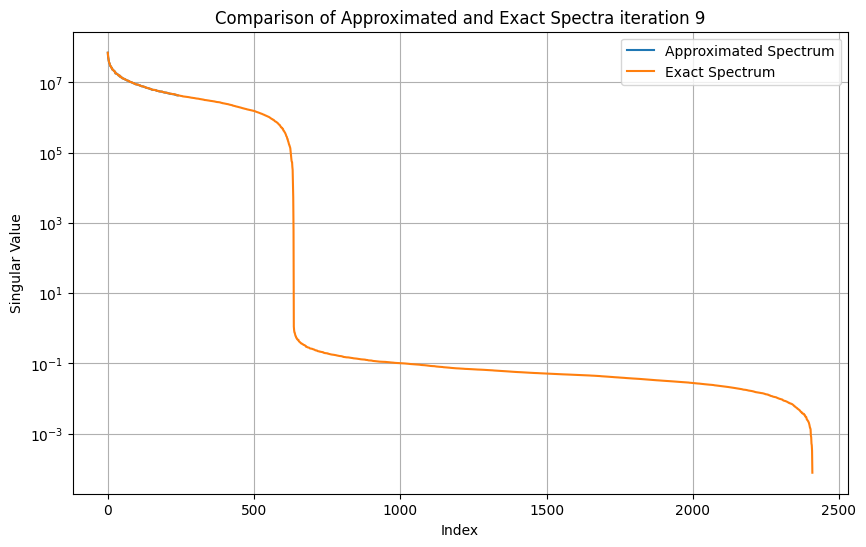

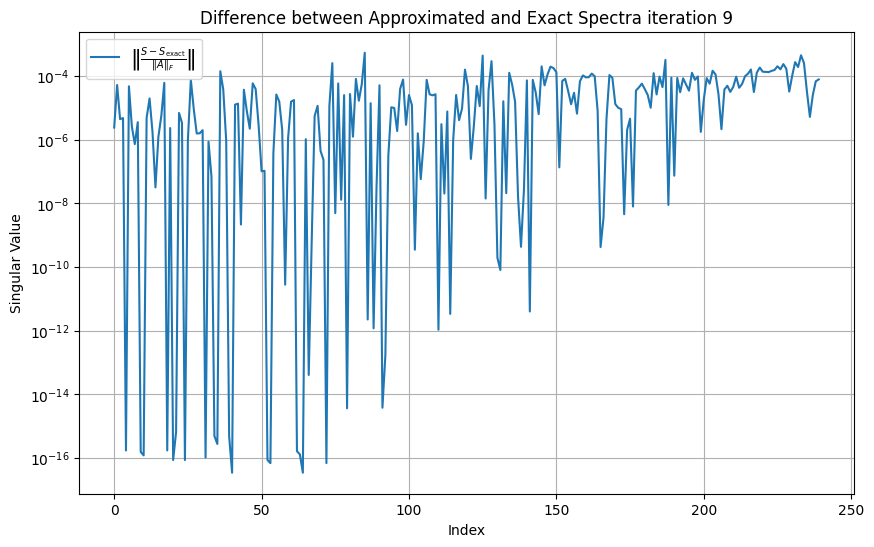

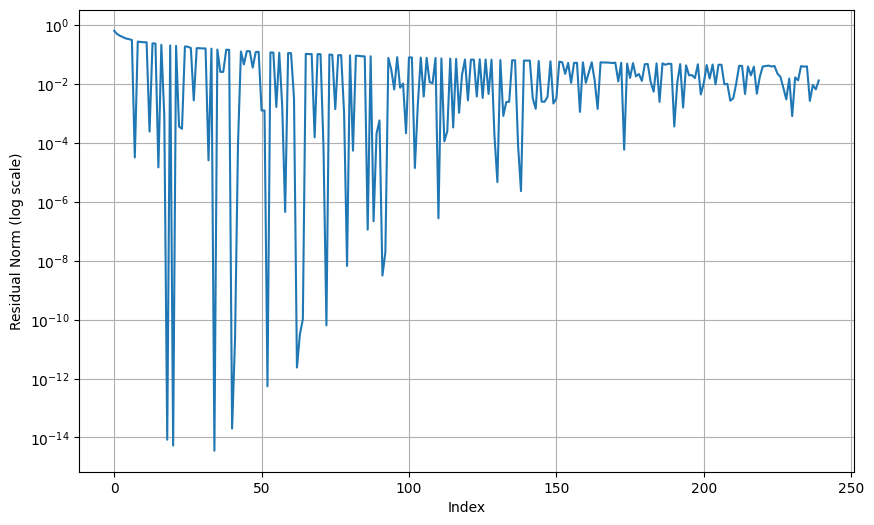

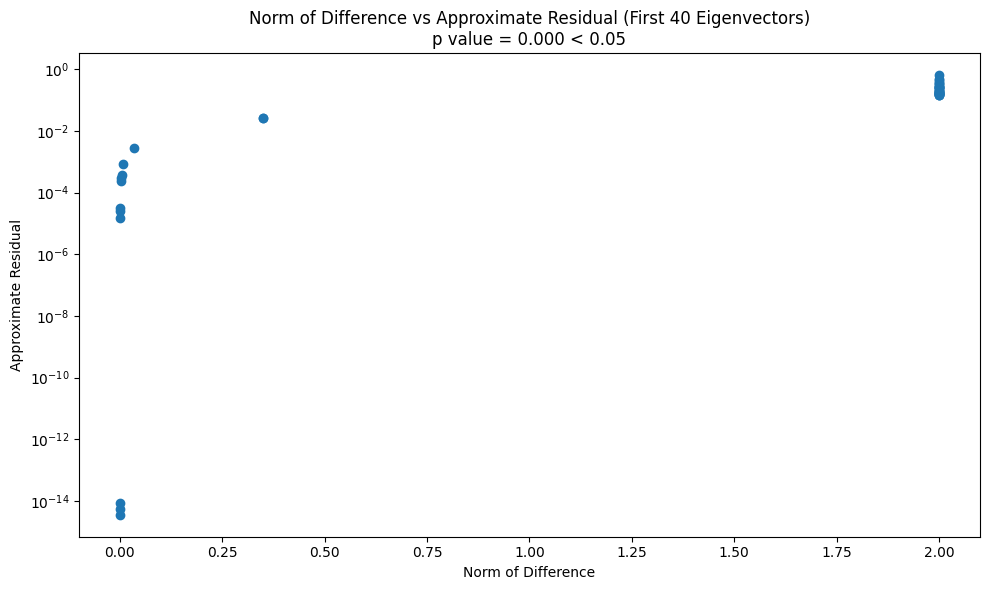

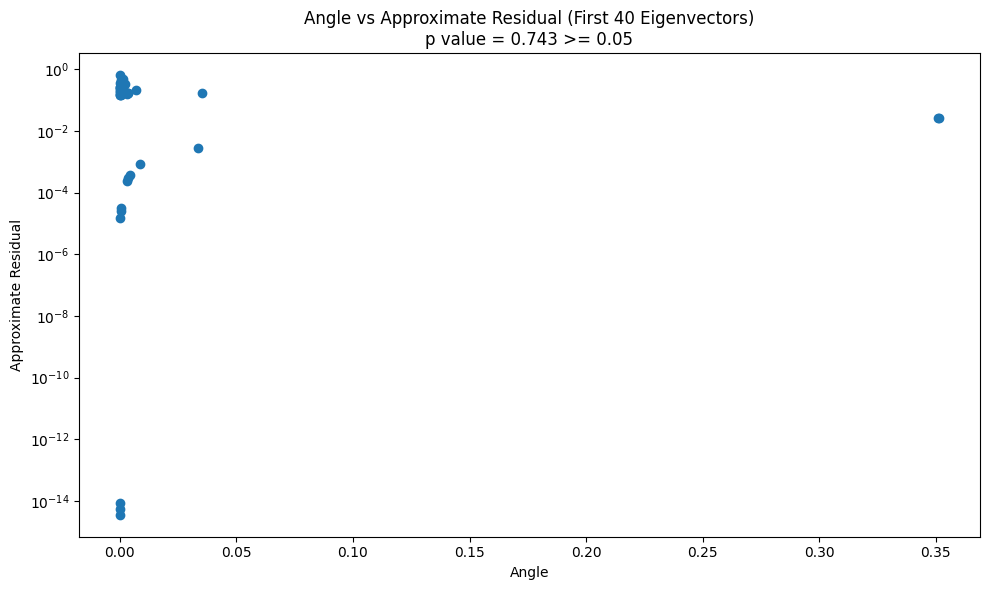

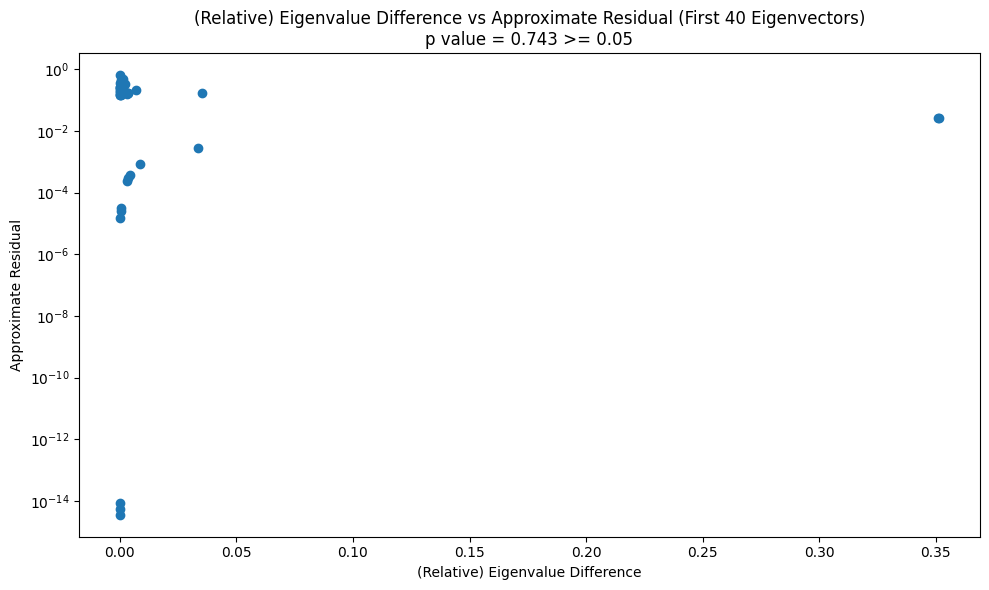

Subspace angle 2: 1.357130759312682 0.0193045638933978


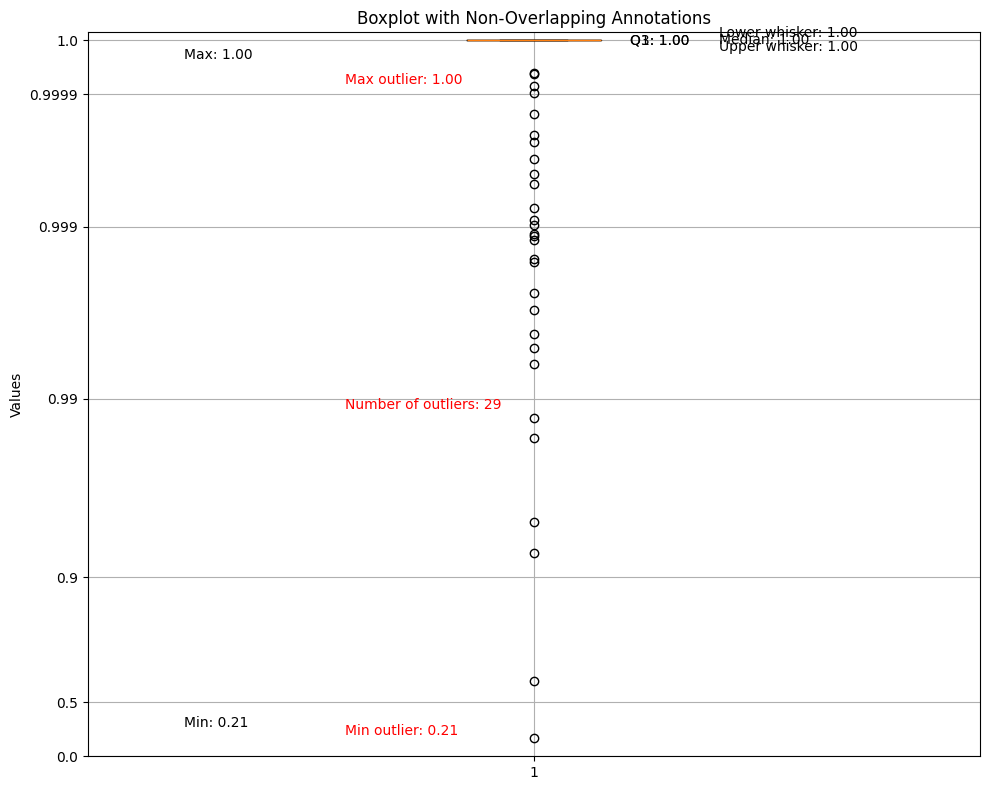

Reconstruction quality: 21.991832818245868
Relative error in S: 0.0014023438000340285


In [31]:
%matplotlib inline

# total_rows = A_csr.shape[0]
# A_squared = A_csr.copy()
# A_squared.data **= 2
# weights = np.asarray(np.sum(A_squared, axis=1)).reshape(-1)
# row_permutation = np.argsort(weights)[::-1]

# row_permutation = np.random.permutation(total_rows)

# weights = np.asarray(np.sqrt(np.sum(A_squared, axis=1))).reshape(-1)
# sequence = np.arange(len(weights))
# weights = np.array(weights) / np.sum(weights)  # Normalize weights
# permutation = np.random.choice(len(sequence), size=len(sequence), replace=False, p=weights)
# row_permutation = np.array(sequence)[permutation]

# row_permutation = np.argsort(np.sum(Vt_exact**2, axis=0)).reshape(-1)[::-1]

row_permutation = np.arange(A_csr.shape[0])#[::-1] 

figure_dir = "figures"
matrix_postfix = matrix_name.split('/')[-1]
S, Vt = isvd(A_csr, 
             S_exact, Vt_exact, U_exact,
             row_permutation=row_permutation, 
             name='temp',
             figure_dir=figure_dir)
# isvd(A_csr)

In [10]:
# perturbation_scale = 0.1

# # Generate a random perturbation matrix
# perturbation = np.random.randn(*Vt_exact.shape) * perturbation_scale

# # Add perturbation to Vt_exact
# Vt = Vt_exact + perturbation

In [6]:
Vt.shape, Vt_exact.shape

((240, 2410), (2410, 2410))

Subspace angle 2: 1.357130759312682 0.0193045638933978


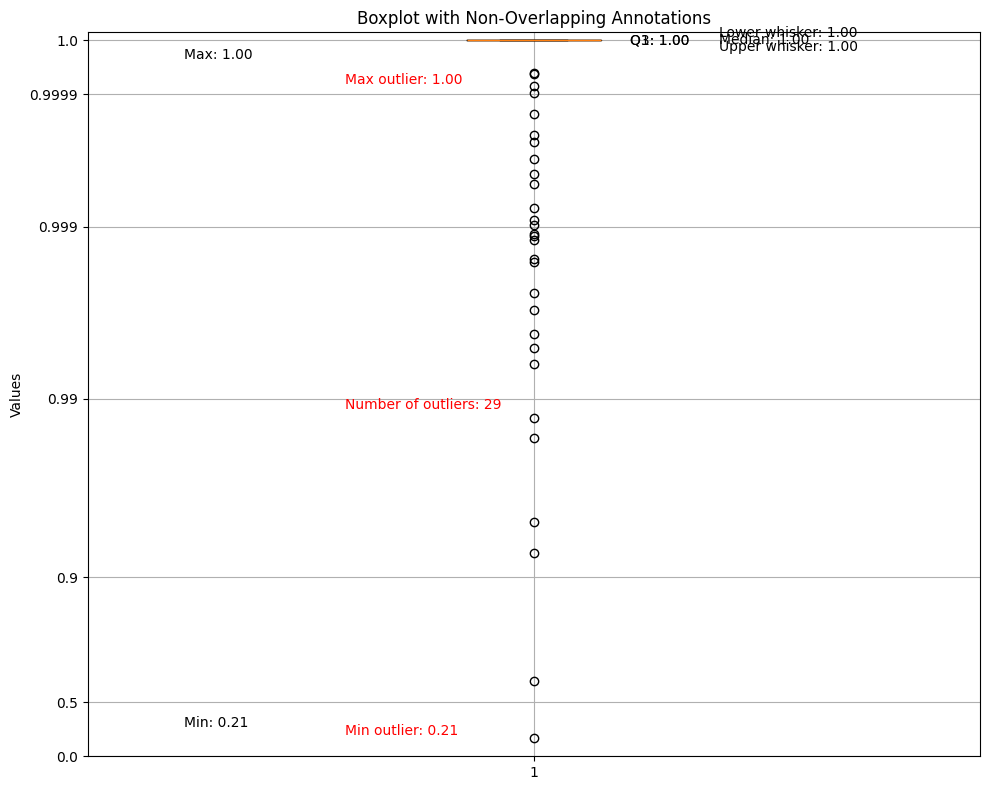

In [28]:
# Vt = Vt[]

# Compute the singular values of Q1.T @ Q2
s = np.linalg.svd(Vt @ Vt_exact[:Vt.shape[0], :].T, compute_uv=False)

# Compute the angles in radians
eps = 1e-6
assert np.all(s > -1.0 - eps) and np.all(s < 1.0 + eps), "Invalid canonical correlation found" 
angles = np.arccos(np.clip(s, -1.0, 1.0))
print("Subspace angle 2:", max(angles), np.mean(angles))

epsilon = 1e-4
s = -np.log(np.maximum(1 - s, epsilon))
# print(s)
# Create the boxplot
fig, ax = plt.subplots(figsize=(10, 8))
bp = ax.boxplot(s, whis=1.5)

# Extract positions
whiskers = [item.get_ydata()[1] for item in bp['whiskers']]
caps = [item.get_ydata()[0] for item in bp['caps']]
boxes = [item.get_ydata() for item in bp['boxes']][0]
medians = [item.get_ydata()[0] for item in bp['medians']]
fliers = bp['fliers'][0].get_ydata()

# Calculate statistics
min_val, max_val = np.min(s), np.max(s)
q1, median_val, q3 = np.percentile(s, [25, 50, 75])
lower_whisker, upper_whisker = whiskers[0], whiskers[1]

# Function to add annotation with offset
def add_annotation(x, y, text, offset=0, color='black', ha='left', va='center'):
    ax.annotate(text, (x, y), xytext=(offset, 0), textcoords='offset points',
                ha=ha, va=va, color=color)

def inverse_transform(s):
    return 1 - np.exp(-s)

# Add annotations with adjusted positions
add_annotation(0.6, min_val+0.1, f'Min: {inverse_transform(min_val):.2f}', offset=5, va='bottom')
add_annotation(0.6, max_val-0.1, f'Max: {inverse_transform(max_val):.2f}', offset=5, va='top')
add_annotation(1.1, q1, f'Q1: {inverse_transform(q1):.2f}', offset=5)
add_annotation(1.1+0.1, median_val, f'Median: {inverse_transform(median_val):.2f}', offset=5)
add_annotation(1.1, q3, f'Q3: {inverse_transform(q3):.2f}', offset=5)
add_annotation(1.1+0.1, lower_whisker, f'Lower whisker: {inverse_transform(lower_whisker):.2f}', offset=5, va='bottom')
add_annotation(1.1+0.1, upper_whisker, f'Upper whisker: {inverse_transform(upper_whisker):.2f}', offset=5, va='top')

# Add outlier information
if len(fliers) > 0:
    outlier_min, outlier_max = np.min(fliers), np.max(fliers)
    add_annotation(0.78, outlier_min, f'Min outlier: {inverse_transform(outlier_min):.2f}', offset=5, va='bottom', color='red')
    add_annotation(0.78, outlier_max, f'Max outlier: {inverse_transform(outlier_max):.2f}', offset=5, va='top', color='red')
    add_annotation(0.78, (outlier_min+outlier_max)/2, f'Number of outliers: {len(fliers)}', offset=5, va='center', color='red')

# Customize the plot
ax.set_title('Boxplot with Non-Overlapping Annotations')
ax.set_ylabel('Values')
ax.set_xlim(0.5, 1.5)  # Adjust x-axis limits to make room for annotations
ax.set_ylim(0, -np.log(epsilon)+0.1)

y_ticks = np.array([0, 0.5, 0.9, 0.99, 0.999, 0.9999, 1])
ax.set_yticks(-np.log(1 - y_ticks + epsilon))
ax.set_yticklabels([f"{y}" for y in y_ticks])

plt.grid()
plt.tight_layout()
# plt.savefig(dir_path + f'/angles_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
plt.show()
# plt.close('all')

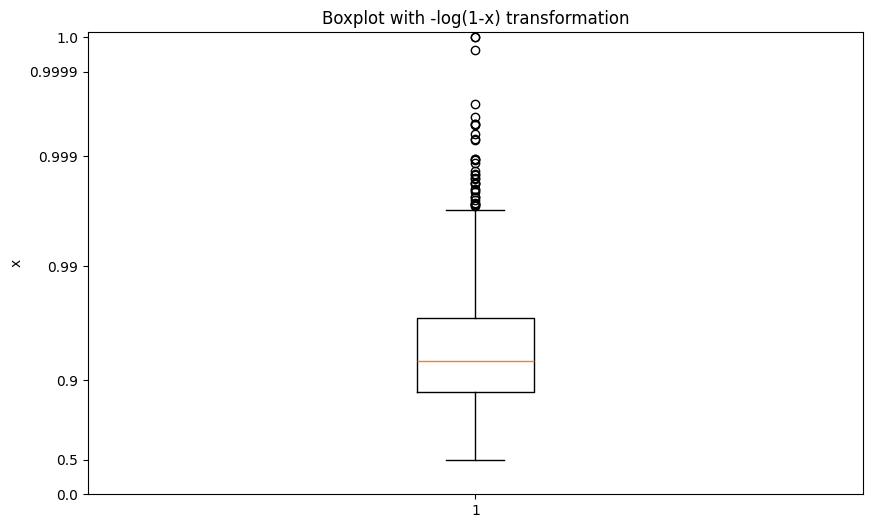

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
data = np.concatenate([
    1 - np.random.beta(1, 10, 999),  # Beta distribution to get values close to 1
    [1]  # Add exactly 1 to the dataset
])

# Apply the transformation -log(1-x) to invert the axis
# Use a small epsilon to avoid log(0)
epsilon = 1e-4
transformed_data = -np.log(np.maximum(1 - data, epsilon))

# Create the boxplot
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(transformed_data)

# Set y-axis limits
ax.set_ylim(0, -np.log(epsilon)+0.1)
# print(-np.log(epsilon))

# Create custom y-ticks
y_ticks = np.array([0, 0.5, 0.9, 0.99, 0.999, 0.9999, 1])
ax.set_yticks(-np.log(1 - y_ticks + epsilon))
ax.set_yticklabels([f"{y}" for y in y_ticks])

# Labels and title
ax.set_ylabel('x')
plt.title('Boxplot with -log(1-x) transformation')

plt.show()

Window: 1
Index: 241 2410


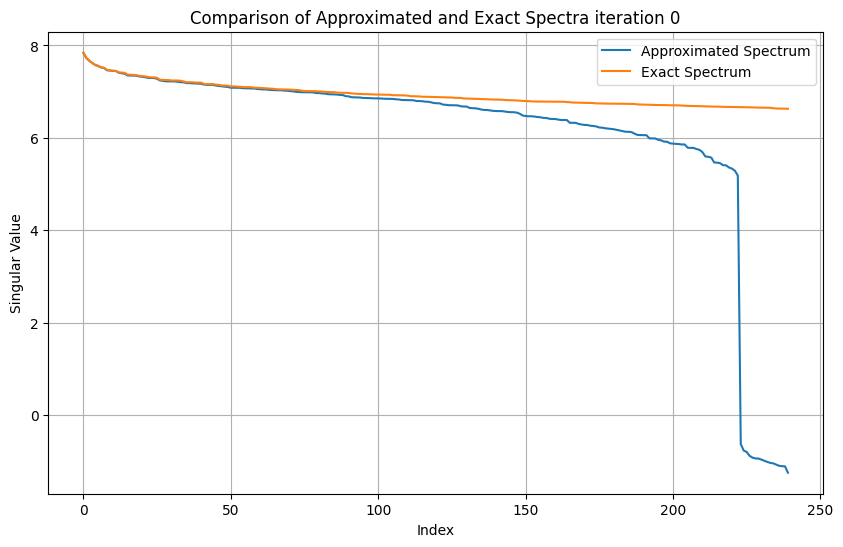

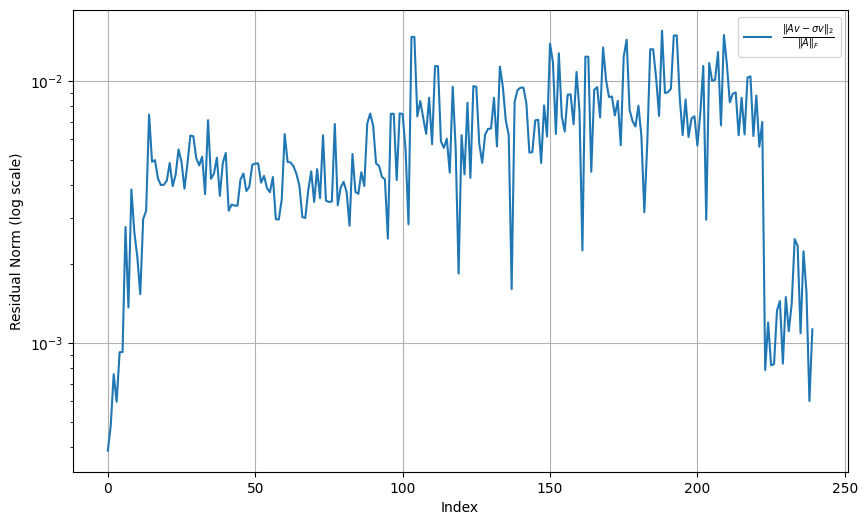

Reconstruction quality: 22.12842713162639
Reconstruct Vt from Vt_exact: 9.3813807765618
Subspace angle: 2.8360529352878986e-15
Subspace angle 2: 1.5707963267948963 0.5895635534021774
Canonical correlation [1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 9.99999999e-01 9.99999999e-01
 9.99999996e-01 9.99999993e-01 9.99999984e-01 9.99999980e-01
 9.99999974e-01 9.99999921e-01 9.99999850e-01 9.99999845e-01
 9.99999833e-01 9.99999725e-01 9.99999342e-01 9.99999252e-01
 9.99999140e-01 9.99998507e-01 9.99998427e-01 9.99997133e-01
 9.99996804e-01 9.99996448e-01 9.99995835e-01 9.99995567e-01
 9.99995013e-01 9.99994024e-01 9.99993750e-01 9.99993269e-01
 9.99992499e-01 9.99991412e-01 9.99989580e-01 9.99989318e-01
 9.99987512e-01 9.99987310e-01 9.99986249e-01 9.99985535e-01
 9.99985023e-01 9.99981859e-01 9.99976811e-01 9.99976740e-01
 9

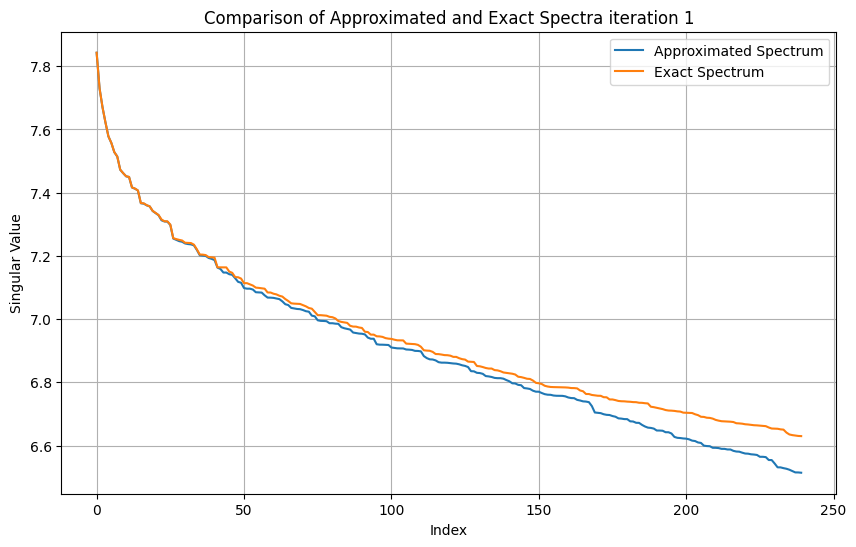

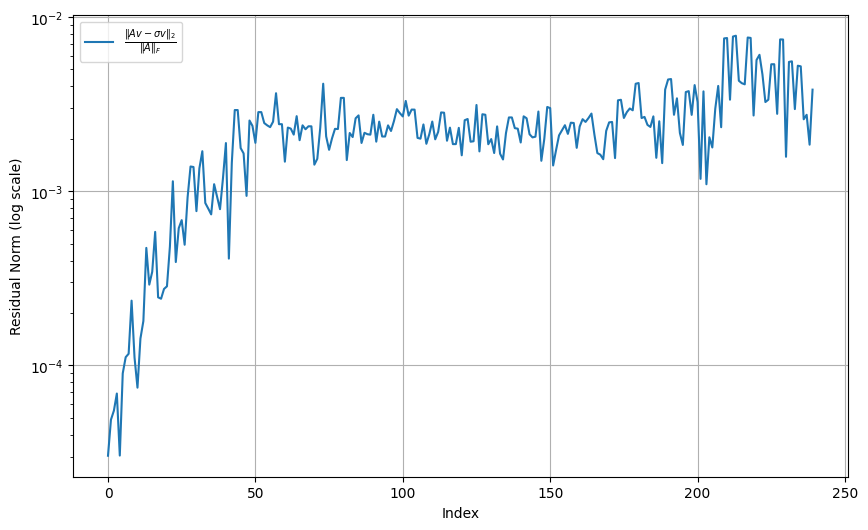

Reconstruction quality: 22.04975612194495
Reconstruct Vt from Vt_exact: 4.085557615291373
Subspace angle: 2.9001660320922976e-15
Subspace angle 2: 1.5707834057170957 0.14938695935327354
Canonical correlation [1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999999e-01 9.99999998e-01
 9.99999998e-01 9.99999998e-01 9.99999997e-01 9.99999996e-01
 9.99999996e-01 9.99999995e-01 9.99999994e-01 9.99999994e-01
 9.99999993e-01 9.99999989e-01 9.99999988e-01 9.99999988e-01
 9.99999985e-01 9.99999981e-01 9.99999979e-01 9.99999978e-01
 9.99999971e-01 9.99999965e-01 9.99999962e-01 9.99999949e-01
 9.99999940e-01 9.99999938e-01 9.99999908e-01 9.99999874e-01
 9.99999849e-01 9.99999818e-01 9.99999801e-01 9.99999783e-01
 9.99999617e-01 9.99999569e-01 9.99999517e-01 9.99999492e-01
 9.99999347e-01 9.99999193e-01 9.99998785e-01 9.99998684e-01
 9.99998478e-01 9.99998296e-01 9.99998176e-01 9.99998161e-01

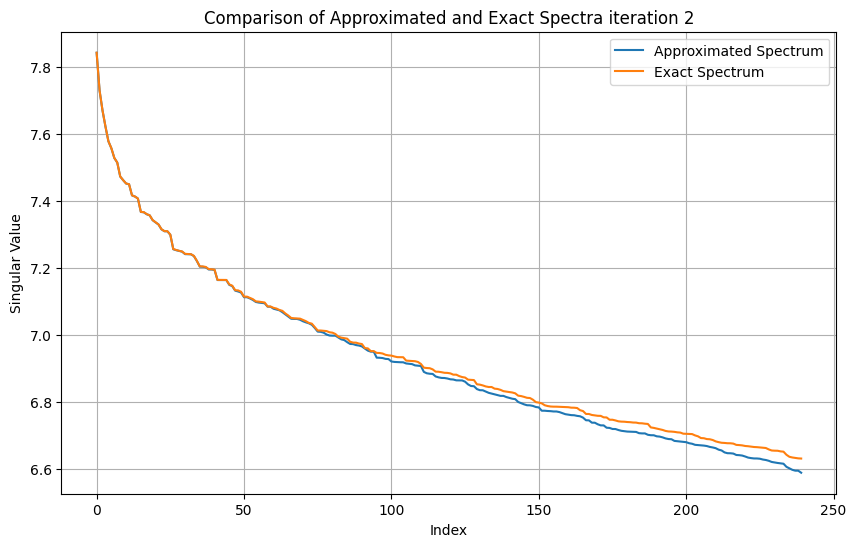

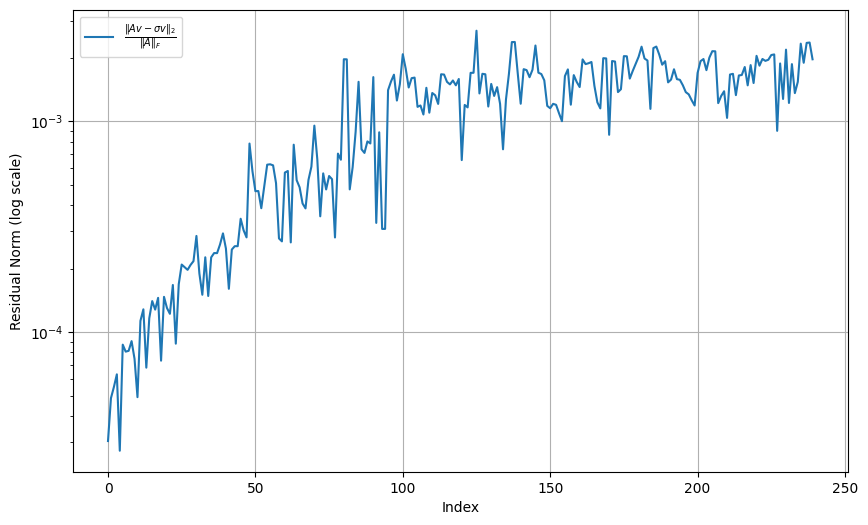

Reconstruction quality: 22.80314786226133
Reconstruct Vt from Vt_exact: 2.0599344067183876
Subspace angle: 2.8244223832842727e-15
Subspace angle 2: 1.5628055593785453 0.05623157873065692
Canonical correlation [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         0.99999999
 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999
 0.99999999 0.99999999 0.99999999 0.99999998 0.99999998 0.99999998
 0.99999998 0.99999997 0.99999997 0.99999996 0.99999996 0.99999995
 0.99999995 0.99999995 0.99999994 0.99999994 0.99999992 0.99999992
 0.99999992 0.99999991 0.99999991 0.9999999  0.99999989 0.99999988
 0.99999986 0.99999984 0.99999982 0.99999978 0.99999976 0.99999972
 0.99999971 0.9999997  0.99999967 0.99999961 0.99999955 0.99999952
 0.99999951 0.99999949 0.99999946 0.99999945 0.9999994  0.99999922
 0.99999911 0.99999908 0.99999906 0.9999989  0.99999885 0.99999875
 0.

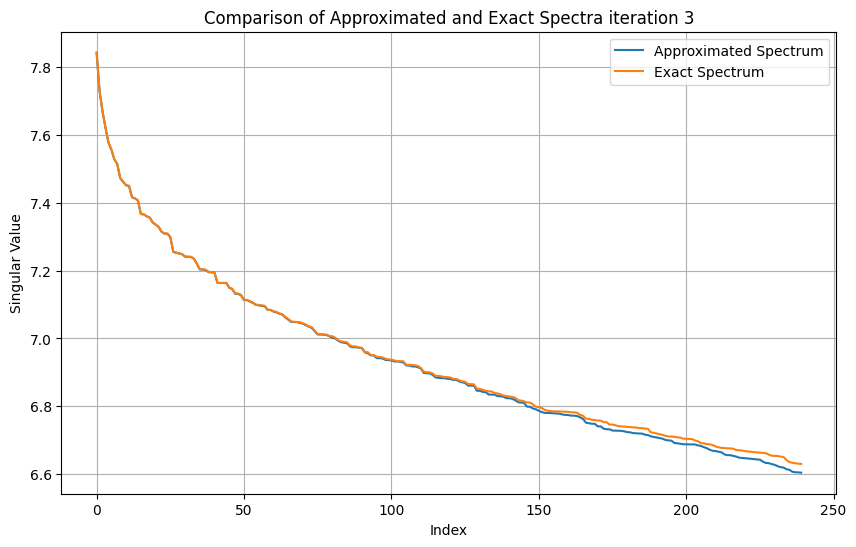

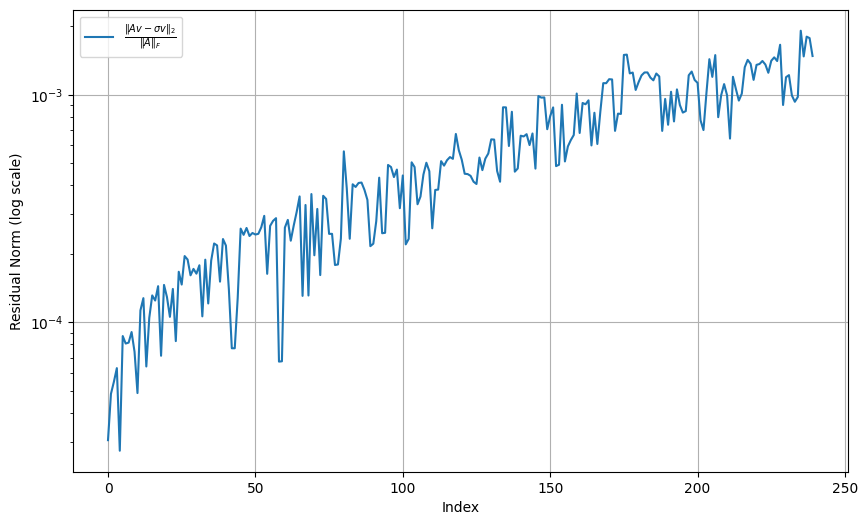

Reconstruction quality: 22.034271519296723
Reconstruct Vt from Vt_exact: 1.9977955052081064
Subspace angle: 2.7950273606151558e-15
Subspace angle 2: 1.5626909136293146 0.049160243323350235
Canonical correlation [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         0.99999999 0.99999999 0.99999999 0.99999999 0.99999999
 0.99999999 0.99999999 0.99999999 0.99999999 0.99999998 0.99999998
 0.99999997 0.99999997 0.99999996 0.99999996 0.99999995 0.99999995
 0.99999994 0.99999994 0.99999993 0.99999992 0.99999992 0.99999991
 0.9999999  0.99999989 0.99999989 0.99999986 0.99999986 0.99999985
 0.99999983 0.99999979 0.99999977 0.99999977 0.99999974 0.99999971
 0.99999969 0.99999964 0.99999961 0.9999996  0.99999957 0.99999951
 0.99999945 0.99999939 0.99999936 0.99999921 0.99999889 0.99999884
 0.99999879 0.99999872 0.99999861 0.99999854 0.99999847 0.99999844
 0.999998

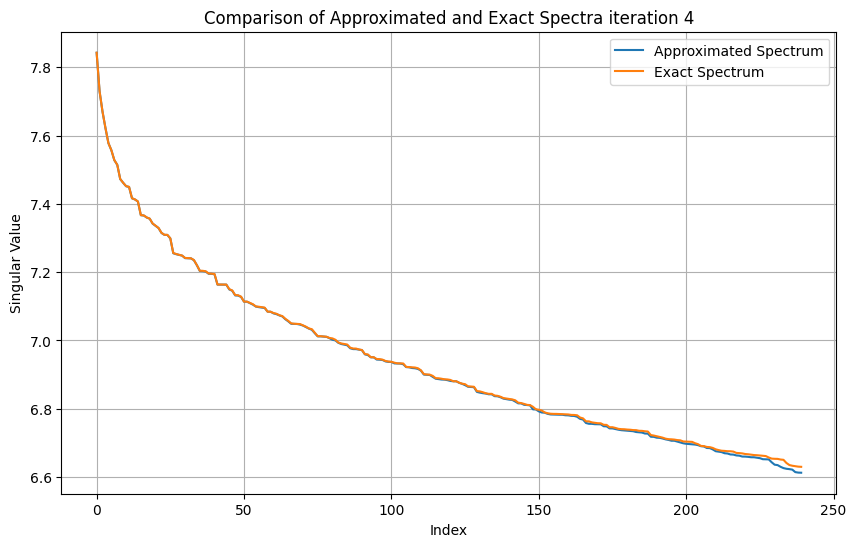

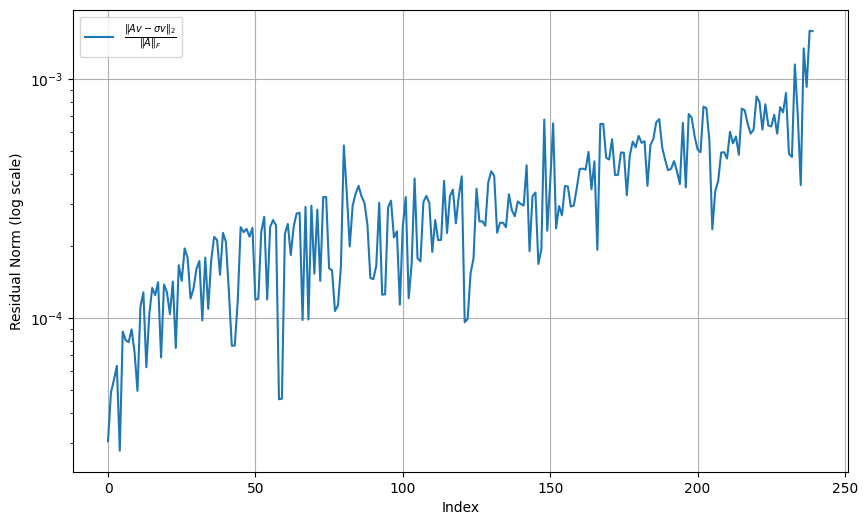

Reconstruction quality: 22.835780765479708
Reconstruct Vt from Vt_exact: 1.9243129728900643
Subspace angle: 2.877309699836288e-15
Subspace angle 2: 1.5626487428858569 0.04193009854819495
Canonical correlation [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         0.99999999 0.99999999 0.99999999 0.99999999 0.99999999
 0.99999999 0.99999999 0.99999998 0.99999998 0.99999998 0.99999998
 0.99999998 0.99999998 0.99999997 0.99999997 0.99999997 0.99999997
 0.99999996 0.99999996 0.99999996 0.99999996 0.99999995 0.99999994
 0.99999994 0.99999993 0.99999993 0.99999992 0.9999999  0.9999999
 0.99999988 0.99999987 0.99999985 0.99999984 0.99999983 0.99999982
 0.99999981 0.99999977 0.99999973 0.99999972 0.9999997  0.99999966
 0.99999964 0.99999959 0.99999955 0.99999955 0.99999949 0.99999947
 0.99999941 0.999999

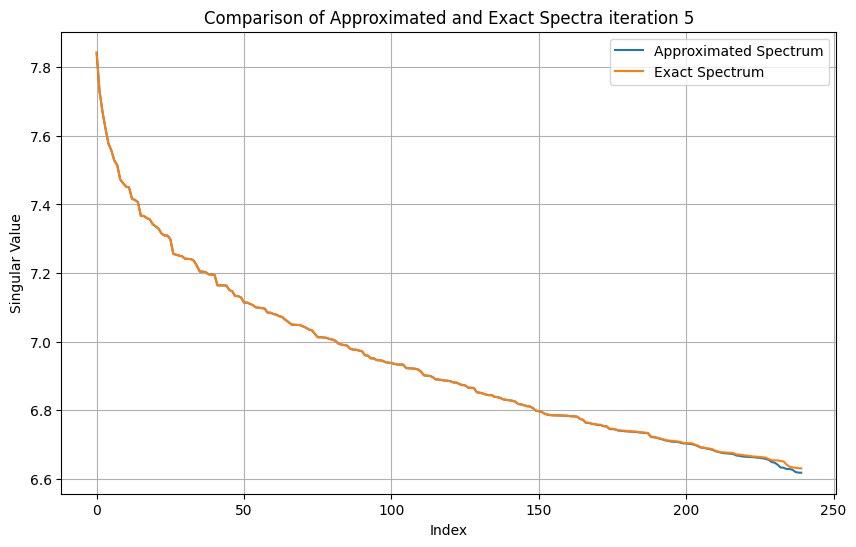

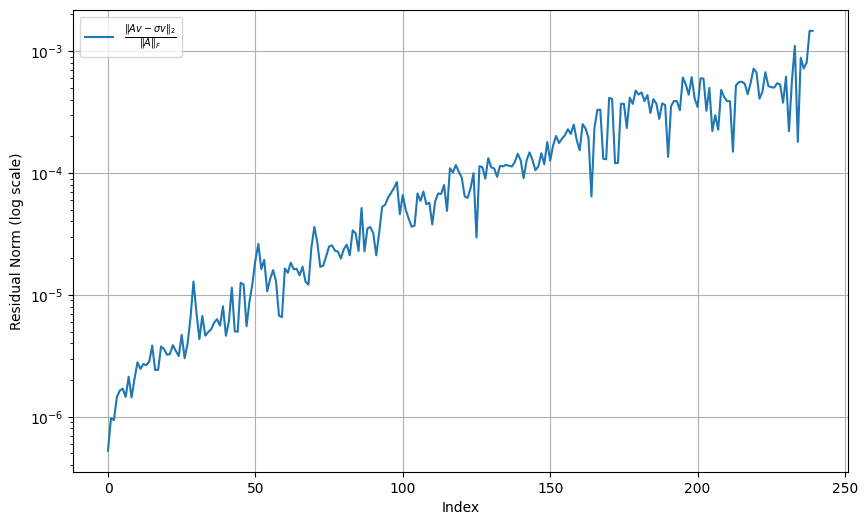

Reconstruction quality: 21.72156521472184
Reconstruct Vt from Vt_exact: 1.9121588586144254
Subspace angle: 2.842239003798859e-15
Subspace angle 2: 1.5626608565354263 0.0390370103609194
Canonical correlation [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         0.99999999 0.99999999
 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999
 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999
 0.99999998 0.99999998 0.99999998 0.99999998 0.99999998 0.999

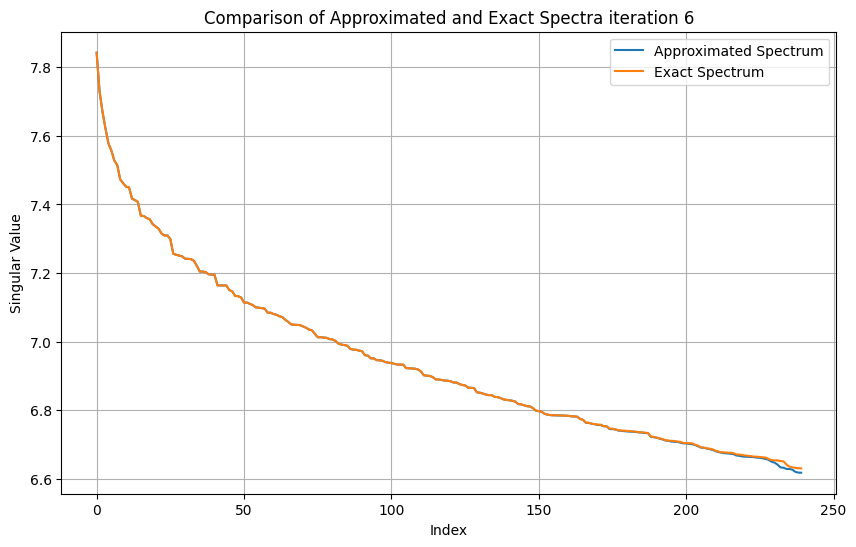

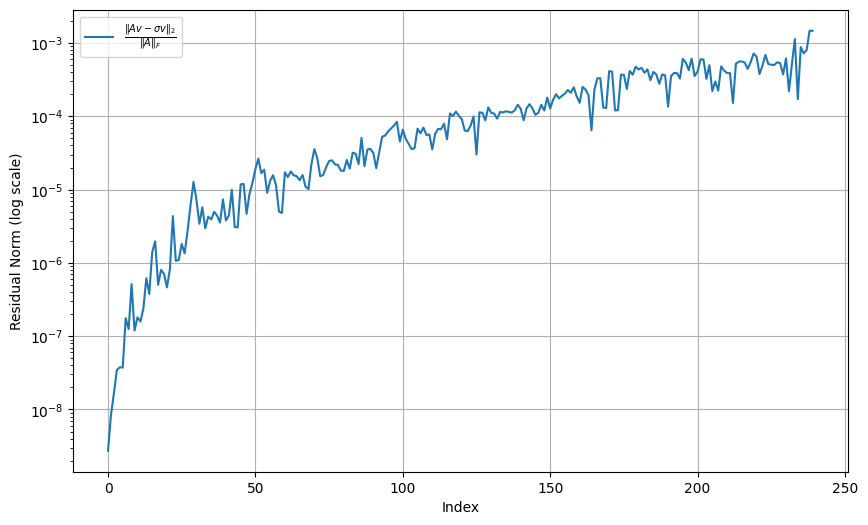

Reconstruction quality: 21.52205342859733
Reconstruct Vt from Vt_exact: 1.9121618945808776
Subspace angle: 2.798542912870965e-15
Subspace angle 2: 1.5626605265043825 0.03901734964610519
Canonical correlation [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         0.99999999 0.99999999 0.99999999 0.99999999
 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999
 0.999999

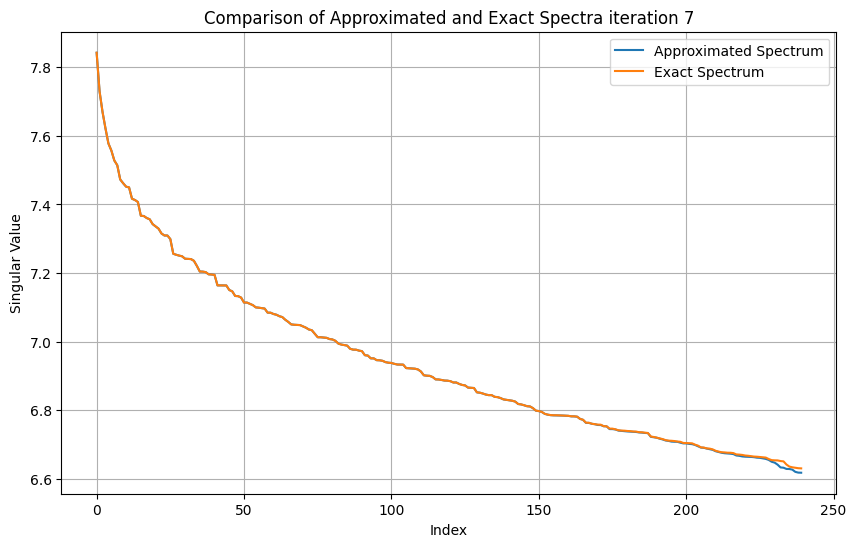

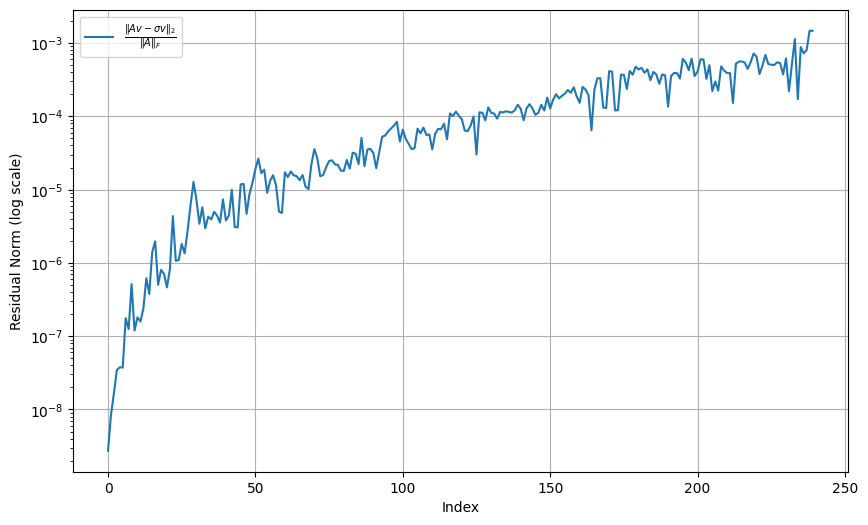

Reconstruction quality: 22.178413048788546
Reconstruct Vt from Vt_exact: 1.912161894580878
Subspace angle: 2.8771943911790794e-15
Subspace angle 2: 1.5626605265043825 0.0390173495133274
Canonical correlation [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         0.99999999 0.99999999 0.99999999 0.99999999
 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999
 0.999999

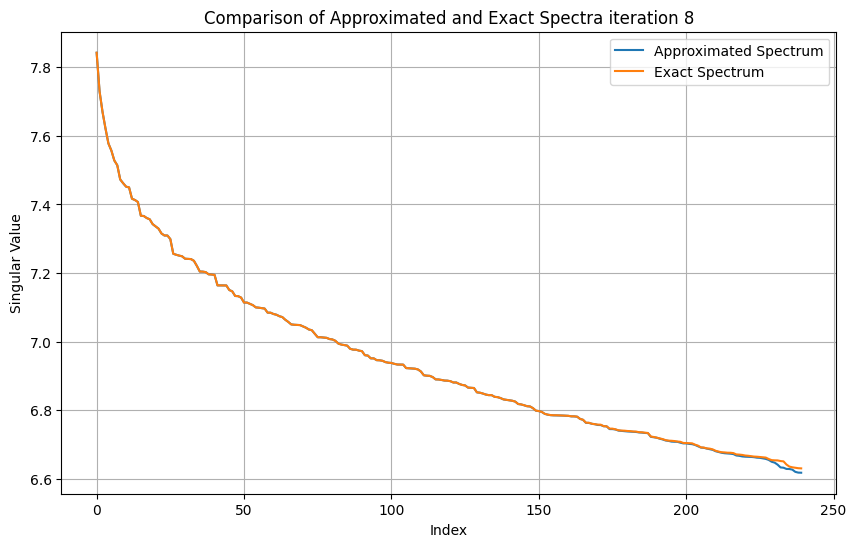

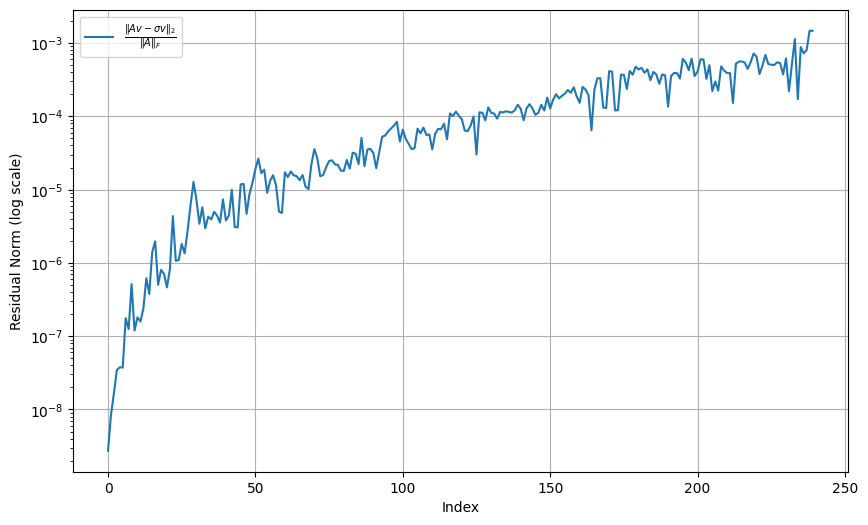

Reconstruction quality: 21.327968197720423
Reconstruct Vt from Vt_exact: 1.9121618945808787
Subspace angle: 2.912954407205185e-15
Subspace angle 2: 1.5626605265043825 0.03901734938302204
Canonical correlation [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         0.99999999 0.99999999 0.99999999 0.99999999
 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999
 0.99999

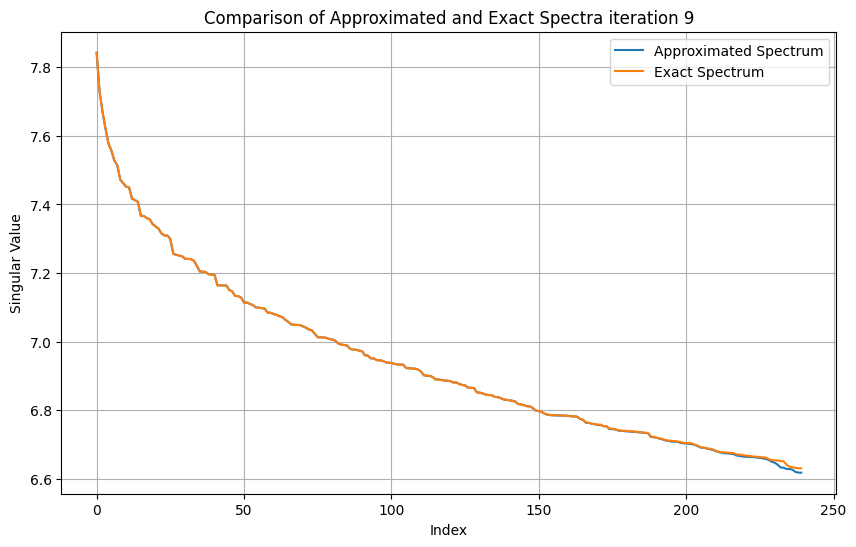

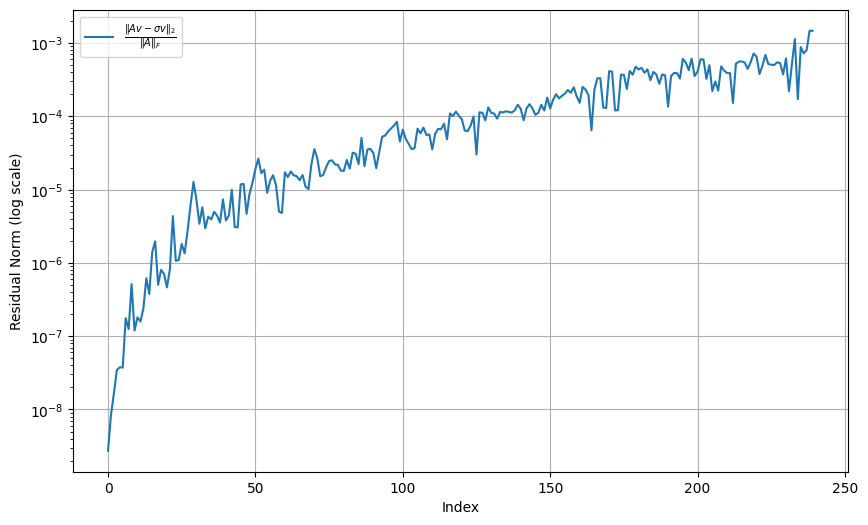

Reconstruction quality: 21.87550497332786
Reconstruct Vt from Vt_exact: 1.9121618945808778
Subspace angle: 2.845414765587193e-15
Subspace angle 2: 1.5626605265043825 0.03901734892208056
Canonical correlation [1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         0.99999999 0.99999999 0.99999999 0.99999999
 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999 0.99999999
 0.999999

In [16]:


# # total_rows = A_csr.shape[0]
# A_squared = A_csr.copy()
# A_squared.data **= 2
# weights = np.asarray(np.sum(A_squared, axis=1)).reshape(-1)
# row_permutation = np.argsort(weights)[::-1]

# # row_permutation = np.random.permutation(total_rows)

# # weights = np.asarray(np.sqrt(np.sum(A_squared, axis=1))).reshape(-1)
# # sequence = np.arange(len(weights))
# # weights = np.array(weights) / np.sum(weights)  # Normalize weights
# # permutation = np.random.choice(len(sequence), size=len(sequence), replace=False, p=weights)
# # row_permutation = np.array(sequence)[permutation]

# # row_permutation = np.argsort(np.sum(Vt_exact**2, axis=0)).reshape(-1)[::-1]

# # row_permutation = np.arange(A_csr.shape[0])#[::-1]


# matrix_postfix = matrix_name.split('/')[-1]
# S, Vt = isvd(A_csr, row_permutation=row_permutation, name=matrix_postfix+"_sorted_weights")
# # isvd(A_csr)

In [367]:
def analyze_matrix(matrix, name):
    u, s, vt = svd(matrix)
    rank = np.sum(s > 1e-10)  # Consider values above 1e-10 as non-zero
    print(f"{name} shape: {matrix.shape}")
    print(f"{name} rank: {rank}")
    print(f"{name} singular values: {s}")
    print(f"Number of singular values > 1e-10: {rank}")
    print()

analyze_matrix(Vt[:,:5], "Vt[:,:5]")
analyze_matrix(Vt_exact[:Vt.shape[0],:5], "Vt_exact[:Vt.shape[0],:5]")

analyze_matrix(Vt[:,:10], "Vt[:,:10]")
analyze_matrix(Vt_exact[:Vt.shape[0],:10], "Vt_exact[:Vt.shape[0],:10]")

analyze_matrix(Vt[:,:20], "Vt[:,:20]")
analyze_matrix(Vt_exact[:Vt.shape[0],:20], "Vt_exact[:Vt.shape[0],:20]")

analyze_matrix(Vt, "Vt")
analyze_matrix(Vt_exact[:Vt.shape[0],:], "Vt_exact[:Vt.shape[0],:]")

Vt[:,:5] shape: (10, 5)
Vt[:,:5] rank: 4
Vt[:,:5] singular values: [5.35401294e-01 3.02415172e-02 9.96364375e-04 7.89531464e-05
 1.03858412e-16]
Number of singular values > 1e-10: 4

Vt_exact[:Vt.shape[0],:5] shape: (10, 5)
Vt_exact[:Vt.shape[0],:5] rank: 2
Vt_exact[:Vt.shape[0],:5] singular values: [9.24832266e-04 1.29691065e-05 1.20962920e-16 8.62902275e-17
 7.84276036e-18]
Number of singular values > 1e-10: 2

Vt[:,:10] shape: (10, 10)
Vt[:,:10] rank: 7
Vt[:,:10] singular values: [8.99392854e-01 3.93001316e-01 1.57542382e-02 2.46428714e-03
 2.35360731e-03 2.91402146e-04 1.81488511e-05 3.44822491e-13
 3.40598922e-14 4.69022717e-17]
Number of singular values > 1e-10: 7

Vt_exact[:Vt.shape[0],:10] shape: (10, 10)
Vt_exact[:Vt.shape[0],:10] rank: 2
Vt_exact[:Vt.shape[0],:10] singular values: [1.54886217e-02 4.13952211e-04 2.56010819e-16 1.27806416e-16
 1.07630983e-16 8.26843594e-17 4.79041324e-17 1.82458467e-17
 5.36307916e-18 4.19074557e-20]
Number of singular values > 1e-10: 2

Vt[:,:

In [369]:
import numpy as np
from scipy import linalg

def generate_orthogonal_vectors(Vt, num_vectors=1, tol=1e-10):
    """
    Generate random vectors orthogonal to the space spanned by the rows of Vt.
    
    Parameters:
    Vt (numpy.ndarray): Input matrix of shape (m, n)
    num_vectors (int): Number of orthogonal vectors to generate
    tol (float): Tolerance for considering singular values as zero
    
    Returns:
    numpy.ndarray: Matrix of orthogonal vectors, each column is a vector
    """
    m, n = Vt.shape
    
    # Compute the SVD of Vt.T
    U, s, Vh = linalg.svd(Vt.T, full_matrices=True)
    
    # Determine the rank of Vt
    rank = np.sum(s > tol)
    
    # The last (n-rank) columns of U form an orthonormal basis for the null space of Vt.T
    null_space_basis = U[:, rank:]
    
    # Generate random coefficients
    coefficients = np.random.randn(n - rank, num_vectors)
    
    # Combine the basis vectors with random coefficients
    orthogonal_vectors = null_space_basis @ coefficients
    
    # Normalize the vectors
    orthogonal_vectors /= np.linalg.norm(orthogonal_vectors, axis=0)
    
    return orthogonal_vectors

# Example usage:
# Assuming Vt is your 10x2410 matrix
Vt = np.random.rand(10, 2410)

# Generate 5 random orthogonal vectors
orthogonal_vecs = generate_orthogonal_vectors(Vt, num_vectors=5)

# Verify orthogonality
dot_products = Vt @ orthogonal_vecs
print("Max absolute dot product (should be close to 0):", np.abs(dot_products).max())

# Verify that generated vectors are orthogonal to each other
orthogonality_matrix = orthogonal_vecs.T @ orthogonal_vecs
print("\nOrthogonality matrix of generated vectors:")
print(orthogonality_matrix)

Max absolute dot product (should be close to 0): 2.4859641305438438e-15

Orthogonality matrix of generated vectors:
[[ 1.         -0.02344222 -0.05208438  0.03372569  0.03657689]
 [-0.02344222  1.         -0.00329474  0.05683974 -0.00480679]
 [-0.05208438 -0.00329474  1.         -0.00140082 -0.01262299]
 [ 0.03372569  0.05683974 -0.00140082  1.          0.00542541]
 [ 0.03657689 -0.00480679 -0.01262299  0.00542541  1.        ]]


In [ ]:
generate_orthogonal_vectors(Vt, num_vectors=5)

<BarContainer object of 2410 artists>

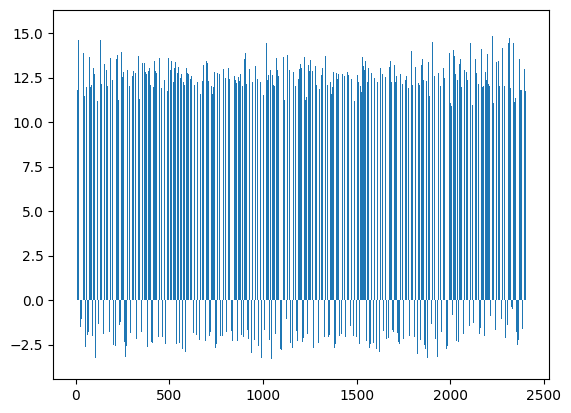

In [15]:

# plt.bar(np.arange(Vt_exact.shape[1]), np.sort(np.log10(np.sum(Vt_exact**2, axis=0)))) 
plt.bar(np.arange(len(weights)), (np.log10(weights)) )# badly scaled

####
## Randomization

####
## Synthetic data

Of long tail vs exponetially decaying

In [ ]:
# import numpy as np

# def create_synthetic_matrix(n, m, spectrum_type='linear', noise_level=0.01):
#     """
#     Create a synthetic matrix with either linearly or exponentially decaying spectrum.
    
#     Parameters:
#     n, m: Dimensions of the matrix
#     spectrum_type: 'linear' or 'exponential'
#     noise_level: Amount of noise to add
    
#     Returns:
#     A: The created matrix
#     s: The true singular values
#     """
#     r = min(n, m)  # Rank of the matrix
    
#     if spectrum_type == 'linear':
#         s = np.linspace(1, 0.1, r)  # Linear decay from 1 to 0.1
#     elif spectrum_type == 'exponential':
#         s = np.exp(np.linspace(0, -3, r))  # Exponential decay from 1 to exp(-3)
#     else:
#         raise ValueError("spectrum_type must be 'linear' or 'exponential'")
    
#     # Create random orthonormal matrices
#     U, _ = np.linalg.qr(np.random.randn(n, r))
#     V, _ = np.linalg.qr(np.random.randn(m, r))
    
#     # Create the matrix
#     A = U @ np.diag(s) @ V.T
    
#     # Add some noise
#     A += noise_level * np.random.randn(n, m)
    
#     return A, s

# # Set random seed for reproducibility
# np.random.seed(42)

# # Create matrices
# n, m = 1000, 1200  # Dimensions of the matrices

# A_linear, s_linear = create_synthetic_matrix(n, m, 'linear')
# A_exp, s_exp = create_synthetic_matrix(n, m, 'exponential')

# print("Linear decay matrix shape:", A_linear.shape)
# print("Exponential decay matrix shape:", A_exp.shape)
# print("\nFirst 10 singular values of linear decay matrix:", s_linear[:10])
# print("\nFirst 10 singular values of exponential decay matrix:", s_exp[:10])

In [386]:
import numpy as np

def create_synthetic_matrix(n, m, spectrum_type='linear', noise_level=0.01):
    """
    Create a synthetic matrix with either linearly or exponentially decaying spectrum.
    
    Parameters:
    n, m: Dimensions of the matrix
    spectrum_type: 'linear' or 'exponential'
    noise_level: Amount of noise to add
    
    Returns:
    A: The created matrix
    s: The true singular values
    """
    r = min(n, m)  # Rank of the matrix
    
    if spectrum_type == 'linear':
        s = np.linspace(1, 0.1, r)  # Linear decay from 1 to 0.1
    elif spectrum_type == 'exponential':
        s = np.exp(np.linspace(0, -10, r))  # Exponential decay from 1 to exp(-3)
    else:
        raise ValueError("spectrum_type must be 'linear' or 'exponential'")

    # Create random orthogonal matrix
    Q, _ = np.linalg.qr(np.random.randn(n, n))
    
    # Create the symmetric matrix
    A = Q @ np.diag(s) @ Q.T
    
    # Add some symmetric noise
    noise = np.random.randn(n, n)
    symmetric_noise = (noise + noise.T) / 2
    A += noise_level * symmetric_noise

    return A, Q, s, Q

# Set random seed for reproducibility
np.random.seed(42)

# Create matrices
n, m = 1000, 1000  # Dimensions of the matrices

A_linear, U_linear, s_linear, V_linear = create_synthetic_matrix(n, m, 'linear')
A_exp, U_exp, s_exp, V_exp = create_synthetic_matrix(n, m, 'exponential')


print("Linear decay matrix shape:", A_linear.shape)
print("Exponential decay matrix shape:", A_exp.shape)
print("\nFirst 10 singular values of linear decay matrix:", s_linear[:10])
print("\nFirst 10 singular values of exponential decay matrix:", s_exp[:10])

Linear decay matrix shape: (1000, 1000)
Exponential decay matrix shape: (1000, 1000)

First 10 singular values of linear decay matrix: [1.         0.9990991  0.9981982  0.9972973  0.9963964  0.9954955
 0.99459459 0.99369369 0.99279279 0.99189189]

First 10 singular values of exponential decay matrix: [1.         0.99003992 0.98017905 0.97041639 0.96075097 0.95118182
 0.94170797 0.93232849 0.92304243 0.91384885]


In [ ]:
A_exp = create_synthetic_matrix(241

In [17]:
np.sqrt(S**2 - S[-1]**2)

array([1.02917245, 1.02033549, 1.00974509, 1.00523197, 0.99405951,
       0.9922471 , 0.97509537, 0.96319883, 0.95892409, 0.94844903,
       0.94001049, 0.93748134, 0.92489596, 0.91986951, 0.9149229 ,
       0.90762684, 0.90031156, 0.89130512, 0.88696692, 0.87924042,
       0.87017291, 0.86170097, 0.85773736, 0.84967585, 0.8427018 ,
       0.8326516 , 0.83025806, 0.82465515, 0.81985442, 0.81007805,
       0.8089832 , 0.79587239, 0.79446854, 0.79044257, 0.78124363,
       0.77391375, 0.77022136, 0.76327342, 0.75859742, 0.75312771,
       0.7443053 , 0.73929739, 0.7358394 , 0.73548469, 0.71964847,
       0.7154435 , 0.70658839, 0.7041053 , 0.69562004, 0.69344742,
       0.68254113, 0.67683917, 0.67496023, 0.66617402, 0.66379225,
       0.65103823, 0.64771775, 0.6413896 , 0.63173097, 0.62568336,
       0.62087888, 0.61321495, 0.60429901, 0.59084558, 0.58551675,
       0.58279023, 0.57509406, 0.56877273, 0.56003254, 0.54944345,
       0.54629157, 0.53891703, 0.53100553, 0.52030246, 0.51033

In [270]:
import numpy as np
from scipy.linalg import orth

def create_symmetric_matrix_with_different_eigenvectors(n, window_size):
    # Ensure n is even for simplicity
    n = n if n % 2 == 0 else n + 1
    
    # Create orthogonal matrices for A1 and A2
    Q1 = orth(np.random.randn(n, n))
    Q2 = orth(np.random.randn(n, n))
    
    # Create diagonal matrices with eigenvalues
    D1 = np.diag(np.linspace(1, 10, n))
    D2 = np.diag(np.linspace(1, 10, n))
    
    # Create A1 and A2
    A1 = Q1 @ D1 @ Q1.T
    A2 = Q2 @ D2 @ Q2.T
    
    # Combine A1 and A2
    A = np.zeros((n, n))
    A[:window_size, :window_size] = A1[:window_size, :window_size]
    A[window_size:, window_size:] = A2[window_size:, window_size:]
    
    # Make the entire matrix symmetric
    A = (A + A.T) / 2
    
    return A

# Create the matrix
n = 1000  # Total size of the matrix
window_size = 200  # Size of the first window
A = create_symmetric_matrix_with_different_eigenvectors(n, window_size)

# Verify the properties
_, v_full = np.linalg.eigh(A)
_, v_window = np.linalg.eigh(A[:window_size, :window_size])

# Compare the first eigenvector of the window with the first eigenvector of the full matrix
similarity = np.abs(np.dot(v_window[:, 0], v_full[:window_size, 0]))
print(f"Similarity between first eigenvectors: {similarity}")

Similarity between first eigenvectors: 0.0


In [256]:
A.shape

(1000, 1000)

In [290]:
import numpy as np
from scipy.linalg import orth, svd

# def create_symmetric_matrix_with_different_eigenvectors(n, window_size):
#     # Create two distinct orthogonal matrices
#     Q1 = orth(np.random.randn(window_size, window_size))
#     Q2 = orth(np.random.randn(n - window_size, n - window_size))
    
#     # Create diagonal matrices with distinct eigenvalues
#     D1 = np.diag(np.linspace(1, 10, window_size))
#     D2 = np.diag(np.linspace(11, 20, n - window_size))
    
#     # Create the block diagonal matrix
#     A = np.zeros((n, n))
#     A[:window_size, :window_size] = Q1 @ D1 @ Q1.T
#     A[window_size:, window_size:] = Q2 @ D2 @ Q2.T
    
#     # Add a small coupling between the blocks to ensure the matrix is fully populated
#     coupling = np.random.randn(window_size, n - window_size) * 0.01
#     A[:window_size, window_size:] = coupling
#     A[window_size:, :window_size] = coupling.T
    
#     # Ensure symmetry
#     A = (A + A.T) / 2
    
#     return A


def create_symmetric_matrix_with_different_eigenvectors(n, window_size):
    # Create a base matrix for the first window
    A1 = np.random.randn(window_size, window_size)
    A1 = (A1 + A1.T) / 2  # Make it symmetric
    
    # Create a different base matrix for the rest
    A2 = np.random.randn(n - window_size, n - window_size)
    A2 = (A2 + A2.T) / 2  # Make it symmetric
    
    # Create the full matrix
    A = np.zeros((n, n))
    A[:window_size, :window_size] = A1
    A[window_size:, window_size:] = A2
    
    # Create a gradual transition between A1 and A2
    for i in range(window_size):
        for j in range(window_size, n):
            t = (j - window_size) / (n - window_size)  # Transition factor
            A[i, j] = (1 - t) * A1[i, i % window_size] + t * A2[j - window_size, j - window_size]
            A[j, i] = A[i, j]  # Ensure symmetry
    
    # Add random perturbations
    perturbation = np.random.randn(n, n) * 0.1
    perturbation = (perturbation + perturbation.T) / 2  # Make perturbation symmetric
    A += perturbation
    
    # Ensure the matrix is symmetric (to counteract any numerical instabilities)
    A = (A + A.T) / 2
    
#     return A

# def create_symmetric_matrix_with_different_eigenvectors(n, window_size):
#     # Create top-left block
#     A1 = np.random.randn(window_size, window_size)
#     Q1, _ = np.linalg.qr(A1)
#     D1 = np.diag(np.linspace(1, 10, window_size))
#     A1 = Q1 @ D1 @ Q1.T

#     # Create bottom-right block
#     A2 = np.random.randn(n - window_size, n - window_size)
#     Q2, _ = np.linalg.qr(A2)
#     D2 = np.diag(np.linspace(11, 20, n - window_size))
#     A2 = Q2 @ D2 @ Q2.T

#     # Combine into block diagonal matrix
#     A = np.zeros((n, n))
#     A[:window_size, :window_size] = A1
#     A[window_size:, window_size:] = A2

#     return A

def canonical_correlation(X, Y):
    # Compute the canonical correlations between X and Y
    _, s, _ = svd(X.T @ Y)
    return s

# Create the matrix
# n = 10  # Total size of the matrix
window_size = 100  # Size of the first window
# A = create_symmetric_matrix_with_different_eigenvectors(n, window_size)
A = A_linear

# Compute eigenvectors of the full matrix
_, v_full = np.linalg.eigh(A)

# Compute eigenvectors of the first window
_, v_window = np.linalg.eigh(A[:window_size, :window_size])

# Pad the window eigenvectors with zeros to match the full matrix size
v_window_padded = np.zeros((n, window_size))
v_window_padded[:window_size, :] = v_window

# Compute canonical correlations
correlations = canonical_correlation(v_window_padded, v_full)

# Print the top 10 canonical correlations
print("Top 10 Canonical Correlations:")
print(correlations)

# Compute and print the average correlation
avg_correlation = np.mean(correlations)
print(f"\nAverage Canonical Correlation: {avg_correlation:.4f}")

Top 10 Canonical Correlations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]

Average Canonical Correlation: 1.0000


In [291]:
import numpy as np
from scipy.linalg import orth

def create_matrix_with_low_window_correlation(n, window_size):
    # Create a matrix with a specific structure in the first window
    A = np.zeros((n, n))
    
    # Create a structured block for the window
    window_block = np.triu(np.ones((window_size, window_size)))
    A[:window_size, :window_size] = window_block
    
    # Create a different structure for the rest of the matrix
    rest_size = n - window_size
    rest_block = np.tril(np.ones((rest_size, rest_size)))
    A[window_size:, window_size:] = rest_block
    
    # Add some random noise to the entire matrix
    noise = np.random.randn(n, n) * 0.1
    A += noise
    
    # Make the matrix symmetric
    A = (A + A.T) / 2
    
    # Add a large-scale structure that's different from the window
    v = np.linspace(0, 1, n)
    large_scale = np.outer(v, v)
    A += large_scale
    
    # Ensure the matrix is symmetric
    A = (A + A.T) / 2
    
    return A

# Create the matrix
n = 1000
window_size = 200
A = create_matrix_with_low_window_correlation(n, window_size)

# Compute eigenvectors of the full matrix
_, v_full = np.linalg.eigh(A)

# Compute eigenvectors of the first window
_, v_window = np.linalg.eigh(A[:window_size, :window_size])

# Pad the window eigenvectors with zeros to match the full matrix size
v_window_padded = np.zeros((n, window_size))
v_window_padded[:window_size, :] = v_window

# Compute canonical correlations
def canonical_correlation(X, Y):
    # Compute the canonical correlations between X and Y
    C = X.T @ Y
    s = np.linalg.svd(C, compute_uv=False)
    return s

correlations = canonical_correlation(v_window_padded, v_full)

# Print the top 10 canonical correlations
print("Top 10 Canonical Correlations:")
print(correlations[:10])

# Compute and print the average correlation
avg_correlation = np.mean(correlations)
print(f"\nAverage Canonical Correlation: {avg_correlation:.4f}")

Top 10 Canonical Correlations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Average Canonical Correlation: 1.0000


(99, 1000)


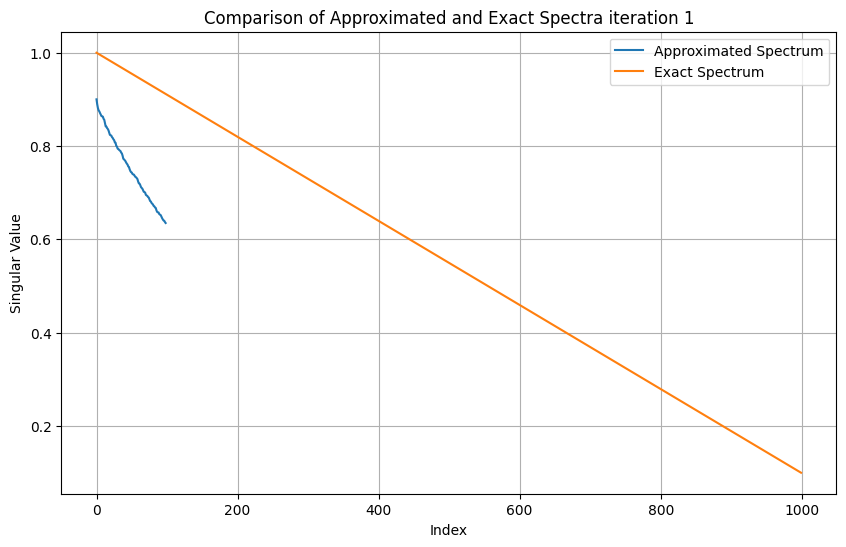

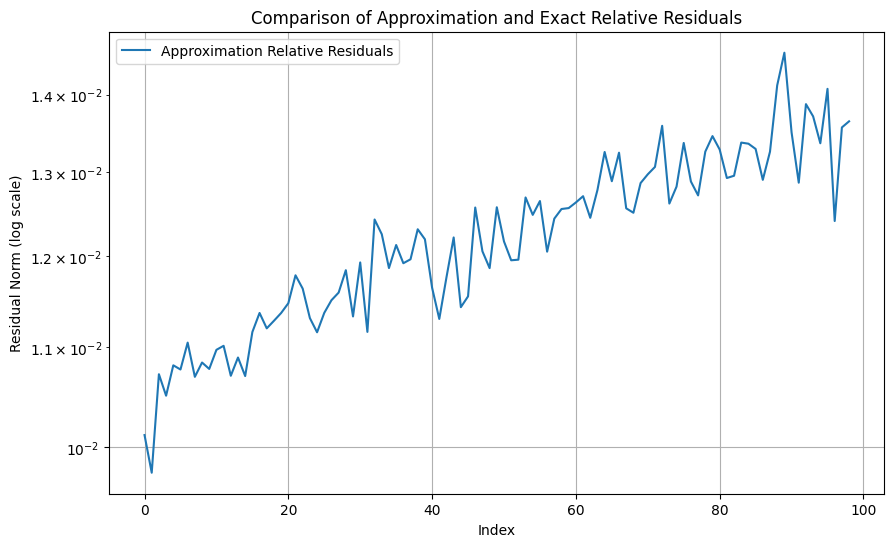

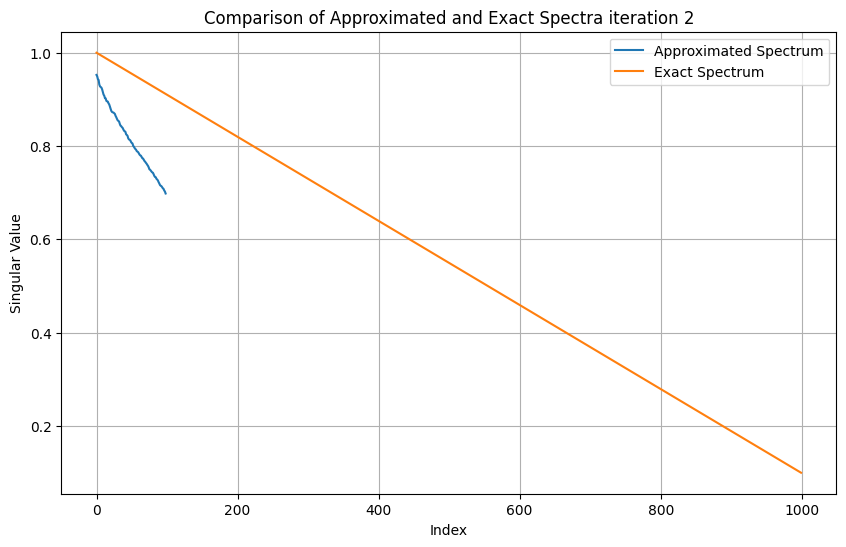

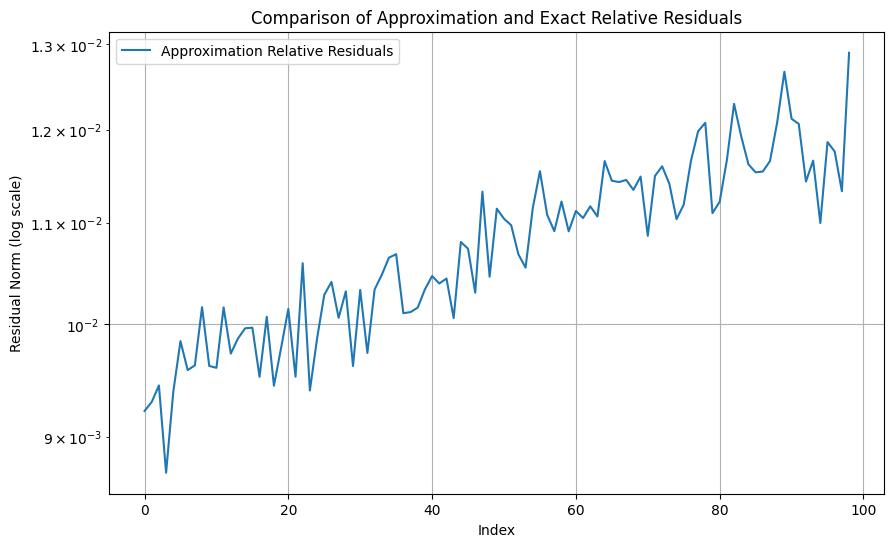

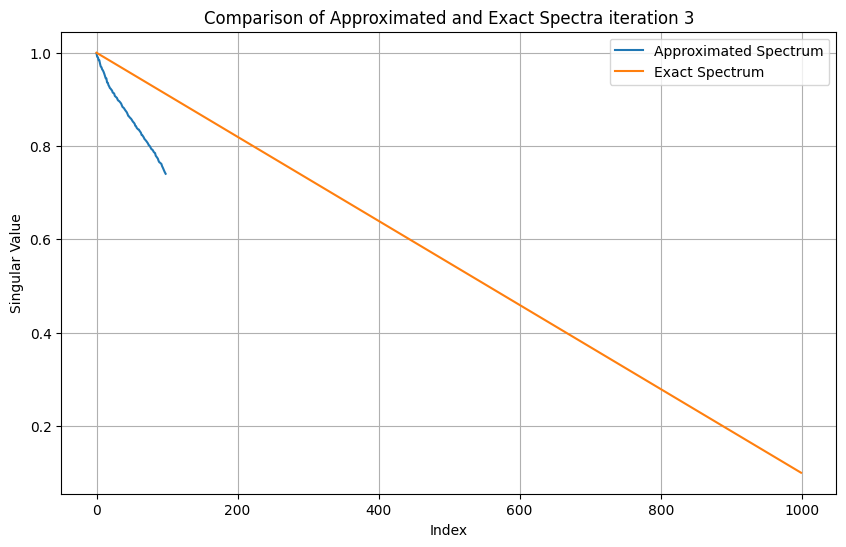

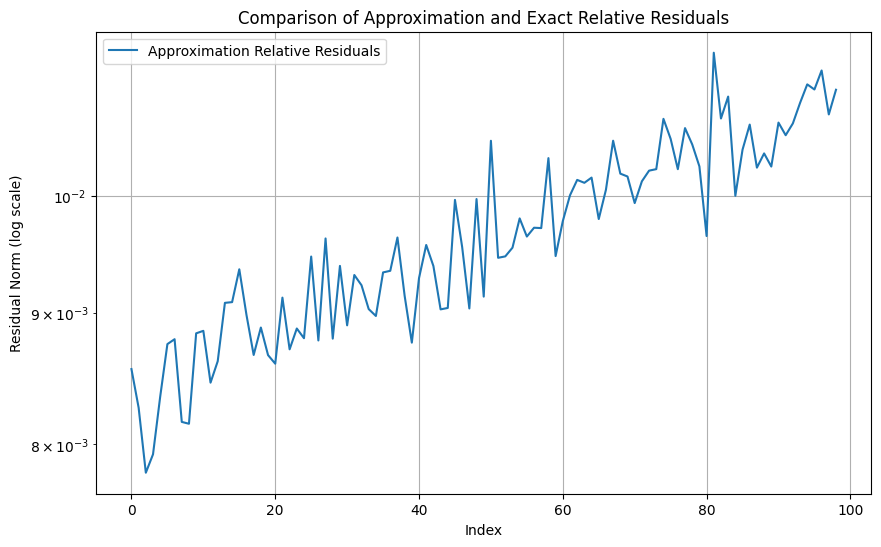

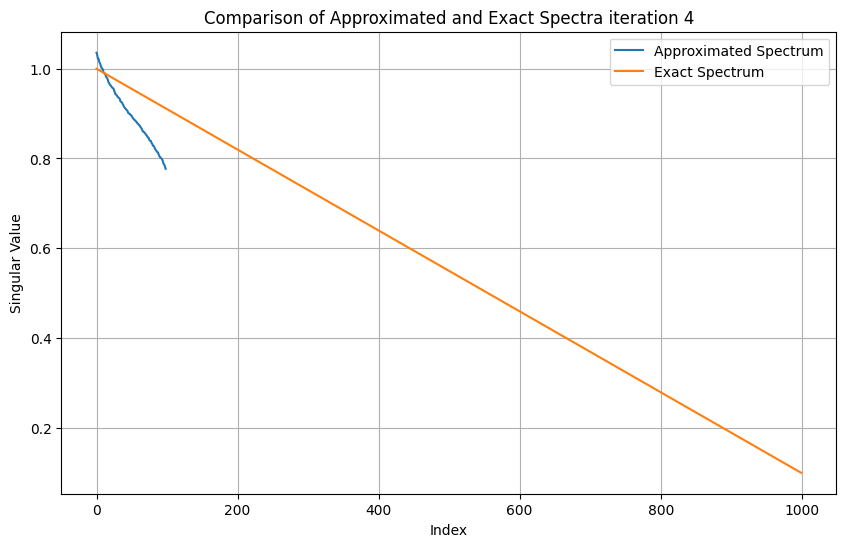

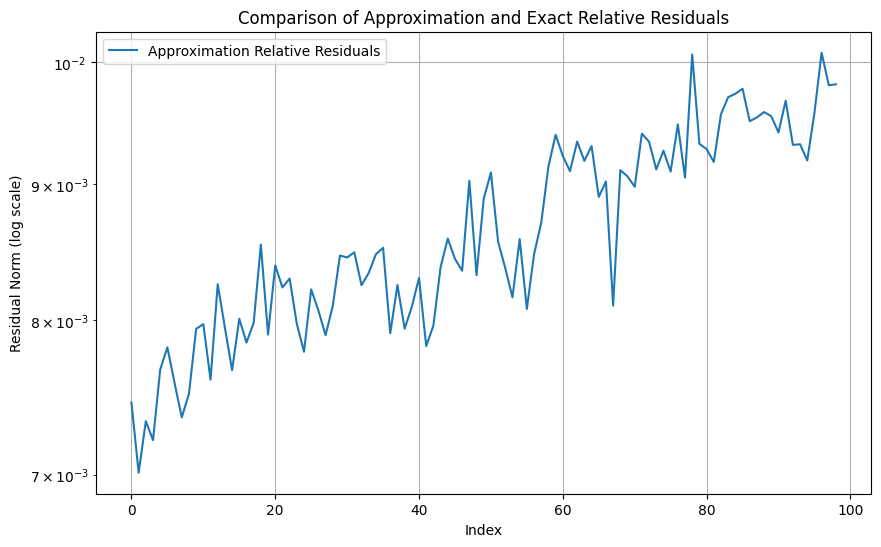

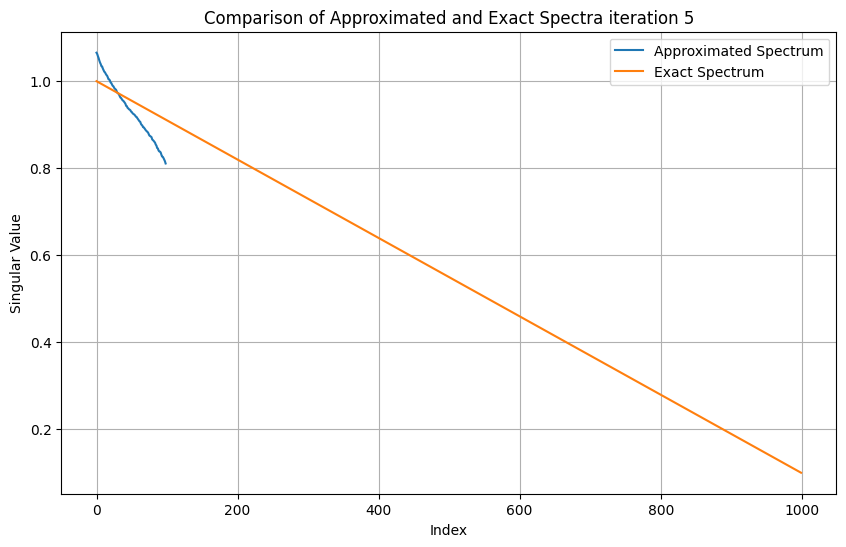

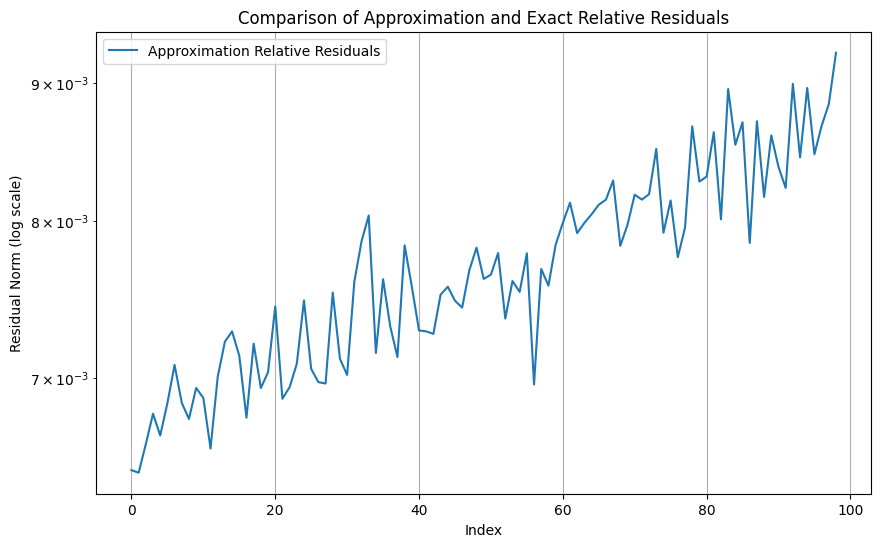

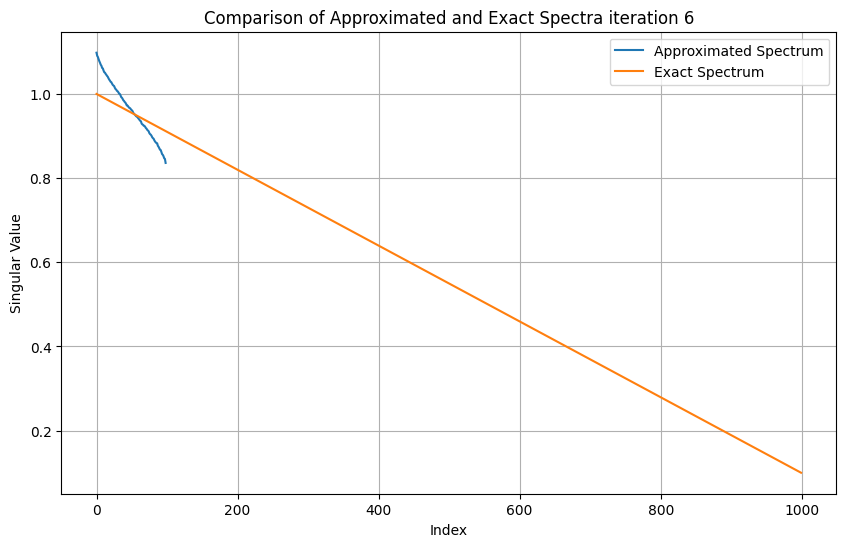

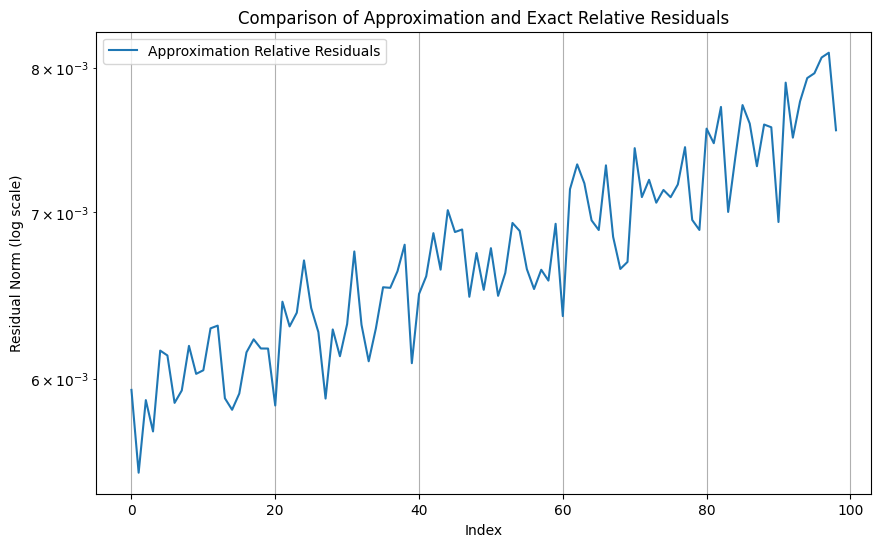

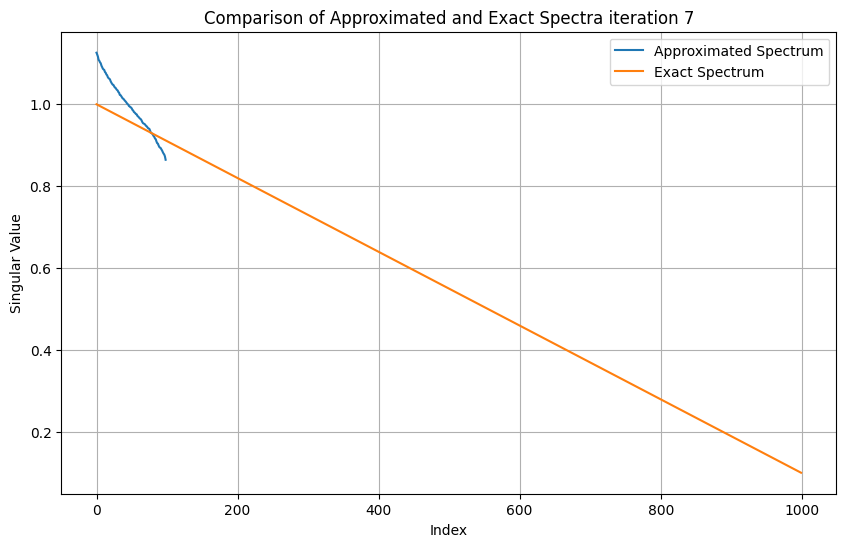

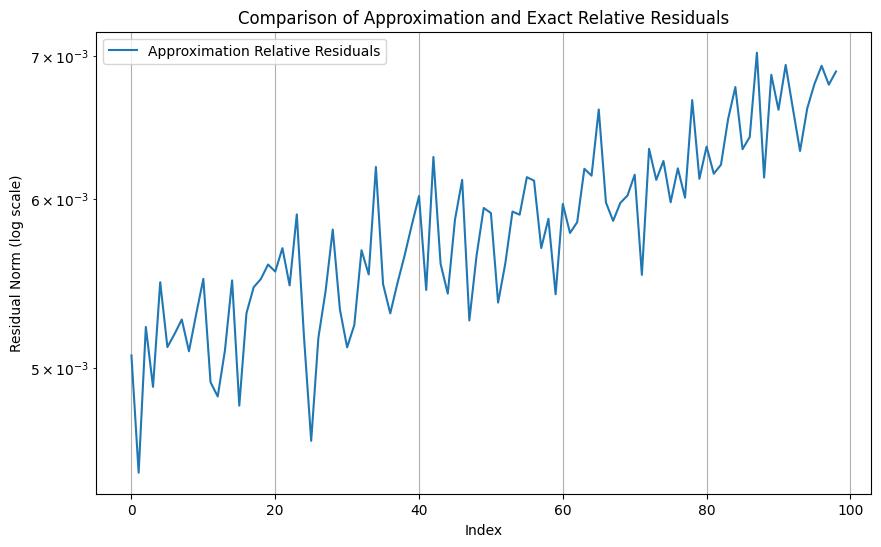

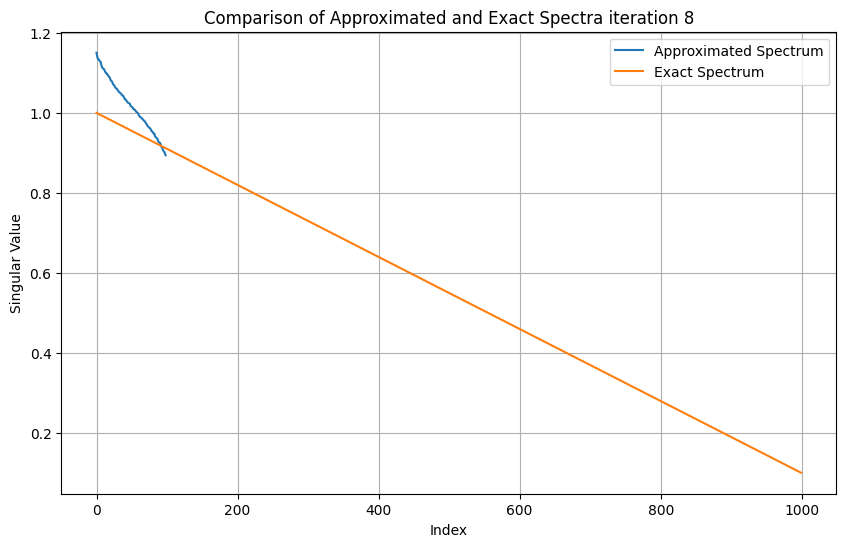

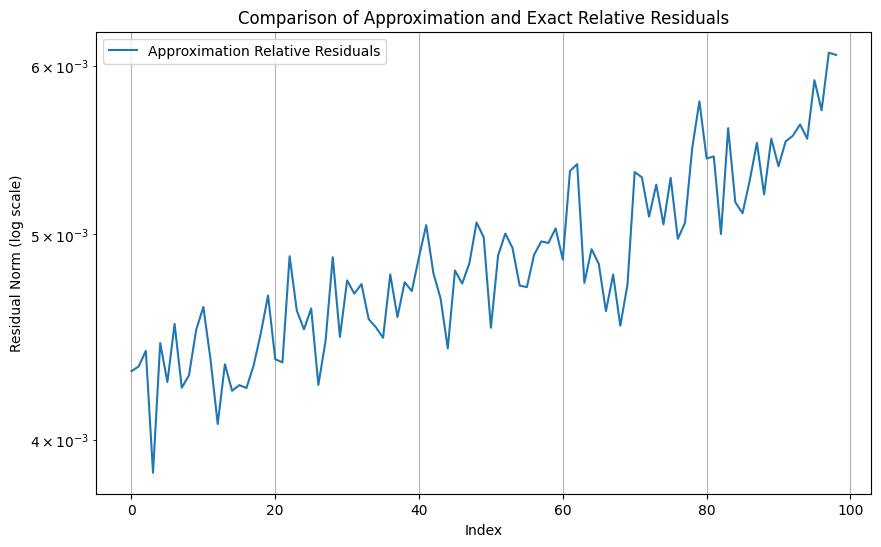

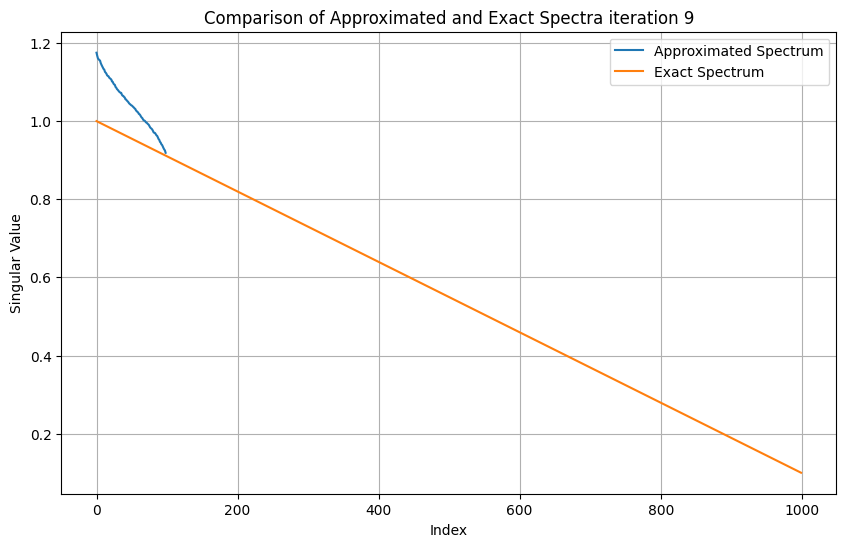

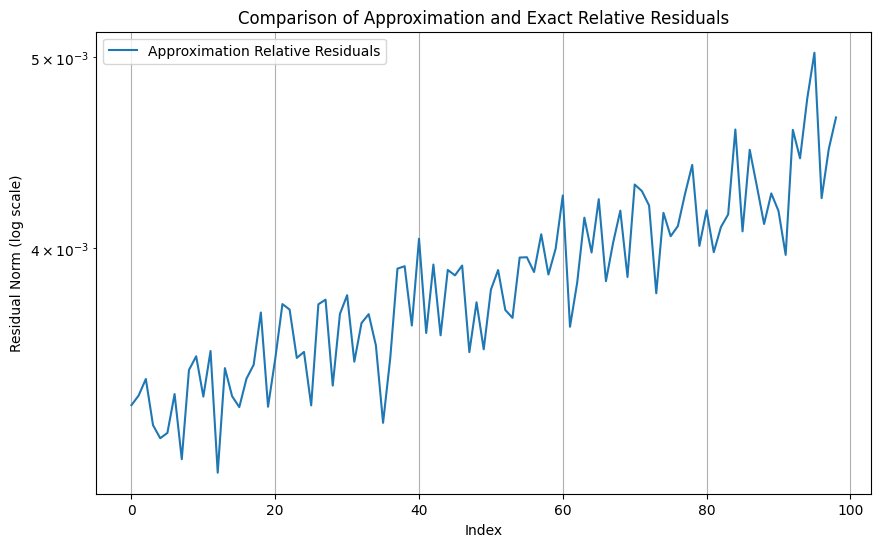

3.465047597885132

In [112]:
A = A_linear
A_csr = A_linear
Vt_exact = V_linear.T
U_exact = U_linear
S_exact = s_linear

# Timing the incremental SVD
start_time = time.time()
# U_inc, S_inc, Vt_inc = incremental_svd(A_csr, k
m, n = A_csr.shape
W = 10  # number of windows (columns in this case)
l = m // W  # window size
k = l-1 # Number of singular values/vectors to compute
r = min(k, m, l)

# Initial SVD for the first window
_, S, Vt = svds(A_csr[:l,:], k=r)

print(Vt.shape)

# Reverse the order to get largest singular values first
S = S[::-1]
Vt = Vt[::-1, :]

B = S.reshape(-1, 1) * Vt

for j in range(1, W):    
    j = j % W     # stream in cycle when all rows have been processed
    # Extract the next window
    next_window = A_csr[j*l:(j+1)*l,:]
    
    # Concatenate B[j-1] and the next window
    combined = np.concatenate((B, next_window), axis=0)
    
    # Perform SVD on the combined matrix
    _, S, Vt = svds(combined, k=r)
    
    # Reverse the order to get largest singular values first
    S = S[::-1]
    Vt = Vt[::-1, :]
    
    # Optional: Apply soft thresholding to singular values
    # S = soft_thresholding(S)
    # S = soft_thresholding_Ghashami(S)
    
    # Update B
    B = S.reshape(-1, 1) * Vt

    # Plot
    # TODO: plot for each window
    # if j % 10 != 1:
    #     continue
        
    plt.figure(figsize=(10, 6))
    plt.plot(S, label='Approximated Spectrum')
    plt.plot(S_exact, label='Exact Spectrum')
    # plt.plot(np.abs(S - S_exact))
    plt.xlabel('Index')
    plt.ylabel('Singular Value')
    plt.title(f'Comparison of Approximated and Exact Spectra iteration {j}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # plt.figure(figsize=(10, 6))
    # # plt.plot(S, label='Approximated Spectrum')
    # # plt.plot(S_exact, label='Exact Spectrum')
    # plt.plot(np.abs(S - S_exact) / S_exact)
    # plt.xlabel('Index')
    # plt.ylabel('Singular Value')
    # plt.title('Relative Difference')
    # plt.legend()
    # plt.grid(True)
    # plt.show()
    
    approx_residuals = []
    exact_residuals = []
    
    for i in range(len(S)):
        # Approximated residual
        # approx_res = A.T @ (A @ Vt[i].T) - S[i]**2 * Vt[i].T
        approx_res = (A @ Vt[i].T) - S[i] * Vt[i].T
        approx_residuals.append(np.linalg.norm(approx_res) / np.linalg.norm(A))

    approx_residuals, exact_residuals = np.array(approx_residuals), np.array(exact_residuals)
    
    plt.figure(figsize=(10, 6))
    plt.semilogy(approx_residuals, label='Approximation Relative Residuals')
    # plt.semilogy(exact_residuals, label='Exact Relative Residuals')
    plt.xlabel('Index')
    plt.ylabel('Residual Norm (log scale)')
    plt.title('Comparison of Approximation and Exact Relative Residuals')
    plt.legend()
    plt.grid(True)
    plt.show()

linear_time = time.time() - start_time
linear_time

22.1436410388768

(1000, 1000) (99,) (99, 1000)


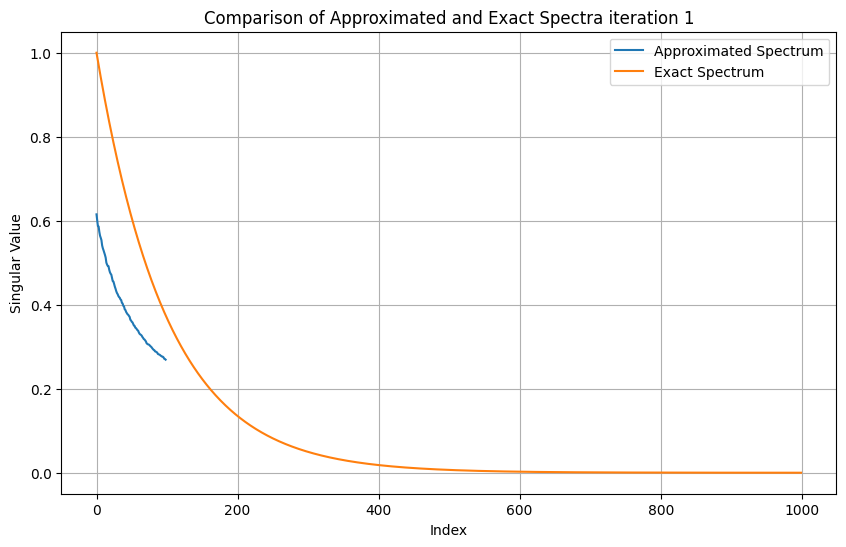

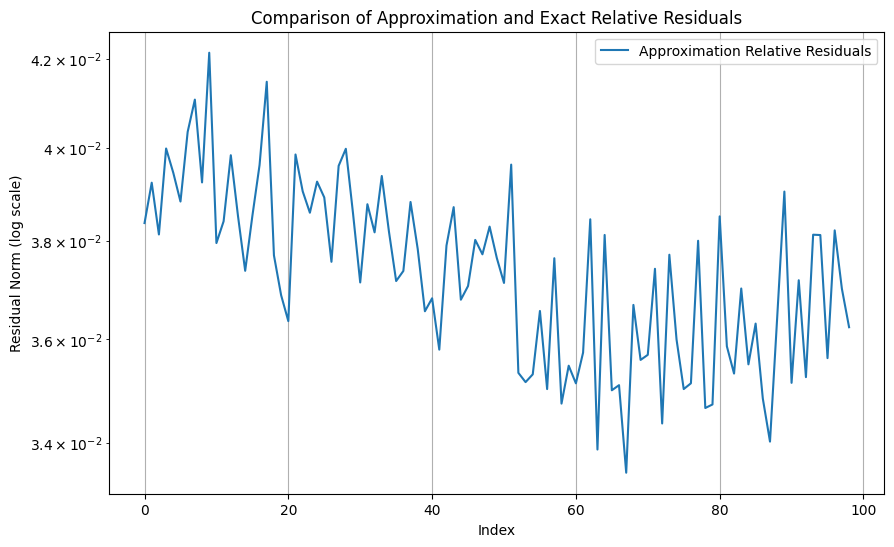

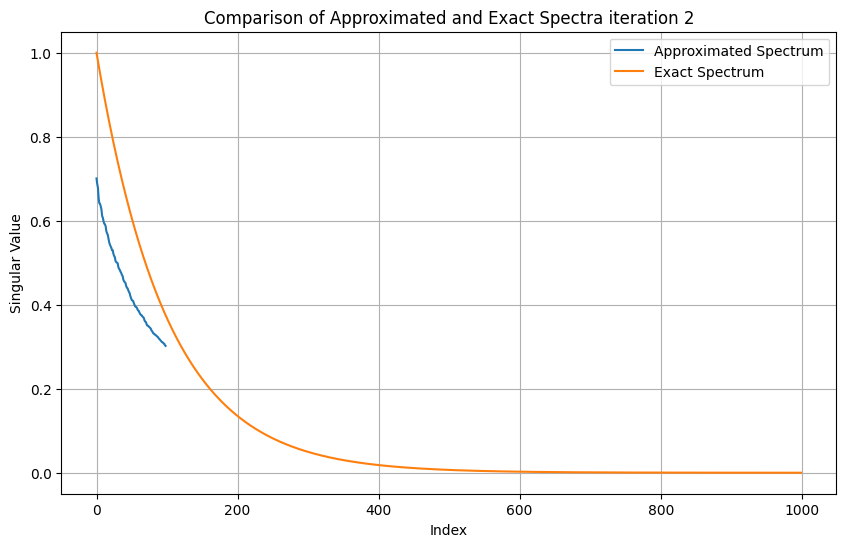

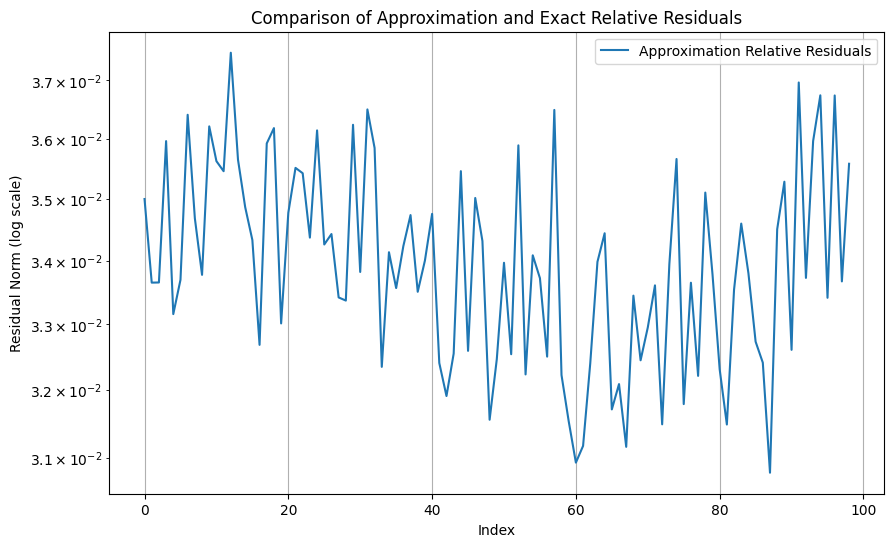

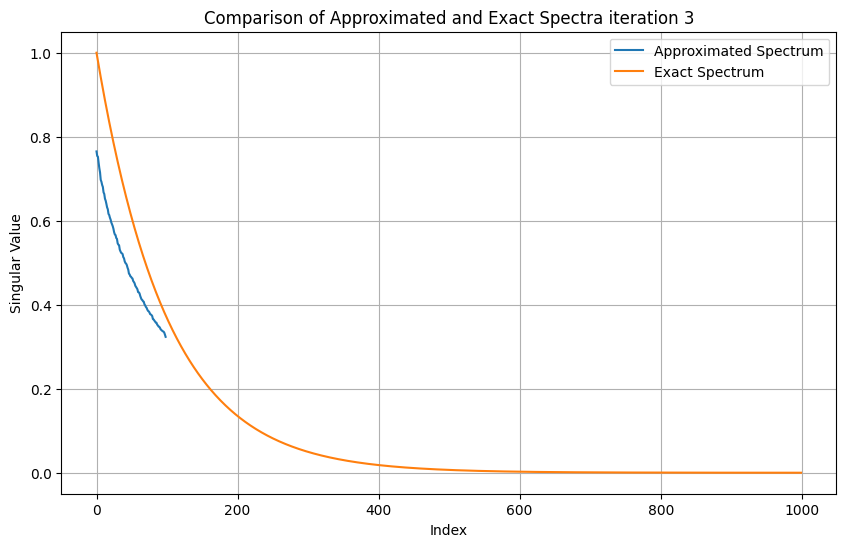

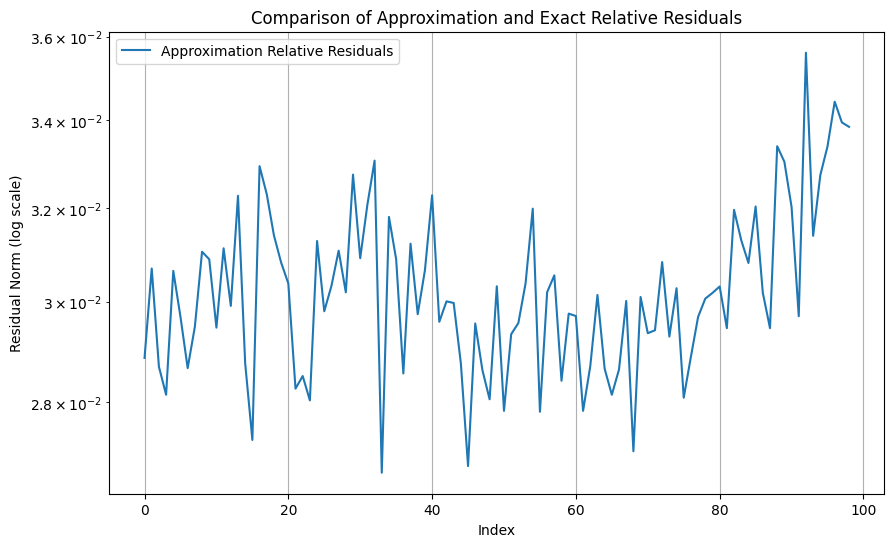

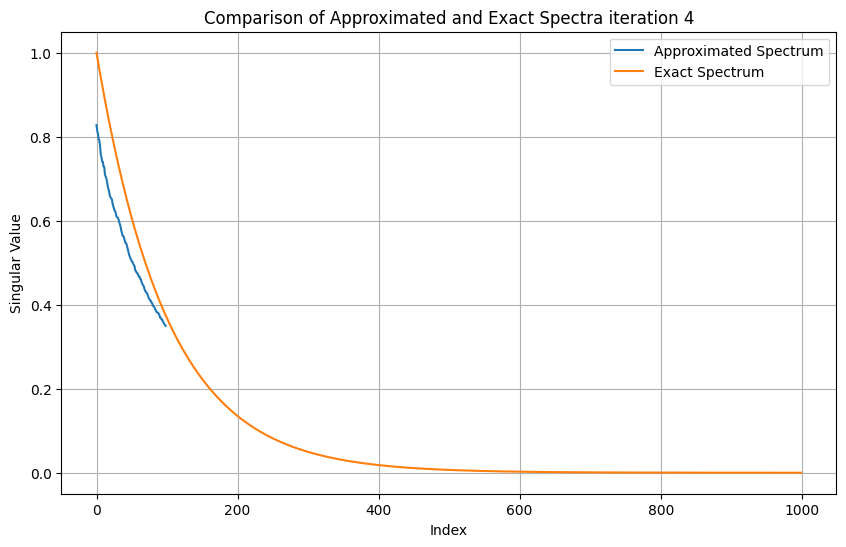

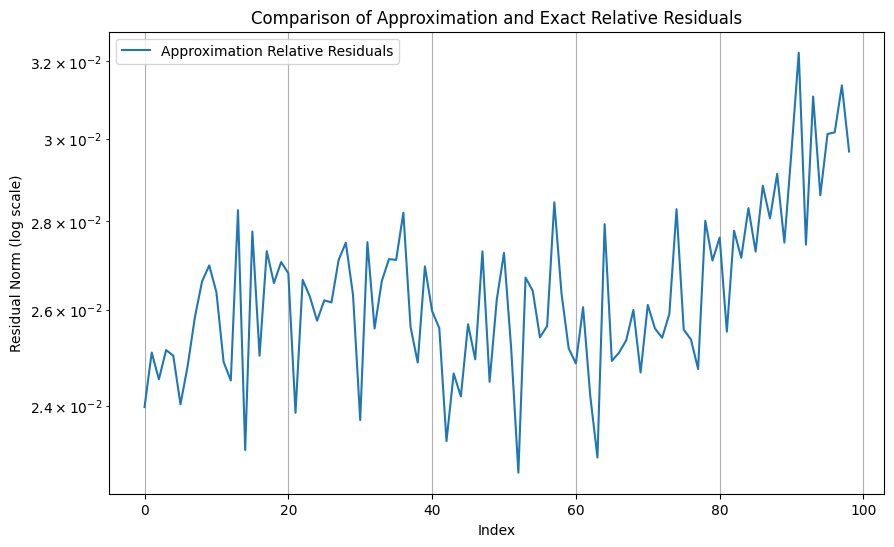

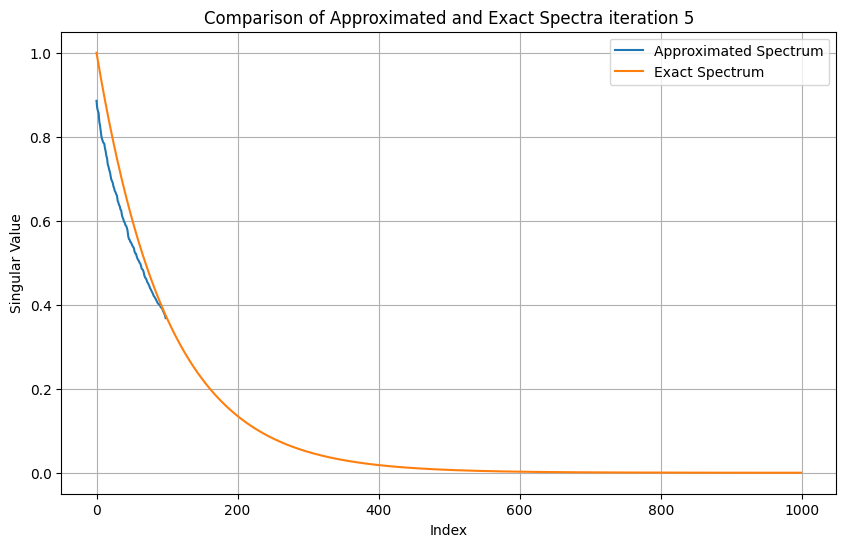

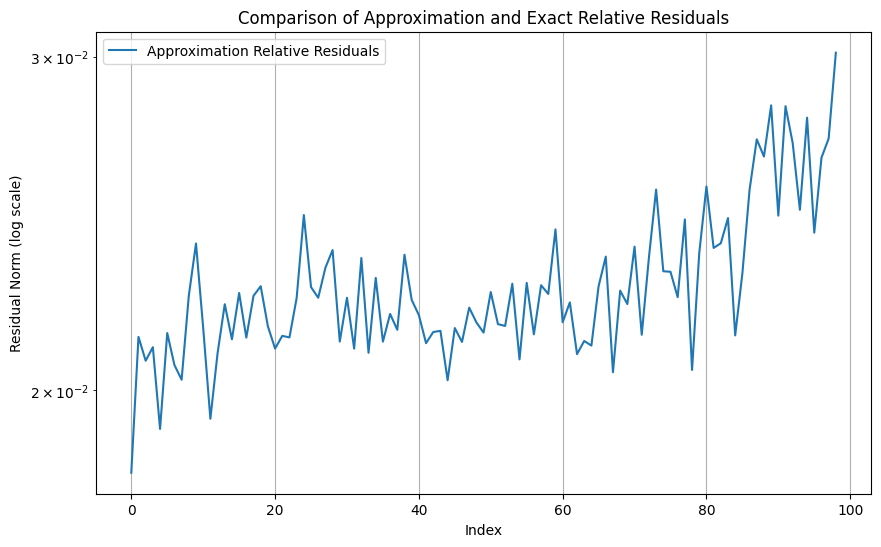

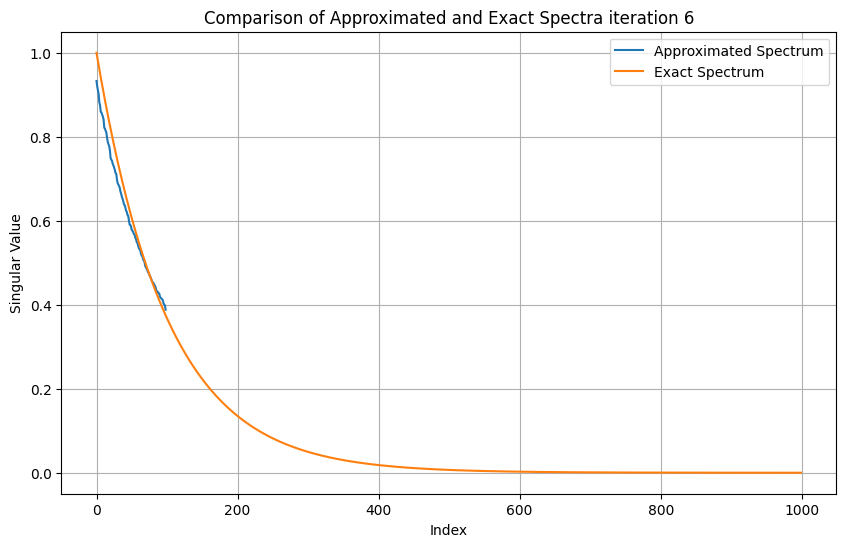

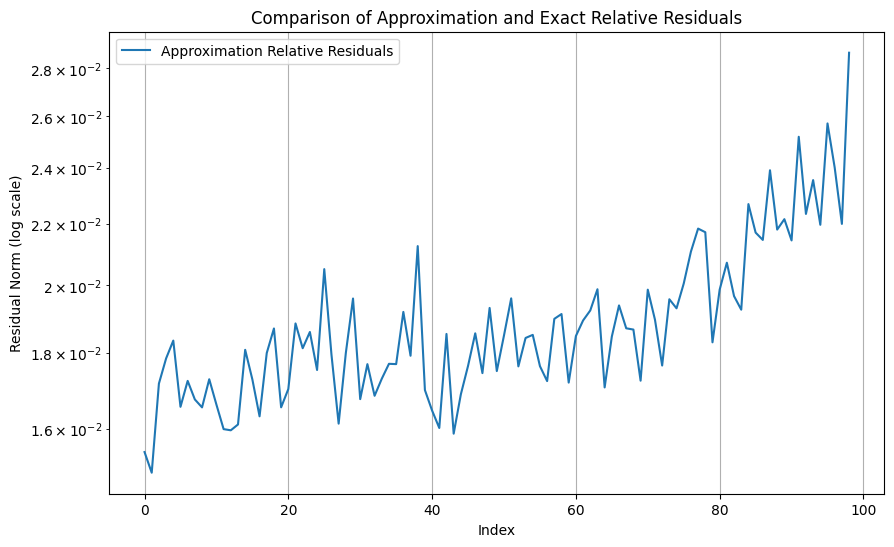

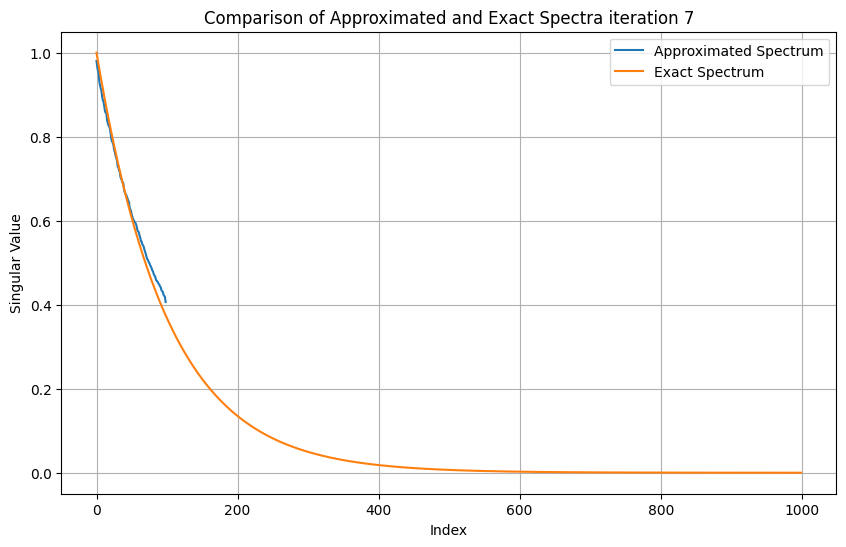

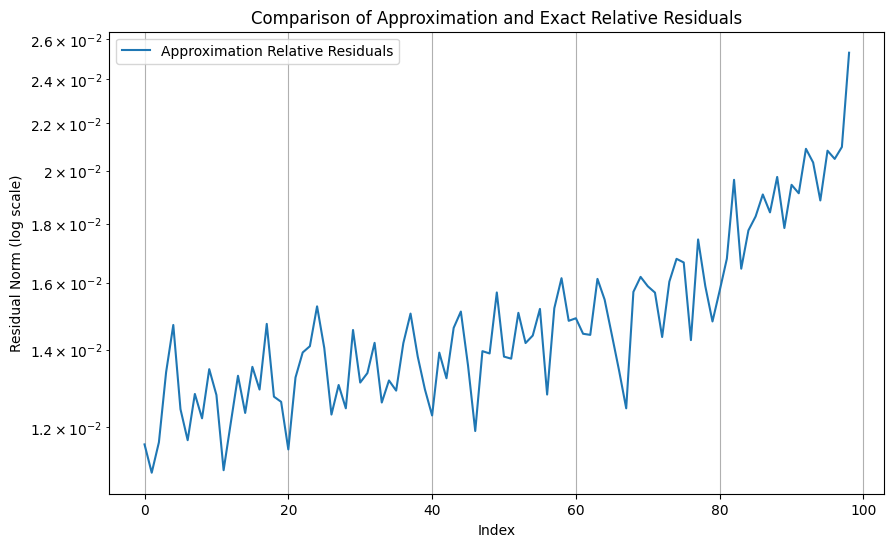

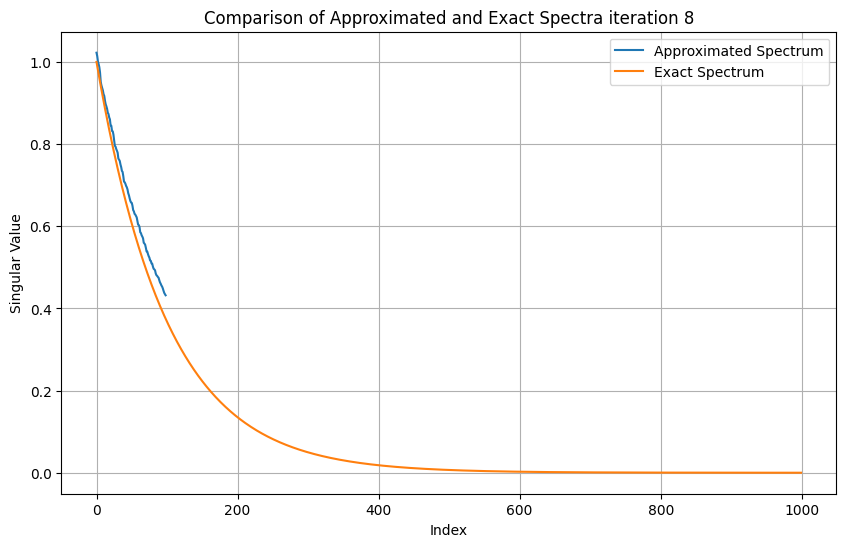

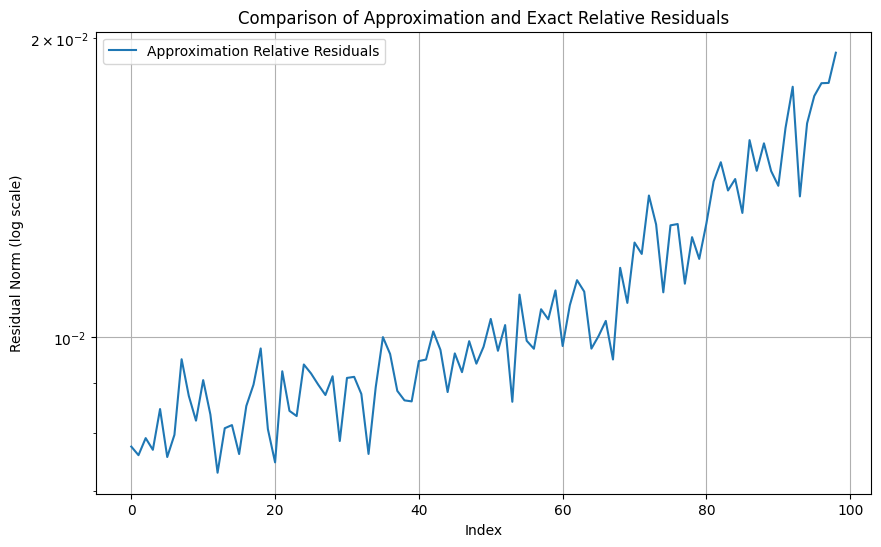

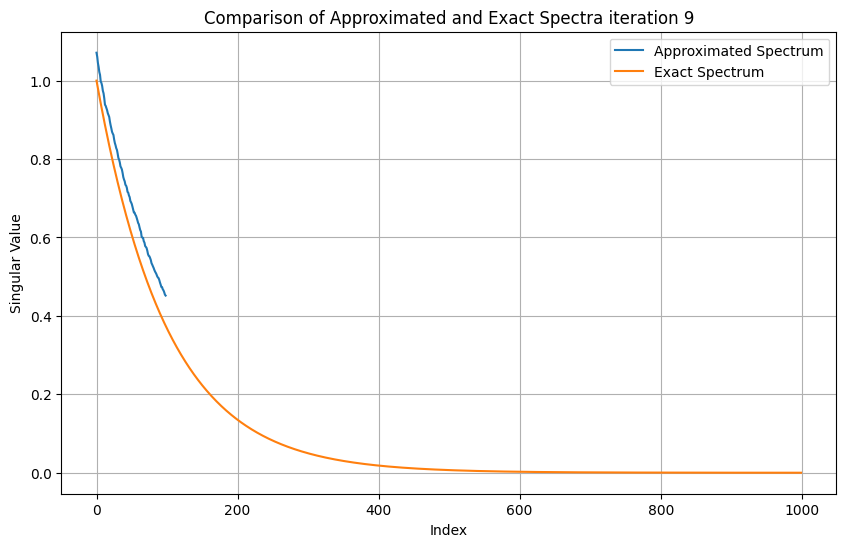

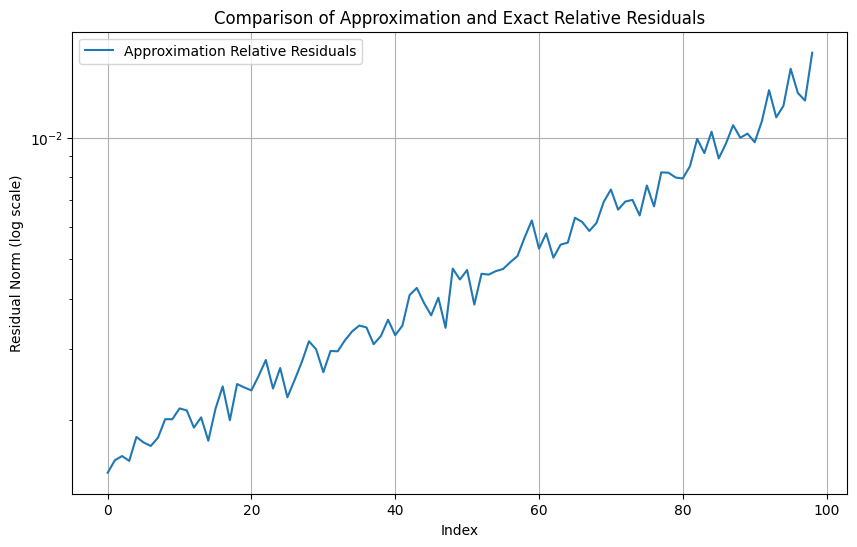

3.725635290145874

In [113]:
A = A_exp
A_csr = A_exp
Vt_exact = V_exp.T
U_exact = U_exp
S_exact = s_exp

# Timing the incremental SVD
start_time = time.time()
# U_inc, S_inc, Vt_inc = incremental_svd(A_csr, k
m, n = A_csr.shape
W = 10  # number of windows (columns in this case)
l = m // W  # window size
k = l-1 # Number of singular values/vectors to compute
r = min(k, m, l)

# Initial SVD for the first window
_, S, Vt = svds(A_csr[:l,:], k=r)

print(A.shape, S.shape, Vt.shape)

# Reverse the order to get largest singular values first
S = S[::-1]
Vt = Vt[::-1, :]

B = S.reshape(-1, 1) * Vt

for j in range(1, W):    
    j = j % W     # stream in cycle when all rows have been processed
    # Extract the next window
    next_window = A_csr[j*l:(j+1)*l,:]
    
    # Concatenate B[j-1] and the next window
    combined = np.concatenate((B, next_window), axis=0)
    
    # Perform SVD on the combined matrix
    _, S, Vt = svds(combined, k=r)
    
    # Reverse the order to get largest singular values first
    S = S[::-1]
    Vt = Vt[::-1, :]
    
    # Optional: Apply soft thresholding to singular values
    # S = soft_thresholding(S)
    # S = soft_thresholding_Ghashami(S)
    
    # Update B
    B = S.reshape(-1, 1) * Vt

    # Plot
    # TODO: plot for each window
    # if j % 10 != 1:
    #     continue
        
    plt.figure(figsize=(10, 6))
    plt.plot(S, label='Approximated Spectrum')
    plt.plot(S_exact, label='Exact Spectrum')
    # plt.plot(np.abs(S - S_exact))
    plt.xlabel('Index')
    plt.ylabel('Singular Value')
    plt.title(f'Comparison of Approximated and Exact Spectra iteration {j}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # plt.figure(figsize=(10, 6))
    # # plt.plot(S, label='Approximated Spectrum')
    # # plt.plot(S_exact, label='Exact Spectrum')
    # plt.plot(np.abs(S - S_exact) / S_exact)
    # plt.xlabel('Index')
    # plt.ylabel('Singular Value')
    # plt.title('Relative Difference')
    # plt.legend()
    # plt.grid(True)
    # plt.show()
    
    approx_residuals = []
    exact_residuals = []
    
    for i in range(len(S)):
        # Approximated residual
        # approx_res = A.T @ (A @ Vt[i].T) - S[i]**2 * Vt[i].T
        approx_res = (A @ Vt[i].T) - S[i] * Vt[i].T
        approx_residuals.append(np.linalg.norm(approx_res) / np.linalg.norm(A))

    approx_residuals, exact_residuals = np.array(approx_residuals), np.array(exact_residuals)
    
    plt.figure(figsize=(10, 6))
    plt.semilogy(approx_residuals, label='Approximation Relative Residuals')
    # plt.semilogy(exact_residuals, label='Exact Relative Residuals')
    plt.xlabel('Index')
    plt.ylabel('Residual Norm (log scale)')
    plt.title('Comparison of Approximation and Exact Relative Residuals')
    plt.legend()
    plt.grid(True)
    plt.show()

linear_time = time.time() - start_time
linear_time

####
## Draft

In [ ]:


# Initialize variables
AtAv = np.zeros_like(v_t_hat)
num_rows = A.shape[0]  # Assuming A is a 2D array

# Process A in batches
for i in range(0, num_rows, batch_size):
    # Read a batch of rows from A
    A_batch = read_batch(A, i, min(i + batch_size, num_rows))
    
    # Compute (A_batch.T @ A_batch @ v_t_hat) and add to AtAv
    AtAv += A_batch.T @ (A_batch @ v_t_hat)

# Compute the residual
residual = AtAv - sigma_t_hat * v_t_hat

# Return the L2 norm of the residual
return np.linalg.norm(residual, 2)

In [ ]:
Vt_exact.shape

In [ ]:
inc_time, exact_time

In [ ]:
S_exact

In [ ]:
S

In [ ]:
B.shape

In [ ]:
next_window.shape

In [ ]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

def incremental_svd(A_csr, r):
    assert isinstance(A_csr, csr_matrix), "Input A must be a CSR matrix"
    
    m, n = A_csr.shape
    W = n  # number of windows (columns in this case)
    l = m // W  # window size

    # Initial SVD for the first window
    _, S, Vt = svds(A_csr[:, :l], k=r)
    
    # Reverse the order to get largest singular values first
    S = S[::-1]
    Vt = Vt[::-1, :]
    
    B = S.reshape(-1, 1) * Vt

    for j in range(1, W):
        # Extract the next window
        next_window = A_csr[:, j*l:(j+1)*l].toarray()
        
        # Concatenate B[j-1] and the next window
        combined = np.hstack((B, next_window))
        
        # Perform SVD on the combined matrix
        _, S, Vt = svds(csr_matrix(combined), k=r)
        
        # Reverse the order to get largest singular values first
        S = S[::-1]
        Vt = Vt[::-1, :]
        
        # Optional: Apply soft thresholding to singular values
        # S = soft_thresholding(S)
        
        # Update B
        B = S.reshape(-1, 1) * Vt

    return B

# Optional: Soft thresholding function
def soft_thresholding(S, threshold=0):
    return np.maximum(S - threshold, 0)

In [ ]:
# Assuming A is your sparse matrix
U, s, Vt = svds(A, k=1)  # Compute only the largest singular value/vectors

# Reconstruct A using only the largest singular value/vectors
A_approx = U @ np.diag(s) @ Vt

# Compute relative error
relative_error = np.linalg.norm(A.toarray() - A_approx) / np.linalg.norm(A.toarray())
print(f"Relative error of reconstruction: {relative_error}")
print(f"Norm of U: {np.linalg.norm(U)}")
print(f"Norm of V: {np.linalg.norm(Vt.T)}")

v0 = Vt.T[:, 0]  # First right singular vector
sigma0 = s[0]    # Largest singular value

Av = A @ v0
AtAv = A.T @ Av

residual = AtAv - sigma0 * v0
absolute_residual = np.linalg.norm(residual)
relative_residual = absolute_residual / np.linalg.norm(AtAv)

print(f"Absolute residual: {absolute_residual}")
print(f"Relative residual: {relative_residual}")

print(f"Norm of Av: {np.linalg.norm(Av)}")
print(f"Norm of AtAv: {np.linalg.norm(AtAv)}")
print(f"Norm of sigma0 * v0: {np.linalg.norm(sigma0 * v0)}")

diff = AtAv - sigma0 * v0
print(f"Max absolute difference: {np.max(np.abs(diff))}")
print(f"Mean absolute difference: {np.mean(np.abs(diff))}")

In [ ]:
U_full, s_full, Vt_full = np.linalg.svd(A.toarray(), full_matrices=False)
v0_full = Vt_full[0]
sigma0_full = s_full[0]
AtAv_full = A.T @ (A @ v0_full)
residual_full = AtAv_full - sigma0_full**2 * v0_full
relative_residual_full = np.linalg.norm(residual_full) / np.linalg.norm(AtAv_full)
print(f"Relative residual (full SVD): {relative_residual_full}")

In [ ]:
s = s_full
Vt = Vt_full

from scipy.sparse.linalg import eigsh
largest_eigenvalue = eigsh(A.T @ A, k=1, which='LM', return_eigenvectors=False)[0]
print(f"Largest eigenvalue of A^TA: {largest_eigenvalue}")
print(f"σ₀²: {s[0]**2}")

v0 = Vt.T[:, 0]  # First right singular vector
sigma0 = s[0]    # Largest singular value

Av = A @ v0
AtAv = A.T @ Av

residual = AtAv - sigma0**2 * v0
absolute_residual = np.linalg.norm(residual)
relative_residual = absolute_residual / np.linalg.norm(AtAv)

print(f"Absolute residual: {absolute_residual}")
print(f"Relative residual: {relative_residual}")

print(f"Norm of Av: {np.linalg.norm(Av)}")
print(f"Norm of AtAv: {np.linalg.norm(AtAv)}")
print(f"Norm of sigma0 * v0: {np.linalg.norm(sigma0**2 * v0)}")

diff = AtAv - sigma0 * v0
print(f"Max absolute difference: {np.max(np.abs(diff))}")
print(f"Mean absolute difference: {np.mean(np.abs(diff))}")

In [408]:
import numpy as np
from scipy.linalg import eigh, svd, orth
from scipy.stats import special_ortho_group

def generate_symmetric_matrix(n, rank=None):
    """Generate a random symmetric matrix with optional low rank."""
    if rank is None or rank > n:
        rank = n
    Q = special_ortho_group.rvs(n)
    s = np.logspace(0, -10, rank)  # Exponentially decaying singular values
    s = np.pad(s, (0, n-rank))
    return Q @ np.diag(s) @ Q.T

def canonical_correlations(A, B):
    # Orthogonalize the matrices
    A_orth = orth(A)
    B_orth = orth(B)
    
    # Compute SVD of the cross-covariance matrix
    s = svd(A_orth.T @ B_orth, compute_uv=False)
    # s = svd(A.T @ B, compute_uv=False) / np.sqrt(A.shape[0] - 1)
    
    # Ensure correlations are between 0 and 1
    return np.clip(s, 0, 1)[::-1]

# def canonical_correlations(A, B):
#     """Compute canonical correlations between columns of A and B."""
#     U, _, Vt = svd(A.T @ B)
#     return np.clip(np.diag(U @ Vt), 0, 1)

def compare_eigenvectors(A, k):
    """Compare eigenvectors of full matrix A and its submatrix A[:k, :]."""
    n = A.shape[0]
    
    # Eigenvectors of full matrix
    S_full, V_full = eigh(A)
    
    # Left singular vectors of submatrix
    _, S, Vt_sub = svd(A[:k, :], full_matrices=False)

    print(V_full[-k:, :].shape, Vt_sub.shape)
    
    print(S)
    print(S_full)
    
    # Compute canonical correlations
    corr = canonical_correlations(V_full[-k:, :], Vt_sub)
    
    return corr

# Set parameters
n = 100  # Size of the full matrix
k = 10   # Size of the submatrix

# Generate a random symmetric matrix
A = generate_symmetric_matrix(n, rank=20)

# Compare eigenvectors
correlations = compare_eigenvectors(A, k)

print("Canonical correlations:")
print(correlations)
print("\nNumber of correlations ≈ 1 (>0.99999):", np.sum(correlations > 0.99999))

(10, 100) (10, 100)
[3.55425023e-01 9.61362877e-02 2.83859553e-02 8.02176176e-03
 1.56423217e-03 5.68604186e-04 8.77024029e-05 3.24009090e-05
 1.01055805e-05 1.91862333e-06]
[-1.22290147e-16 -1.96770528e-17 -1.77299751e-17 -1.39450644e-17
 -1.35251807e-17 -1.30574783e-17 -1.23086456e-17 -1.17093835e-17
 -1.04206055e-17 -1.03542971e-17 -9.64683595e-18 -9.21753877e-18
 -6.54851369e-18 -6.48329294e-18 -5.91425593e-18 -5.78707866e-18
 -5.64617525e-18 -4.46381391e-18 -3.57373475e-18 -3.54589798e-18
 -3.40869328e-18 -2.59235158e-18 -2.56651566e-18 -2.37730761e-18
 -2.33618051e-18 -2.32977196e-18 -2.07919018e-18 -1.92541470e-18
 -1.82785695e-18 -1.73446569e-18 -1.59509146e-18 -1.40535644e-18
 -1.32786742e-18 -1.14590126e-18 -1.10066066e-18 -9.47470175e-19
 -9.26668662e-19 -6.95022403e-19 -6.02436059e-19 -1.53693552e-19
 -9.02881967e-20 -1.50444084e-20  1.52182718e-20  9.53339678e-20
  1.00908235e-19  2.32123122e-19  2.35544974e-19  2.75095552e-19
  3.57547224e-19  7.79637997e-19  8.62264964e-

In [420]:
n = A.shape[0]
    
# Eigenvectors of full matrix
S_full, V_full = eigh(A)

# Left singular vectors of submatrix
_, S, Vt_sub = svd(A[:k, :], full_matrices=False)

print(V_full[-k:, :].shape, Vt_sub.shape)

print(S)
print(S_full)

# Compute canonical correlations
corr = canonical_correlations(V_full[:k, :].T, Vt_sub.T)
corr

(10, 100) (10, 100)
[3.55425023e-01 9.61362877e-02 2.83859553e-02 8.02176176e-03
 1.56423217e-03 5.68604186e-04 8.77024029e-05 3.24009090e-05
 1.01055805e-05 1.91862333e-06]
[-1.22290147e-16 -1.96770528e-17 -1.77299751e-17 -1.39450644e-17
 -1.35251807e-17 -1.30574783e-17 -1.23086456e-17 -1.17093835e-17
 -1.04206055e-17 -1.03542971e-17 -9.64683595e-18 -9.21753877e-18
 -6.54851369e-18 -6.48329294e-18 -5.91425593e-18 -5.78707866e-18
 -5.64617525e-18 -4.46381391e-18 -3.57373475e-18 -3.54589798e-18
 -3.40869328e-18 -2.59235158e-18 -2.56651566e-18 -2.37730761e-18
 -2.33618051e-18 -2.32977196e-18 -2.07919018e-18 -1.92541470e-18
 -1.82785695e-18 -1.73446569e-18 -1.59509146e-18 -1.40535644e-18
 -1.32786742e-18 -1.14590126e-18 -1.10066066e-18 -9.47470175e-19
 -9.26668662e-19 -6.95022403e-19 -6.02436059e-19 -1.53693552e-19
 -9.02881967e-20 -1.50444084e-20  1.52182718e-20  9.53339678e-20
  1.00908235e-19  2.32123122e-19  2.35544974e-19  2.75095552e-19
  3.57547224e-19  7.79637997e-19  8.62264964e-

array([0.03427087, 0.06671818, 0.19882144, 0.23108225, 0.24408612,
       0.34430066, 0.38687876, 0.41902575, 0.50451922, 0.5841176 ])

In [7]:
import numpy as np
from scipy.optimize import linear_sum_assignment

def match_eigenpairs(estimated_eigenvalues, estimated_eigenvectors, 
                     exact_eigenvalues, exact_eigenvectors, 
                     angle_threshold=np.pi/4):
    n = len(estimated_eigenvalues)
    
    # Normalize eigenvectors
    estimated_eigenvectors = estimated_eigenvectors / np.linalg.norm(estimated_eigenvectors, axis=0)
    exact_eigenvectors = exact_eigenvectors / np.linalg.norm(exact_eigenvectors, axis=0)
    
    # Compute cosine similarities
    similarities = np.abs(np.dot(estimated_eigenvectors.T, exact_eigenvectors))
    
    # Use the Hungarian algorithm to find the best matches
    row_ind, col_ind = linear_sum_assignment(-similarities)
    
    # Create the matches and check against the threshold
    matches = []
    for i, j in zip(row_ind, col_ind):
        angle = np.arccos(similarities[i, j])
        if angle <= angle_threshold:
            matches.append((i, j, estimated_eigenvalues[i], exact_eigenvalues[j], angle))
    
    return matches

# Example usage
estimated_eigenvalues = np.array([1.1, 2.05, 3.02])
estimated_eigenvectors = np.array([[0.71, -0.55, 0.41],
                                   [0.71, 0.83, -0.41],
                                   [0.01, 0.01, 0.82]])

exact_eigenvalues = np.array([1.0, 2.0, 3.0])
exact_eigenvectors = np.array([[0.71, -0.58, 0.40],
                               [0.71, 0.82, -0.40],
                               [0.00, 0.00, 0.82]])

matches = match_eigenpairs(estimated_eigenvalues, estimated_eigenvectors, 
                           exact_eigenvalues, exact_eigenvectors)

for match in matches:
    print(f"Estimated eigenpair {match[0]} matched with exact eigenpair {match[1]}")
    print(f"Estimated eigenvalue: {match[2]:.4f}, Exact eigenvalue: {match[3]:.4f}")
    print(f"Angle between eigenvectors: {match[4]:.4f} radians")
    print()

Estimated eigenpair 0 matched with exact eigenpair 0
Estimated eigenvalue: 1.1000, Exact eigenvalue: 1.0000
Angle between eigenvectors: 0.0100 radians

Estimated eigenpair 1 matched with exact eigenpair 1
Estimated eigenvalue: 2.0500, Exact eigenvalue: 2.0000
Angle between eigenvectors: 0.0320 radians

Estimated eigenpair 2 matched with exact eigenpair 2
Estimated eigenvalue: 3.0200, Exact eigenvalue: 3.0000
Angle between eigenvectors: 0.0116 radians



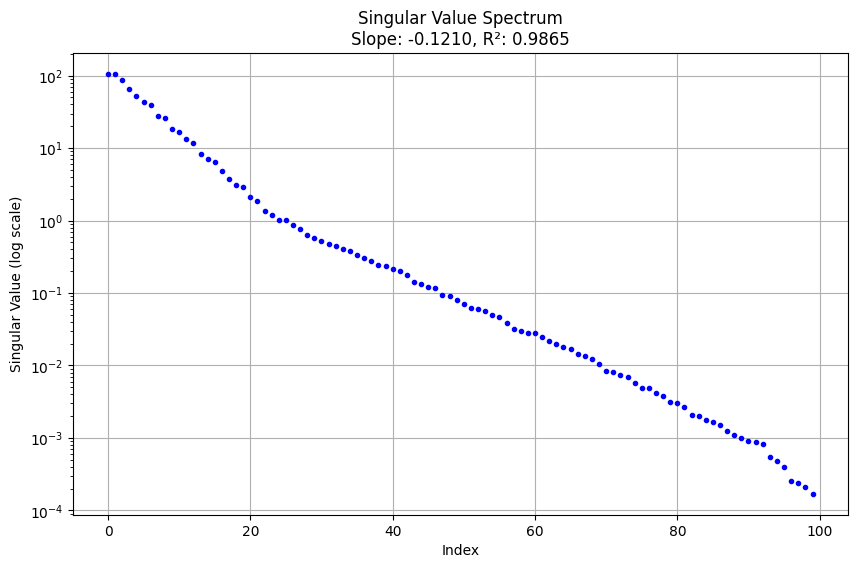

Block 1 - Slope: -0.4148, R²: 0.8880
Block 2 - Slope: -0.2408, R²: 1.0000
Block 3 - Slope: -0.4112, R²: 0.9966
Block 4 - Slope: -0.4148, R²: 0.8857
Block 5 - Slope: -0.3726, R²: 0.7748


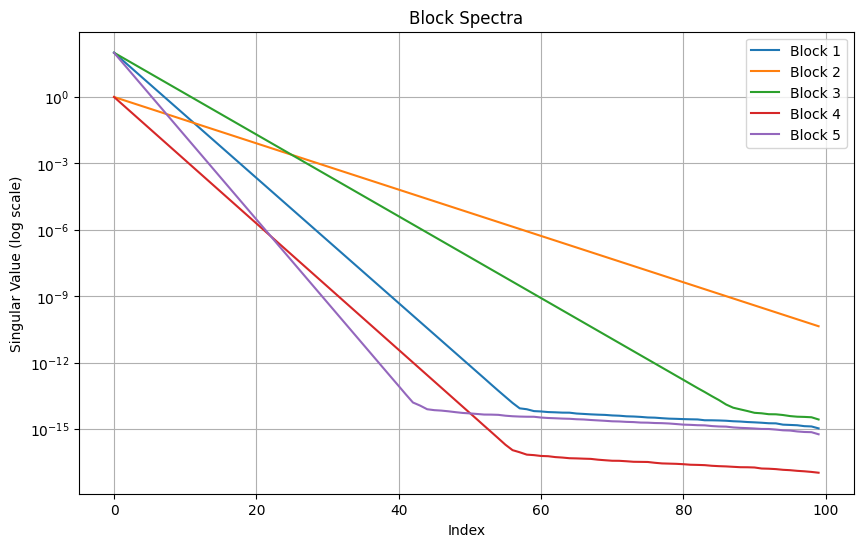

In [275]:
import numpy as np

def create_exp_decay_matrix(n, d, alpha=0.1):
    # Create diagonal matrix with exponential decay
    s = np.exp(-alpha * np.arange(min(n, d)))
    U, _ = np.linalg.qr(np.random.randn(n, min(n, d)))
    V, _ = np.linalg.qr(np.random.randn(d, min(n, d)))
    return U @ np.diag(s) @ V.T

def create_dramatic_block_matrix(n, d, num_blocks=5, dramatic_factor=100, alpha=0.1):
    block_size = n // num_blocks
    blocks = []
    
    for i in range(num_blocks):
        block = create_exp_decay_matrix(block_size, d, alpha*np.random.uniform(1,10))
        
        # Make some blocks dramatically larger
        if i % 2 == 0:  # Every other block
            block *= dramatic_factor
        
        blocks.append(block)
    
    return np.vstack(blocks)

import matplotlib.pyplot as plt

from scipy import stats

def calculate_log_slope(x, y):
    # Use only positive values for log calculation
    positive_mask = y > 0
    x_pos, y_pos = x[positive_mask], y[positive_mask]
    
    # Perform linear regression on log-transformed data
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_pos, np.log(y_pos))
    return slope, r_value**2

# Generate matrix
n, d = 1000, 100
A = create_dramatic_block_matrix(n, d)

# Compute singular values
s = np.linalg.svd(A, compute_uv=False)

# Calculate slope of the whole spectrum
x = np.arange(len(s))
slope, r_squared = calculate_log_slope(x, s)

# Plot spectrum
plt.figure(figsize=(10, 6))
plt.semilogy(s, 'b.')
plt.title(f'Singular Value Spectrum\nSlope: {slope:.4f}, R²: {r_squared:.4f}')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.grid(True)
plt.show()

# Analyze block spectra
block_size = n // 5
plt.figure(figsize=(10, 6))
for i in range(5):
    block = A[i*block_size:(i+1)*block_size, :]
    s_block = np.linalg.svd(block, compute_uv=False)
    plt.semilogy(s_block, label=f'Block {i+1}')
    
    # Calculate and print slope for each block
    block_slope, block_r_squared = calculate_log_slope(np.arange(len(s_block)), s_block)
    print(f"Block {i+1} - Slope: {block_slope:.4f}, R²: {block_r_squared:.4f}")

plt.title('Block Spectra')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.legend()
plt.grid(True)
plt.show()



In [277]:
import psutil
import numpy as np
import scipy.linalg as la
import time

def estimate_max_matrix_size():
    # Get available memory in bytes
    available_memory = psutil.virtual_memory().available
    
    # Convert to gigabytes for display
    available_memory_gb = available_memory / (1024**3)
    
    # Estimate max matrix size (assuming square matrix and double precision)
    # We'll use about 75% of available memory to be safe
    max_elements = int(np.sqrt(0.75 * available_memory / 8))  # 8 bytes per double
    
    print(f"Available memory: {available_memory_gb:.2f} GB")
    print(f"Estimated max square matrix size: {max_elements} x {max_elements}")
    
    return max_elements

def test_svd_performance(max_size, step=1000, timeout=300):
    for n in range(step, max_size + step, step):
        print(f"Testing {n}x{n} matrix...")
        A = np.random.rand(n, n)
        
        start_time = time.time()
        try:
            la.svd(A, lapack_driver="gesdd")
            end_time = time.time()
            
            elapsed_time = end_time - start_time
            print(f"SVD completed in {elapsed_time:.2f} seconds")
            
            if elapsed_time > timeout:
                print(f"Exceeded time limit of {timeout} seconds.")
                return n - step
        except MemoryError:
            print("Memory error occurred.")
            return n - step
    
    return max_size

max_size = estimate_max_matrix_size()
print("\nNow testing SVD performance...")
practical_max = test_svd_performance(max_size)
print(f"\nLargest matrix size processed efficiently: {practical_max} x {practical_max}")


Available memory: 117.91 GB
Estimated max square matrix size: 108943 x 108943

Now testing SVD performance...
Testing 1000x1000 matrix...
SVD completed in 0.18 seconds
Testing 2000x2000 matrix...
SVD completed in 0.81 seconds
Testing 3000x3000 matrix...
SVD completed in 2.70 seconds
Testing 4000x4000 matrix...
SVD completed in 6.63 seconds
Testing 5000x5000 matrix...
SVD completed in 12.36 seconds
Testing 6000x6000 matrix...
SVD completed in 21.33 seconds
Testing 7000x7000 matrix...
SVD completed in 32.55 seconds
Testing 8000x8000 matrix...
SVD completed in 54.99 seconds
Testing 9000x9000 matrix...
SVD completed in 74.59 seconds
Testing 10000x10000 matrix...
SVD completed in 90.97 seconds
Testing 11000x11000 matrix...
SVD completed in 118.22 seconds
Testing 12000x12000 matrix...
SVD completed in 157.87 seconds
Testing 13000x13000 matrix...
SVD completed in 192.23 seconds
Testing 14000x14000 matrix...
SVD completed in 240.20 seconds
Testing 15000x15000 matrix...
SVD completed in 291.57 

In [ ]:
import psutil
import numpy as np
import scipy.linalg as la
import time

def estimate_max_matrix_size():
    # Get available memory in bytes
    available_memory = psutil.virtual_memory().available
    
    # Convert to gigabytes for display
    available_memory_gb = available_memory / (1024**3)
    
    # Estimate max matrix size (assuming square matrix and double precision)
    # We'll use about 75% of available memory to be safe
    max_elements = int(np.sqrt(0.75 * available_memory / 8))  # 8 bytes per double
    
    print(f"Available memory: {available_memory_gb:.2f} GB")
    print(f"Estimated max square matrix size: {max_elements} x {max_elements}")
    
    return max_elements

def test_svd_performance(max_size, step=2, timeout=300):
    for n in range(step, int((max_size**2)/(5*10**4)) + step, step):
        print(f"Testing {n}x{5*10**4} matrix...")
        A = np.random.rand(n, 5*10**4)
        
        start_time = time.time()
        try:
            la.svd(A, lapack_driver="gesdd")
            end_time = time.time()
            
            elapsed_time = end_time - start_time
            print(f"SVD completed in {elapsed_time:.2f} seconds")
            
            if elapsed_time > timeout:
                print(f"Exceeded time limit of {timeout} seconds.")
                return n - step
        except MemoryError:
            print("Memory error occurred.")
            return n - step
    
    return max_size

max_size = estimate_max_matrix_size()
print("\nNow testing SVD performance...")
practical_max = test_svd_performance(max_size)
print(f"\nLargest matrix size processed efficiently: {practical_max} x {practical_max}")


In [ ]:
import requests
import io
import tarfile
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

from scipy.sparse.linalg import svds
from scipy.io import mmread
import scipy.sparse as sparse
# import scipy.sparse.linalg.norm
from scipy.linalg import orthogonal_procrustes, subspace_angles, matrix_balance
from scipy.sparse._csr import csr_matrix
from scipy.optimize import linear_sum_assignment

from sklearn.utils.extmath import randomized_svd



def download_and_read_matrix(url):
    # Download the file
    response = requests.get(url)
    response.raise_for_status()  # Raise an exception for bad responses

    # Create a file-like object from the response content
    file_like_object = io.BytesIO(response.content)

    # Open the tar.gz file
    with tarfile.open(fileobj=file_like_object, mode="r:gz") as tar:
        # Find the .mtx file in the archive
        mtx_file = [f for f in tar.getnames() if f.endswith('.mtx')][0]
        
        # Extract and read the .mtx file
        f = tar.extractfile(mtx_file)
        matrix = mmread(f)

    return sparse.csr_matrix(matrix)

# Optional: Soft thresholding function
def soft_thresholding(S, threshold=0):
    return np.maximum(S - threshold, 0)

def soft_thresholding_Ghashami(S):
    # Assuming S is descending order
    return np.sqrt(S**2 - S[-1]**2) 



def match_eigenpairs(estimated_eigenvalues, estimated_eigenvectors, 
                     exact_eigenvalues, exact_eigenvectors, 
                     angle_threshold=np.pi/4):
    n = len(estimated_eigenvalues)
    
    # Normalize eigenvectors
    estimated_eigenvectors = estimated_eigenvectors / np.linalg.norm(estimated_eigenvectors, axis=0)
    exact_eigenvectors = exact_eigenvectors / np.linalg.norm(exact_eigenvectors, axis=0)
    
    # Compute cosine similarities
    similarities = np.abs(np.dot(estimated_eigenvectors.T, exact_eigenvectors))
    
    # Use the Hungarian algorithm to find the best matches
    row_ind, col_ind = linear_sum_assignment(-similarities)
    # print(similarities.shape, estimated_eigenvectors.shape, )
    
    # Create the matches and check against the threshold
    matches = {}
    for i, j in zip(row_ind, col_ind):
        eps = 1e-6
        assert np.all(similarities[i, j] > -1.0 - eps) and np.all(similarities[i, j] < 1.0 + eps), "Invalid canonical correlation found" 
        angle = np.arccos(np.clip(similarities[i, j], -1.0, 1.0))
        if angle <= angle_threshold:
            matches[i] = (j, estimated_eigenvalues[i], exact_eigenvalues[j], angle)
    
    return matches

def match_eigenpairs_by_eigenvalues(estimated_eigenvalues, estimated_eigenvectors, 
                                    exact_eigenvalues, exact_eigenvectors, 
                                    relative_threshold=0.1):
    n = len(estimated_eigenvalues)
    
    # Compute the pairwise differences between estimated and exact eigenvalues
    differences = np.abs(estimated_eigenvalues[:, np.newaxis] - exact_eigenvalues)
    
    # Use the Hungarian algorithm to find the best matches
    row_ind, col_ind = linear_sum_assignment(differences)
    
    # Create the matches and check against the threshold
    matches = {}
    for i, j in zip(row_ind, col_ind):
        relative_difference = differences[i, j] / np.abs(exact_eigenvalues[j])
        if relative_difference <= relative_threshold:
            # Compute the angle between eigenvectors for information
            cos_angle = np.abs(np.dot(estimated_eigenvectors[:, i], exact_eigenvectors[:, j]))
            eps = 1e-6
            assert np.all(cos_angle > -1.0 - eps) and np.all(cos_angle < 1.0 + eps), "Invalid canonical correlation found" 
            angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))
            matches[i] = (j, estimated_eigenvalues[i], exact_eigenvalues[j], relative_difference, angle)
    
    return matches

def plot_spectrum_comparison(S, S_exact, 
                             A_norm, name, iteration, dir_path):
    plt.figure(figsize=(10, 6))
    plt.plot(S, label='Approximated Spectrum')
    plt.plot(S_exact, label='Exact Spectrum')
    plt.xlabel('Index')
    plt.ylabel('Singular Value')
    plt.title(f'Comparison of Approximated and Exact Spectra iteration {iteration}')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.savefig(dir_path + f'/spectrum_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')


    plt.figure(figsize=(10, 6))
    plt.plot(np.abs(S - S_exact[:len(S)]) / A_norm, label='$\\left\\|\\frac{S-S_\\text{exact}}{\|A\|_F}\\right\\|$')
    plt.xlabel('Index')
    plt.ylabel('Singular Value')
    plt.title(f'Difference between Approximated and Exact Spectra iteration {iteration}')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.savefig(dir_path + f'/diffspec_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')

def plot_residuals(A_csr, S, Vt, S_exact, Vt_exact, U_exact, 
                   A_norm, name, iteration, dir_path):
    approx_residuals = []
    # exact_residuals = []
    
    for i in range(len(S)):
        # Approximated residual
        # approx_res = A.T @ (A @ Vt[i].T) - S[i]**2 * Vt[i].T
        approx_res = (A_csr @ Vt[i].T) - (S[i]) * Vt[i].T
        approx_residuals.append(np.linalg.norm(approx_res) / A_norm)
        
        # Exact residual
        # exact_res = A.T @ (A @ Vt_exact[i].T) - S_exact[i]**2 * Vt_exact[i].T
        # exact_residuals.append(np.linalg.norm(exact_res) / np.linalg.norm(S_exact[i]**2 * Vt_exact[i].T))
    
    approx_residuals = np.array(approx_residuals)
    # approx_residuals, exact_residuals = np.array(approx_residuals), np.array(exact_residuals)
    
    plt.figure(figsize=(10, 6))
    plt.semilogy(approx_residuals, label='$\\frac{\|Av - \sigma v\|_2}{\|A\|_F}$')
    # plt.semilogy(exact_residuals, label='Exact Relative Residuals')
    plt.xlabel('Index')
    plt.ylabel('Residual Norm (log scale)')
    plt.title('')
    plt.legend()
    plt.grid(True)
    plt.savefig(dir_path + f'/residual_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')

    matches = match_eigenpairs_by_eigenvalues(S, Vt.T, 
                                   S_exact[:], Vt_exact[:].T)
    # for i in matches:
    #     print(f"Estimated eigenpair {i} matched with exact eigenpair {matches[i][0]}")
    #     print(f"Estimated eigenvalue: {matches[i][1]:.4f}, Exact eigenvalue: {matches[i][2]:.4f}")
    #     print(f"Angle between eigenvectors: {matches[i][3]:.4f} radians")
    #     print()

    approx_residuals = []
    
    for i in matches:
        # Approximated residual
        # approx_res = A.T @ (A @ Vt[i].T) - S[i]**2 * Vt[i].T
        k = matches[i][0]
        approx_res = (A_csr @ Vt[i].T) - (S[i]) * U_exact[k]
        approx_residuals.append(np.linalg.norm(approx_res) / A_norm)
        
    approx_residuals = np.array(approx_residuals)
    
    plt.figure(figsize=(10, 6))
    plt.semilogy(list(matches.keys()), approx_residuals, label='$\\frac{\|Av - \sigma v\|_2}{\|A\|_F}$')
    plt.xlabel('Index')
    plt.ylabel('Residual Norm (log scale)')
    plt.title('')
    plt.legend()
    plt.grid(True)
    plt.savefig(dir_path + f'/residual_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')

def plot_canonical_angles(Vt, Vt_exact, iteration, dir_path):
    # Compute the singular values of Q1.T @ Q2
    s = np.linalg.svd(Vt @ Vt_exact[:Vt.shape[0], :].T, compute_uv=False)
    
    # Compute the angles in radians
    eps = 1e-6
    assert np.all(s > -1.0 - eps) and np.all(s < 1.0 + eps), "Invalid canonical correlation found" 
    angles = np.arccos(np.clip(s, -1.0, 1.0))
    print("Subspace angle 2:", max(angles), np.mean(angles))
    # print(s)
    # Create the boxplot
    fig, ax = plt.subplots(figsize=(10, 8))
    bp = ax.boxplot(s, whis=1.5)
    
    # Extract positions
    whiskers = [item.get_ydata()[1] for item in bp['whiskers']]
    caps = [item.get_ydata()[0] for item in bp['caps']]
    boxes = [item.get_ydata() for item in bp['boxes']][0]
    medians = [item.get_ydata()[0] for item in bp['medians']]
    fliers = bp['fliers'][0].get_ydata()
    
    # Calculate statistics
    min_val, max_val = np.min(s), np.max(s)
    q1, median_val, q3 = np.percentile(s, [25, 50, 75])
    lower_whisker, upper_whisker = whiskers[0], whiskers[1]
    
    # Function to add annotation with offset
    def add_annotation(x, y, text, offset=0, color='black', ha='left', va='center'):
        ax.annotate(text, (x, y), xytext=(offset, 0), textcoords='offset points',
                    ha=ha, va=va, color=color)
    
    # Add annotations with adjusted positions
    add_annotation(0.6, min_val+0.1, f'Min: {min_val:.2f}', offset=5, va='bottom')
    add_annotation(0.6, max_val-0.1, f'Max: {max_val:.2f}', offset=5, va='top')
    add_annotation(1.1, q1, f'Q1: {q1:.2f}', offset=5)
    add_annotation(1.1+0.1, median_val, f'Median: {median_val:.2f}', offset=5)
    add_annotation(1.1, q3, f'Q3: {q3:.2f}', offset=5)
    add_annotation(1.1+0.1, lower_whisker, f'Lower whisker: {lower_whisker:.2f}', offset=5, va='bottom')
    add_annotation(1.1+0.1, upper_whisker, f'Upper whisker: {upper_whisker:.2f}', offset=5, va='top')
    
    # Add outlier information
    if len(fliers) > 0:
        outlier_min, outlier_max = np.min(fliers), np.max(fliers)
        add_annotation(0.78, outlier_min, f'Min outlier: {outlier_min:.2f}', offset=5, va='bottom', color='red')
        add_annotation(0.78, outlier_max, f'Max outlier: {outlier_max:.2f}', offset=5, va='top', color='red')
        add_annotation(0.78, (outlier_min+outlier_max)/2, f'Number of outliers: {len(fliers)}', offset=5, va='center', color='red')
    
    # Customize the plot
    ax.set_title('Boxplot with Non-Overlapping Annotations')
    ax.set_ylabel('Values')
    ax.set_xlim(0.5, 1.5)  # Adjust x-axis limits to make room for annotations
    plt.grid()
    plt.tight_layout()
    plt.savefig(dir_path + f'/angles_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')


def isvd(A_csr, num_windows=10, row_permutation=None, k=None, name="temp"):
    global Vt
    m, n = A_csr.shape
    W = num_windows  # number of windows (columns in this case)
    l = m // W  # window size
    k = k if k and k < l else l-1 # Number of singular values/vectors to compute
    r = min(k, m, l)

    # Create the directory if it doesn't exist
    dir_path = f"figures/{name}/"
    directory = os.path.dirname(dir_path) 
    if directory and not os.path.exists(directory):
        print("Making directory:", directory)
        os.makedirs(directory)
    
    # Create a permutation of row indices
    row_permutation = row_permutation if row_permutation is not None else np.arange(m)

    sp_norm = sparse.linalg.norm if isinstance(A_csr, csr_matrix) else np.linalg.norm
    A_norm = sp_norm(A_csr)

    total_S_reduced = 0
    for j in range(W):
        print("Window:", j+1)
        
        # Calculate the start and end indices for this window
        start_idx = j * l
        end_idx = min((j + 1) * l, m)
        
        # Extract the next window
        window_indices = row_permutation[start_idx:end_idx]
        print("Index:", end_idx, len(row_permutation))
        next_window = A_csr[window_indices, :]
        if isinstance(A_csr, csr_matrix):
            next_window = next_window.toarray()
        
        # print(next_window.shape)

        if j == 0:
             # Initial SVD for the first window
            
            # Reverse the order to get largest singular values first
            # _, S, Vt = svds(next_window, k=r)
            # S = S[::-1]
            # Vt = Vt[::-1, :]
            
            _, S, Vt = sp.linalg.svd(next_window, lapack_driver="gesdd")
            print(len(S))
            S = S[:r]
            Vt = Vt[:r, :]           
            
            B = S.reshape(-1, 1) * Vt

        else:
        
            # Concatenate B[j-1] and the next window
            combined = np.concatenate((B, next_window), axis=0)
            
            # Perform SVD on the combined matrix
            # Reverse the order to get largest singular values first
            # _, S, Vt = svds(combined, k=r)
            # S = S[::-1]
            # Vt = Vt[::-1, :]
            
            _, S, Vt = sp.linalg.svd(combined, lapack_driver="gesdd")
            print(len(S))
            S = S[:r]
            Vt = Vt[:r, :]
            
            # Optional: Apply soft thresholding to singular values
            # S = soft_thresholding(S)
            # total_S_reduced += S[-1]
            # S = soft_thresholding_Ghashami(S)

            # Update B
            B = S.reshape(-1, 1) * Vt
    
        # Plot
        plot_spectrum_comparison(S, S_exact, 
                                 A_norm, name, j, dir_path)
        plot_residuals(A_csr, S, Vt, S_exact, Vt_exact, U_exact, 
                       A_norm, name, j, dir_path) 
        plot_canonical_angles(Vt, Vt_exact, 
                              j, dir_path)
        print("Reconstruction quality:", np.linalg.norm(Vt - Vt_exact[:Vt.shape[0], :], 'fro'))
        print("Relative error in S:", np.linalg.norm(S - S_exact[:Vt.shape[0]]) / A_norm)
        # X = np.linalg.pinv(Vt_exact[:Vt.shape[0],:].T) @ Vt.T 
        # Vt_reconstructed = Vt_exact[:Vt.shape[0],:].T @ X
        # print("Reconstruct Vt from Vt_exact:", np.linalg.norm(Vt.T - Vt_reconstructed, 'fro'))
        # print("Projection F-norm error:", np.linalg.norm(Vt.T @ Vt - Vt_exact[:Vt.shape[0], :].T @ Vt_exact[:Vt.shape[0], :], 'fro'))
        # print("Trace correlation", np.trace(Vt @ Vt_exact[:Vt.shape[0], :].T @ Vt_exact[:Vt.shape[0], :] @ Vt.T) / min(Vt.T.shape[1], Vt_exact[:Vt.shape[0], :].T.shape[1]))
    return S, Vt

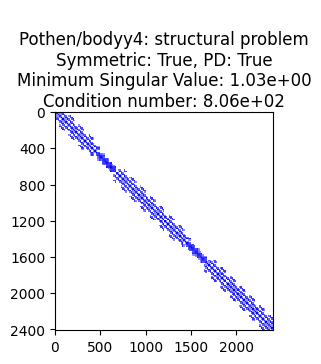

In [268]:
# plt.figure(figsize=(20, 8))
fig, ax = matspy.spy_to_mpl(A_csr)
title = ax.set_title(f"\n{matrix_name}: {properties['kind']}\nSymmetric: {properties['symmetric']}, PD: {properties['positive definite']}\nMinimum Singular Value: {properties['Minimum Singular Value']:.2e}\nCondition number: {properties['condition number']:.2e}",
         loc='center', wrap=True)
fig.tight_layout()
# title.set_y(1.05)
# fig.subplots_adjust(top=0)
plt.show()
fig.savefig(f'{figure_dir}/{matrix_postfix}.png', dpi=100)
plt.close(fig) 

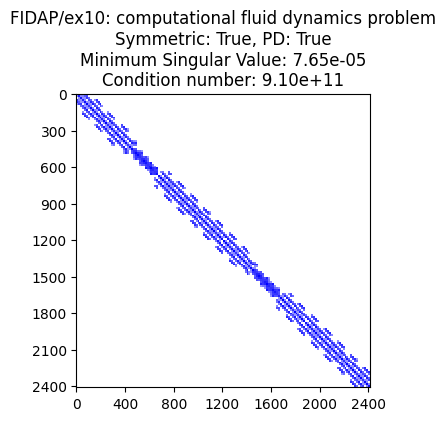

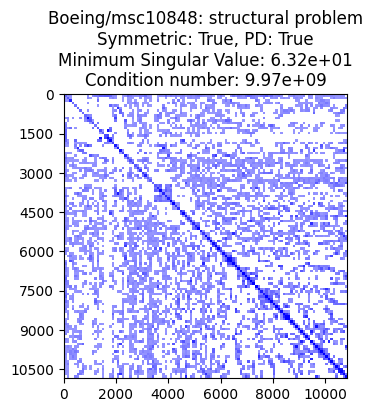

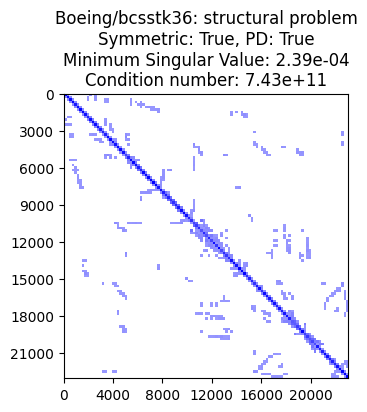

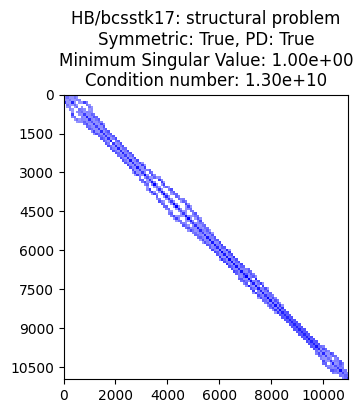

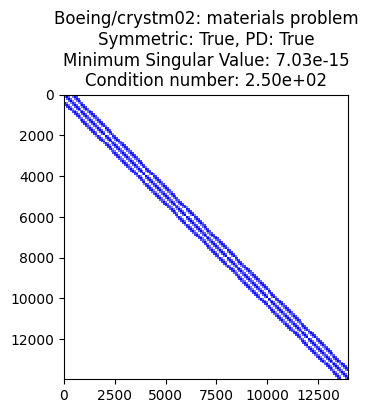

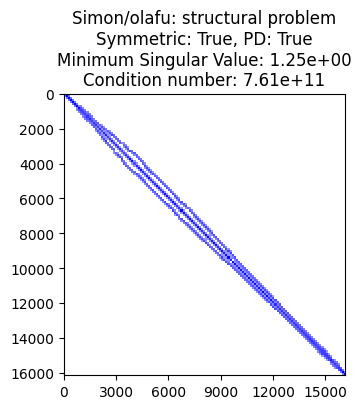

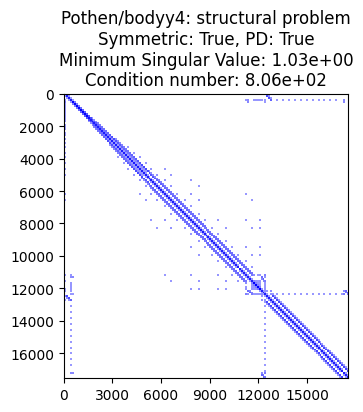

In [135]:
matrices = [
    "FIDAP/ex10",
    "Boeing/msc10848",
    "Boeing/bcsstk36",
    "HB/bcsstk17",
    "Boeing/crystm02",
    "Simon/olafu",
    "Pothen/bodyy4",
]

for matrix_name in matrices:
    matrix_postfix = matrix_name.split('/')[-1]
    properties = get_matrix_properties(matrix_name)

    url = f'https://suitesparse-collection-website.herokuapp.com/MM/{matrix_name}.tar.gz'
    A = download_and_read_matrix(url)
    A_csr = sparse.csr_matrix(A)
    
    fig, ax = matspy.spy_to_mpl(A)
    plt.title(f"{matrix_name}: {properties['kind']}\nSymmetric: {properties['symmetric']}, PD: {properties['positive definite']}\nMinimum Singular Value: {properties['Minimum Singular Value']:.2e}\nCondition number: {properties['condition number']:.2e}")
    plt.show()
    fig.savefig(f'figures/{matrix_postfix}.png')
    plt.close(fig) 

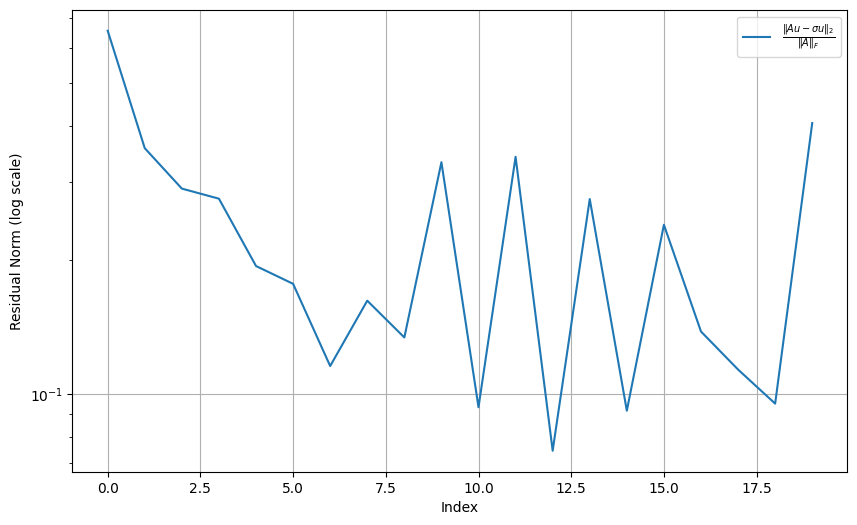

In [173]:
import mpmath
import numpy as np
from mpmath import mp

def high_precision_svd(A, dps=50):
    """
    Perform high precision SVD using mpmath.
    
    :param A: Input matrix (numpy array or list of lists)
    :param dps: Decimal places of precision (default 50)
    :return: U, S, V (as numpy arrays)
    """
    mp.dps = dps  # Set the precision
    
    # Convert the input matrix to mpmath matrix
    A_mp = mp.matrix(A)
    
    # Perform SVD
    U, S, V = mp.svd(A_mp)
    
    # Convert results back to numpy arrays
    U_np = np.array(U.tolist(), dtype=float)
    S_np = np.array(S.tolist(), dtype=float)
    V_np = np.array(V.tolist(), dtype=float)
    
    return U_np, S_np, V_np

# Usage example
A = A_csr[:20,:20].todense()
U, S, V = high_precision_svd(A, dps=200)

sp_norm = sparse.linalg.norm if isinstance(A, csr_matrix) else np.linalg.norm
A_norm = sp_norm(A)
approx_residuals = []
    
for k in range(len(U)):
    # Approximated residual
    # approx_res = A.T @ (A @ Vt[i].T) - S[i]**2 * Vt[i].T
    approx_res = (A @ U[k]) - (S[k]) * U[k]
    approx_residuals.append(np.linalg.norm(approx_res) / A_norm)
    
approx_residuals = np.array(approx_residuals)

plt.figure(figsize=(10, 6))
plt.semilogy(range(len(U)), approx_residuals, label='$\\frac{\|Au - \sigma u\|_2}{\|A\|_F}$')
plt.xlabel('Index')
plt.ylabel('Residual Norm (log scale)')
plt.title('')
plt.legend()
plt.grid(True)
plt.show()
plt.close('all')

In [174]:
S

array([[3.20232935e+07],
       [2.41137196e+07],
       [1.91045596e+07],
       [1.49749001e+07],
       [1.00820121e+07],
       [7.38752880e+06],
       [4.06158415e+06],
       [1.82844544e+06],
       [7.75880162e+05],
       [6.29749421e+05],
       [4.95138753e+05],
       [4.69446387e+05],
       [3.87900454e+05],
       [3.02157376e+05],
       [2.58463864e+04],
       [3.24011248e-01],
       [2.30801475e-01],
       [1.72390765e-01],
       [1.20681587e-01],
       [6.25796807e-02]])

In [ ]:


# # Set random seed for reproducibility
# np.random.seed(100)

# # Timing the incremental SVD
# start_time = time.time()
# # U_inc, S_inc, Vt_inc = incremental_svd(A_csr, k
# m, n = A_csr.shape
# W = 10  # number of windows (columns in this case)
# l = m // W  # window size
# k = l-1 # Number of singular values/vectors to compute
# r = min(k, m, l)

# # Initial SVD for the first window
# _, S, Vt = svds(A_csr[:l,:], k=r)

# print(Vt.shape)

# # Reverse the order to get largest singular values first
# S = S[::-1]
# Vt = Vt[::-1, :]

# B = S.reshape(-1, 1) * Vt

# # Create a permutation of row indices
# total_rows = A_csr.shape[0]
# A_squared = A_csr.copy()
# A_squared.data **= 2
# weights = np.asarray(np.sum(A_squared, axis=1)).reshape(-1)
# row_permutation = np.argsort(weights)#[::-1]
# # row_permutation = np.arange(len(weights))[::-1]
# # row_permutation = np.argsort(np.sum(Vt_exact**2, axis=0)).reshape(-1)#[::-1]

# for j in range(1, W):
#     print("Iteration:", j)
#     # Calculate the start and end indices for this window
#     start_idx = j * l
#     end_idx = min((j + 1) * l, total_rows)
    
#     # Extract the next window
#     window_indices = row_permutation[start_idx:end_idx]
#     next_window = A_csr[window_indices, :].toarray()
    
#     # Concatenate B[j-1] and the next window
#     combined = np.concatenate((B, next_window), axis=0)
    
#     # Perform SVD on the combined matrix
#     _, S, Vt = svds(combined, k=r)
    
#     # Reverse the order to get largest singular values first
#     S = S[::-1]
#     Vt = Vt[::-1, :]
    
#     # Optional: Apply soft thresholding to singular values
#     # S = soft_thresholding(S)
    
#     # Update B
#     B = S.reshape(-1, 1) * Vt

#     # Plot
#     # TODO: plot for each window
#     plt.figure(figsize=(10, 6))
#     plt.plot(S, label='Approximated Spectrum')
#     plt.plot(S_exact, label='Exact Spectrum')
#     # plt.plot(np.abs(S - S_exact))
#     plt.xlabel('Index')
#     plt.ylabel('Singular Value')
#     plt.title(f'Comparison of Approximated and Exact Spectra iteration {j}')
#     plt.legend()
#     plt.grid(True)
#     plt.show()
    
    
#     approx_residuals = []
#     # exact_residuals = []
    
#     for i in range(len(S)):
#         # Approximated residual
#         # approx_res = A.T @ (A @ Vt[i].T) - S[i]**2 * Vt[i].T
#         approx_res = (A @ Vt[i].T) - S[i] * Vt[i].T
#         approx_residuals.append(np.linalg.norm(approx_res) / sp_norm(A))
        
#         # Exact residual
#         # exact_res = A.T @ (A @ Vt_exact[i].T) - S_exact[i]**2 * Vt_exact[i].T
#         # exact_residuals.append(np.linalg.norm(exact_res) / np.linalg.norm(S_exact[i]**2 * Vt_exact[i].T))
    
#     approx_residuals = np.array(approx_residuals)
#     # approx_residuals, exact_residuals = np.array(approx_residuals), np.array(exact_residuals)
    
#     plt.figure(figsize=(10, 6))
#     plt.semilogy(approx_residuals, label='$\\frac{\|Av - \sigma v\|_2}{\|A\|_F}$')
#     # plt.semilogy(exact_residuals, label='Exact Relative Residuals')
#     plt.xlabel('Index')
#     plt.ylabel('Residual Norm (log scale)')
#     plt.title('')
#     plt.legend()
#     plt.grid(True)
#     plt.show()

# random_inc_time = time.time() - start_time
# random_inc_time